# EDIS 8100 · Week 3 · Ethics and Bias Audit

## Auditing a non-completion model before anyone acts on it

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

We work through this notebook together in class, from 4:50 to 5:50, after the student-led
discussion hour and the break. Nothing from it is collected and nothing goes to Canvas.

Coding experience is not assumed here, and coding is not what the session is about. Every cell
already contains working code. Attention is better spent on what the code is doing to the data
and on what the output might mean.

Questions are welcome at any point, including questions about a single line of code.

### What I hope you leave with

1. Being able to load a real, published, openly licensed learning dataset and state where it came
   from and who collected it before analyzing a single row.
2. Being able to name what a model predicts, and to say why "an at-risk model" is a description of
   a person while "a model predicting non-completion" is a description of an outcome.
3. Training that model on activity data, and reading its accuracy against a do-nothing baseline.
4. Disaggregating the model's errors by socioeconomic decile and by disability status, and saying
   which of those differences can be distinguished from noise once thirty comparisons have been made.
None of these is a coding objective. If time allows, sections 5 and 7 to 10 add the redesigned
feature set and a second setting.

Part 1 audits the Open University module from week 2. Part 2 runs the same audit on the 395
Portuguese secondary students in the UCI Student Performance file. That file holds 38 final grades
of exactly 0, and Part 2 audits them before anything is built on them. Everything is downloaded
from the internet, so a working connection is needed.


## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- This runs on a temporary machine in the cloud, working on a copy of two published files. If
  something goes wrong, `Runtime > Restart session and run all` in Colab, or `Kernel > Restart & Run All`
  in Jupyter, resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without
  editing anything and nothing will be missing.
- Sections marked **Going further** are optional. Please feel free to skip them today.

**Every code cell here runs as written.** Changing a **Your turn** value and re-running shows what
the choice was doing to the result, which is why the cell is marked.

### The route for today

| | Sections | What it is for |
|---|---|---|
| **CORE, about 55 to 60 minutes** | Where this data came from, Setup, 1, 2, 3, 4, Your turn 1, 6, Reflection prompts 1 to 3 | Provenance, the four decisions and the name of the target, the gaps before any model, the model read against the do-nothing rule, error rates by decile and by recorded disability, the threshold, and the population the accuracy figure describes |
| **IF TIME** | Part 2 setup, 7, 9, 10, then 5 with Your turn 2 | The same audit in a second setting and which gaps replicated, then the redesigned feature set |
| **EXPLORE LATER** | Your turn 3, 8, 11, Your turn 4, Why the course runs the audit twice, Going further | Another column, the seed, the accuracy gap and the 38 zeros, the comparison count, and the notes on the Your turn cells |


**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to
read the code the way you read a methods section: you are checking what was done to the data, not
memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in
`df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`,
`.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line
does not make sense, please ask.


## Setup

**Run the cell below.** It downloads six files from a public GitHub repository.

If your connection is down, the cell prints a plain-English message rather than a long red error
trace. Please read the message, reconnect, and run the cell again.


In [1]:
%matplotlib inline
# the line above just tells the notebook to draw charts here on the page

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

pd.set_option("display.width", 160)

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

FILES = {
    "student_info":     ("oulad-bbb/studentInfo.csv",         "one row per enrollment: who registered"),
    "student_vle":      ("oulad-bbb/studentVle.csv.gz",       "one row per student per resource per day: clicks"),
    "student_assess":   ("oulad-bbb/studentAssessment.csv",   "one row per submitted assignment"),
    "assessments":      ("oulad-bbb/assessments.csv",         "the assignment calendar for the module"),
    "student_reg":      ("oulad-bbb/studentRegistration.csv", "registration and withdrawal dates"),
    "vle":              ("oulad-bbb/vle.csv",                 "the catalog of course materials"),
}

loaded = {}
try:
    for name, (path, _) in FILES.items():
        loaded[name] = pd.read_csv(f"{BASE}/{path}")
except Exception as problem:
    message = (
        "\n"
        "We could not download the course data.\n"
        "\n"
        "The files live in the public GitHub repository HakeoungLee/edis8100-datasets,\n"
        f"under {BASE}\n"
        "\n"
        "Almost always this is one of three things:\n"
        "  1. This machine is offline, or the campus network is blocking raw.githubusercontent.com.\n"
        "  2. GitHub is temporarily unavailable. Wait a minute and run this cell again.\n"
        "  3. You are on a restricted network. Open the notebook in Google Colab instead.\n"
        "\n"
        f"The underlying complaint was: {type(problem).__name__}: {problem}\n"
    )
    print(message)
    raise RuntimeError("Could not download the OULAD files. See the message above.") from None

student_info   = loaded["student_info"]
student_vle    = loaded["student_vle"]
student_assess = loaded["student_assess"]
assessments    = loaded["assessments"]
student_reg    = loaded["student_reg"]
vle_catalogue  = loaded["vle"]

print("Data arrived. Here is what you have:\n")
for name, (path, description) in FILES.items():
    frame = loaded[name]
    print(f"  {name:<16} {frame.shape[0]:>7,} rows x {frame.shape[1]:>2} columns   {description}")

print(f"\nOne module (BBB), two runs of it: {sorted(student_info['code_presentation'].unique())}")
print(f"{len(student_info):,} enrollments, {student_info['id_student'].nunique():,} distinct people.")


Data arrived. Here is what you have:

  student_info       4,529 rows x 12 columns   one row per enrollment: who registered
  student_vle      891,062 rows x  6 columns   one row per student per resource per day: clicks
  student_assess    21,783 rows x  5 columns   one row per submitted assignment
  assessments           18 rows x  6 columns   the assignment calendar for the module
  student_reg        4,529 rows x  5 columns   registration and withdrawal dates
  vle                  528 rows x  6 columns   the catalog of course materials

One module (BBB), two runs of it: ['2013J', '2014J']
4,529 enrollments, 4,482 distinct people.


## Where this data came from



| | |
|---|---|
| **Dataset** | Open University Learning Analytics Dataset (OULAD), module **BBB**, presentations **2013J** and **2014J** |
| **Who collected it** | The Open University, a large distance-teaching university in the United Kingdom, from its own student records and its own virtual learning environment. Prepared for release by the Knowledge Media Institute. |
| **When** | Two runs of one module in 2013 and 2014. `J` means the October start. |
| **License** | CC BY 4.0. Free to use and share, including commercially, with attribution. |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |

**Summary.** A university that teaches almost entirely online already holds a complete record of what every student clicked, when they submitted, and how it ended. A research group inside that university pulled two years of one module, stripped the names, replaced them with numbers, aggregated the clicks to daily counts, and published the result under an open license.

**Who is in the file.** Every row is a person who enrolled in a distance-learning module in 2013 or 2014.

**Two columns.**

`imd_band` is the UK Index of Multiple Deprivation decile for the **area a student lived in**, not the student's own income. `0-10%` means the most deprived tenth of neighborhoods; `90-100%` the least deprived. Assigning a neighborhood's average to an individual is called the ecological fallacy. This notebook does that, because it is what the column offers.

`disability` is whether the university had a disability **recorded** for that student. The file does not say how a disability came to be recorded. The column records the presence of a record, not the presence of a disability.

## 1. Real data does not arrive clean

The Portuguese file in Part 2 is 395 rows, one per student, 33 columns, with one problem in the outcome column that the Part 2 setup cell audits. This one arrives as six tables that have to be joined to each other.

**Run the cell below** for what is in these files.

In [2]:
print("A. THE SOCIOECONOMIC COLUMN, exactly as it is written in the file")
print(student_info["imd_band"].value_counts(dropna=False).to_string())
print("\n   Nine of them end in a percent sign and one does not.")
print(f"   And {student_info['imd_band'].isna().sum()} enrollments have nothing recorded at all.\n")

print("B. IS ONE ROW ONE PERSON?")
n_rows = len(student_info)
n_people = student_info["id_student"].nunique()
print(f"   {n_rows:,} rows, {n_people:,} distinct student ids.")
print(f"   {n_rows - n_people} people took this module twice, once in each presentation.")
repeaters_2013 = student_info[student_info.duplicated("id_student", keep=False)
                              & (student_info["code_presentation"] == "2013J")]
print("   How their 2013J enrollment ended:")
print("   " + ",  ".join(f"{k} {v}" for k, v in repeaters_2013["final_result"].value_counts().items()) + "\n")

print("C. ENROLLMENTS WITH NO CLICKS RECORDED ANYWHERE")
active_ids = set(zip(student_vle["code_presentation"], student_vle["id_student"]))
all_ids = set(zip(student_info["code_presentation"], student_info["id_student"]))
silent = all_ids - active_ids
print(f"   {len(silent):,} of the {n_rows:,} enrollments never appear in the clickstream file, ever.")
print("   They are not in the file at all, so a plain merge would drop them without saying so.")
print("   (Once we narrow to the first 60 days the count goes up. You will see it in a moment.)\n")

print("D. CLICKS RECORDED BEFORE DAY 0")
early = (student_vle["date"] < 0).sum()
print(f"   date runs from {student_vle['date'].min()} to {student_vle['date'].max()} days from the module start.")
print(f"   {early:,} click rows ({early / len(student_vle):.1%}) happen before day 0.\n")

print("E. THE OUTCOME COLUMN")
print(student_info["final_result"].value_counts().to_string())
print("\n   Four categories, not two. 'Withdrawn' and 'Fail' are different recorded events.\n")

print("F. ASSESSMENTS DUE ON OR BEFORE DAY 60, with their weights")
print(assessments.loc[assessments["date"] <= 60]
      .sort_values(["code_presentation", "date"])
      [["code_presentation", "id_assessment", "assessment_type", "date", "weight"]]
      .to_string(index=False))

A. THE SOCIOECONOMIC COLUMN, exactly as it is written in the file
imd_band
0-10%      591
20-30%     566
10-20      557
30-40%     495
40-50%     474
50-60%     449
60-70%     412
70-80%     353
80-90%     335
90-100%    268
NaN         29

   Nine of them end in a percent sign and one does not.
   And 29 enrollments have nothing recorded at all.

B. IS ONE ROW ONE PERSON?
   4,529 rows, 4,482 distinct student ids.
   47 people took this module twice, once in each presentation.
   How their 2013J enrollment ended:
   Withdrawn 34,  Fail 13

C. ENROLLMENTS WITH NO CLICKS RECORDED ANYWHERE
   738 of the 4,529 enrollments never appear in the clickstream file, ever.
   They are not in the file at all, so a plain merge would drop them without saying so.
   (Once we narrow to the first 60 days the count goes up. You will see it in a moment.)

D. CLICKS RECORDED BEFORE DAY 0
   date runs from -23 to 268 days from the module start.
   46,884 click rows (5.3%) happen before day 0.

E. THE OUTCO

### The decisions

Each of the five findings above forces a choice. Four of them fit in the table. Finding E, the four outcome categories, needs a paragraph of its own and gets one right after the next cell.

| The problem | What we do | What it affects |
|---|---|---|
| `imd_band` has one label written `10-20` without a percent sign | Rewrite it as `10-20%` so the ten deciles sort in order | Nothing, provided the rename is recorded. |
| 29 enrollments have no `imd_band` | Keep them, in a row labeled `Not recorded` | The row is too small to say much about. But dropping people whose deprivation was not recorded would be an odd way to study deprivation. |
| 47 people appear twice | Treat one **enrollment** as one row, not one person | Two rows for the same person are not independent, and treating them as independent makes our intervals slightly too **narrow**, not too wide. Section 4 stops asserting that and measures it: resampling people rather than enrollments moves the headline interval by less than a thousandth. One thing worth knowing about these 47, because it changes what the second row is: every one of them has a 2013J `final_result` of Withdrawn (34) or Fail (13). |
| Enrollments with no recorded clicks | Keep them, with recorded activity counted as zero | See below. |

**Why the enrollments with no recorded clicks stay.** The next cell shows how they ended: 734 of the 836 are Withdrawn. If we drop them, we delete most of the outcome we claim to care about, and the model is evaluated on a cohort pre-selected for having stayed. So they stay, with recorded activity counted as zero. Counted as zero, not *known* to be zero: the log records clicks on one website, and these were adults studying at a distance.

The cost is real and we will measure it in section 6: a large share of them had already formally unregistered, so the model will get credit for "predicting" something the registry already knew.



**One more decision about the window.** We count activity in the module's **first 60 days**, not the whole term. An early warning system that uses the whole term is not early, and it is nearly circular: students who withdraw stop clicking, so "low clicks" would partly be a restatement of the outcome. Day 60 sits after the opening assignments in both presentations, though not after the same number of them: three fall on or before day 60 in 2013J (days 19, 47 and 54) and two in 2014J (days 19 and 54), and the 2014J one on day 19 carries zero weight toward the grade. That asymmetry matters once we build a feature out of submitted work, and section 5 says what it does. The 46,884 rows from before day 0 are set aside, which means our features do not include recorded clicks before day 0.

### The first design decision is a name

Before a single line of modeling code, somebody has to decide what the model is for. In this literature the answer is almost always written the same way: *an at-risk model*, producing a list of *at-risk students*.



An enrollment in this file ended in one of four states. Two of them, `Pass` and `Distinction`, we are about to call one thing, and the other two, `Fail` and `Withdrawn`, we are about to call another. That is a fact about **an outcome recorded by a registry**. "At risk" is not. It describes the person rather than the recorded outcome, and it does so before any evidence has been examined. Somebody chose a threshold, on a population somebody bounded, using an outcome somebody defined, and the phrase hides all three.

So this notebook does not use it as its own vocabulary. The column we are about to build is called `did_not_pass`, and it means exactly one thing:

> `did_not_pass = 1` if this enrollment's `final_result` was `Fail` or `Withdrawn`.

That is a sentence you could read out to the person it describes without asserting anything about them that the file does not hold. "At-risk student" is not.

You will still meet the field's phrase constantly. Keep it, and keep it in quotation marks, as an object of study. The four questions to ask every time somebody uses it are: **at risk of what, according to whom, measured how, and with what consequence for the person carrying the label?** For this notebook the answers are: at risk of a `final_result` of `Fail` or `Withdrawn`; according to us, in this cell; recorded by the registry at the end of the presentation; and with the consequence that somebody's name goes on a list an advising office works through.

The rest of the pipeline inherits this decision. Rename the target and the same audit reads differently, because "the model flagged 367 of the 591 enrollments in the most deprived decile" invites a different question from "62 percent of students in the poorest decile are at risk." The first sentence sends you to look at the model. The second sends you to look at the students. Only one of them is supported by anything you are about to compute.

*Connecting to the readings.* Borchers, Liu, Lee and Zhang (2024) separate conducting AIED research ethically from studying the ethics of AIED, and argue that the two strands need each other. The choice of a target name sits in both at once: it is a design decision inside the pipeline, and it is also the object of study in this cell. One question worth carrying over from the discussion hour is which of this week's frameworks would have had anything specific to say about it.


In [3]:
CHECKPOINT_DAY = 60     # how far into the module our early warning system is allowed to look
IMD_ORDER = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]

# --- decision 1 and 2: repair the label, name the blanks ------------------
enrol = student_info.copy()
enrol["imd_band_clean"] = enrol["imd_band"].replace({"10-20": "10-20%"}).fillna("Not recorded")

# --- the outcome the model is asked to predict ---------------------------
# did_not_pass = 1 means this enrollment's final_result was Fail or Withdrawn.
# The name describes the recorded outcome. It does not describe a person, and it is
# not a claim about anybody's future. See the naming section above.
enrol["did_not_pass"] = (~enrol["final_result"].isin(["Pass", "Distinction"])).astype(int)

# --- activity in the first 60 days, one row per enrollment ---------------
window = student_vle[student_vle["date"].between(0, CHECKPOINT_DAY)]
activity = (
    window.groupby(["code_presentation", "id_student"])
    .agg(clicks=("sum_click", "sum"),              # how MUCH they did
         active_days=("date", "nunique"),          # how MANY days they showed up
         resources=("id_site", "nunique"))         # how WIDELY they roamed
    .reset_index()
)

data = enrol.merge(activity, on=["code_presentation", "id_student"], how="left")
data["no_activity"] = data["clicks"].isna().astype(int)          # decision 4: keep them, flagged
data[["clicks", "active_days", "resources"]] = data[["clicks", "active_days", "resources"]].fillna(0)

# --- what they produced by day 60: graded work ---------------------------
# studentAssessment has no presentation column of its own: an assessment belongs to a
# presentation, so the presentation has to be carried across from the assessments table
# and used in the join key. Group by id_student alone and the 47 people who sat this
# module twice get both attempts pooled into one row, which is the exact error section 1
# told you to watch for.
due_by_now = assessments.loc[assessments["date"] <= CHECKPOINT_DAY,
                             ["id_assessment", "code_presentation", "date"]]
# --- decision 5: banked scores -------------------------------------------
# OULAD documents is_banked as a result transferred from a previous presentation.
# A banked score was not produced by day 60 of THIS presentation, so counting it as a
# submission would give the model a feature built on another run of the course.
# We audit it, then set those rows aside.
n_banked = int((student_assess["is_banked"] == 1).sum())
_admitted = (student_assess.merge(due_by_now, on="id_assessment")
                           .query("date_submitted <= @CHECKPOINT_DAY and is_banked == 1"))
print(f"Banked rows in studentAssessment: {n_banked:,}. "
      f"{len(_admitted):,} of them fall inside the day-{CHECKPOINT_DAY} window and would have "
      f"counted as submissions for {_admitted.drop_duplicates(['code_presentation', 'id_student']).shape[0]} "
      f"enrollments. Set aside.\n")
handed_in = student_assess[student_assess["is_banked"] == 0].merge(due_by_now, on="id_assessment")
handed_in = handed_in[handed_in["date_submitted"] <= CHECKPOINT_DAY]
produced = (
    handed_in.groupby(["code_presentation", "id_student"])
    .agg(n_submitted=("id_assessment", "nunique"), mean_score=("score", "mean"))
    .reset_index()
)
data = data.merge(produced, on=["code_presentation", "id_student"], how="left")
data["n_submitted"] = data["n_submitted"].fillna(0)
data["no_submission"] = data["mean_score"].isna().astype(int)

# A blank score is not a zero and it is not an average. We fill it with the
# cohort median SO THE MODEL CAN RUN, and carry no_submission alongside it so
# that the fill is never mistaken for a measurement. Two honest caveats: the median
# is computed on the whole cohort rather than inside each cross-validation fold, which
# leaks a trace of information about the feature (not about the outcome); and the
# indicator tells the model THAT a score is missing, never why.
median_score = data["mean_score"].median()
data["mean_score"] = data["mean_score"].fillna(median_score)

# --- registration status at the checkpoint, for section 6 ----------------
data = data.merge(student_reg[["code_presentation", "id_student", "date_unregistration"]],
                  on=["code_presentation", "id_student"], how="left")

print(f"Model table: {len(data):,} enrollments x {data.shape[1]} columns, "
      f"activity counted over days 0 to {CHECKPOINT_DAY}.\n")
print(f"Enrollments with zero clicks in the window : {int(data['no_activity'].sum()):,}")
print("   how those enrollments ended:")
print(data.loc[data['no_activity'] == 1, 'final_result'].value_counts().to_string())
print(f"\nEnrollments with no graded work submitted   : {int(data['no_submission'].sum()):,}")
print(f"   their mean_score was filled with the cohort median, {median_score:.1f}")
print(f"\nHow many ended in Fail or Withdrawn         : {int(data['did_not_pass'].sum()):,} "
      f"({data['did_not_pass'].mean():.1%} of enrollments)")
print("\nSubmissions and scores by presentation (mean_score after the median fill):")
print(data.groupby("code_presentation")[["n_submitted", "mean_score"]].agg(["max", "mean"]).round(1).to_string())

Banked rows in studentAssessment: 266. 134 of them fall inside the day-60 window and would have counted as submissions for 50 enrollments. Set aside.

Model table: 4,529 enrollments x 22 columns, activity counted over days 0 to 60.

Enrollments with zero clicks in the window : 836
   how those enrollments ended:
final_result
Withdrawn    734
Fail          90
Pass          12

Enrollments with no graded work submitted   : 1,085
   their mean_score was filled with the cohort median, 78.7

How many ended in Fail or Withdrawn         : 2,305 (50.9% of enrollments)

Submissions and scores by presentation (mean_score after the median fill):
                  n_submitted      mean_score      
                          max mean        max  mean
code_presentation                                  
2013J                     3.0  2.0      100.0  77.8
2014J                     2.0  1.4      100.0  66.1


**Let's look at the label we just built.** Even under a name that describes an outcome, `did_not_pass = 1` lumps an enrollment that sat the exam and failed together with an enrollment that unregistered in week two.

Those are not the same event, they do not have the same causes, and an outreach phone call is not equally useful for both.

**Let's discuss.** Who does that label flatten, and what would we need in this dataset to tell those two students apart? Every model in this notebook inherits whatever this one line got wrong.

## 2. The gaps are already in the data, before any model exists

Before any model, the outcome and activity gaps in the raw columns.

**Run the cell below.** It computes three things straight from the raw columns:

1. The **pass rate** in each deprivation decile. Passing means `Pass` or `Distinction`.
2. The **pass rate** for students with and without a recorded disability.
3. The **median click count** in the first 60 days in each decile.



PASS RATE AND ACTIVITY BY DEPRIVATION DECILE (0-10% = most deprived areas)
                students  pass_rate  median_clicks  median_active_days
imd_band_clean                                                        
0-10%                591       36.9           86.0                 7.0
10-20%               557       43.3           98.0                 8.0
20-30%               566       43.8          122.0                 9.0
30-40%               495       50.7          139.0                11.0
40-50%               474       47.9          134.0                10.0
50-60%               449       54.3          150.0                11.0
60-70%               412       56.3          152.5                10.0
70-80%               353       56.1          145.0                10.0
80-90%               335       54.9          152.0                11.0
90-100%              268       61.9          164.0                13.0
Not recorded          29       51.7          167.0                14.0

P

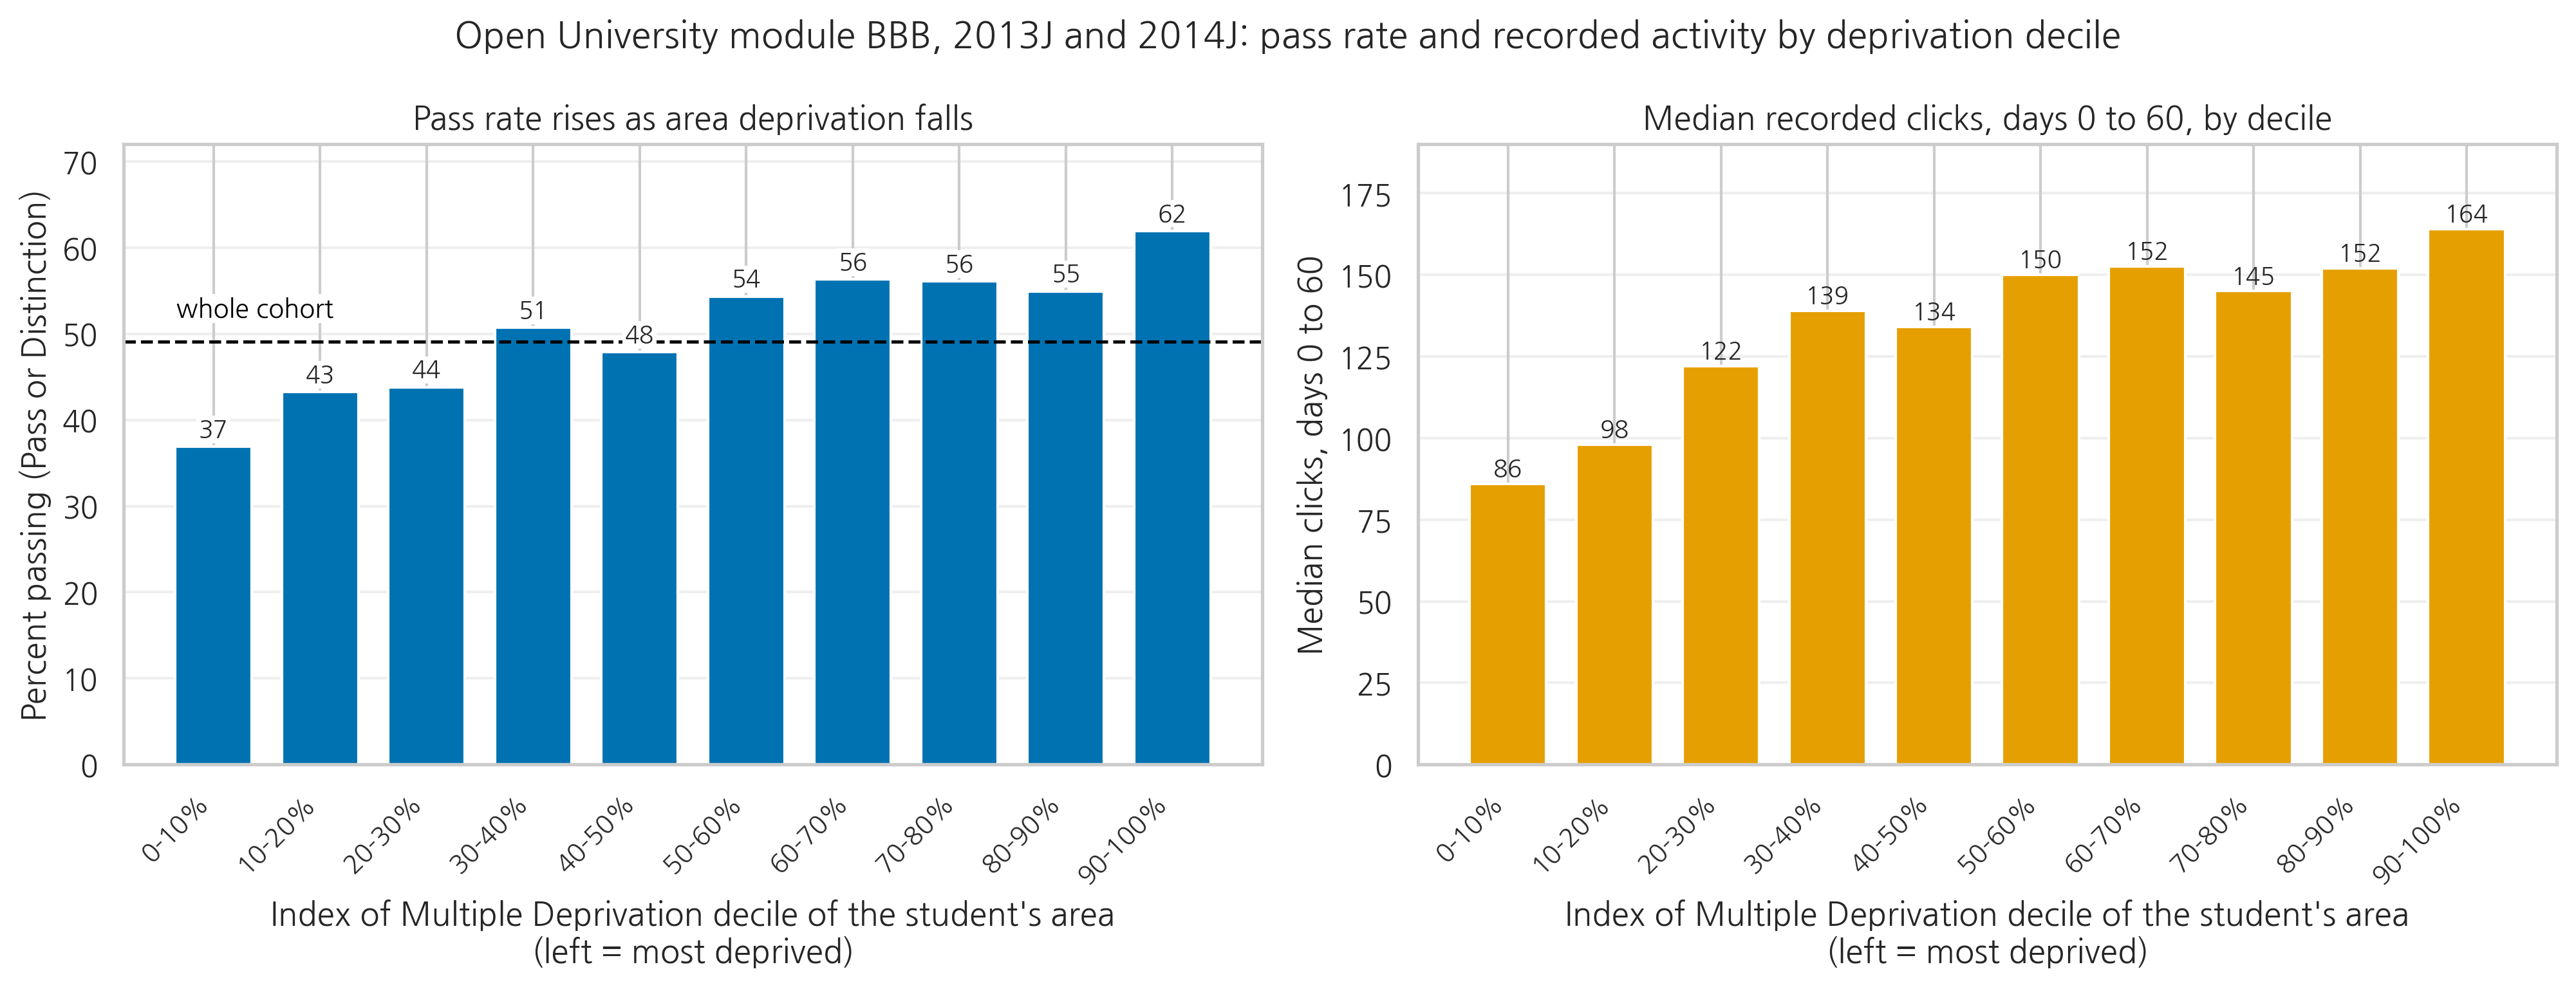

In [4]:
data["passed"] = 1 - data["did_not_pass"]

BLUE, ORANGE, GREEN = "#0072B2", "#E69F00", "#009E73"

by_imd = (data.groupby("imd_band_clean")
          .agg(students=("passed", "size"),
               pass_rate=("passed", "mean"),
               median_clicks=("clicks", "median"),
               median_active_days=("active_days", "median"))
          .reindex(IMD_ORDER + ["Not recorded"]))

print("PASS RATE AND ACTIVITY BY DEPRIVATION DECILE (0-10% = most deprived areas)")
show = by_imd.copy()
show["pass_rate"] = (show["pass_rate"] * 100).round(1)
print(show.to_string())

by_dis = (data.groupby("disability")
          .agg(students=("passed", "size"),
               pass_rate=("passed", "mean"),
               median_clicks=("clicks", "median")))
print("\nPASS RATE AND ACTIVITY BY RECORDED DISABILITY")
show2 = by_dis.copy()
show2["pass_rate"] = (show2["pass_rate"] * 100).round(1)
print(show2.to_string())

print(f"\nWhole cohort pass rate: {data['passed'].mean():.1%}")
print(f"Most deprived decile {by_imd.loc['0-10%', 'pass_rate']:.1%}  "
      f"vs least deprived decile {by_imd.loc['90-100%', 'pass_rate']:.1%}")
print(f"Disability recorded {by_dis.loc['Y', 'pass_rate']:.1%}  "
      f"vs not recorded {by_dis.loc['N', 'pass_rate']:.1%}")

# ---------------------------------------------------------------- figure 1
grad = by_imd.loc[IMD_ORDER]
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

label_box = dict(facecolor="white", edgecolor="none", pad=0.9)
axes[0].bar(xpos, grad["pass_rate"] * 100, color=BLUE, width=0.72)
axes[0].axhline(data["passed"].mean() * 100, color="black", linestyle="--", linewidth=1.2)
axes[0].text(-0.35, data["passed"].mean() * 100 + 3.0, "whole cohort",
             ha="left", fontsize=9.5, color="black", bbox=label_box)
for i, v in enumerate(grad["pass_rate"] * 100):
    axes[0].text(i, v + 1.2, f"{v:.0f}", ha="center", fontsize=9, bbox=label_box)
axes[0].set_ylabel("Percent passing (Pass or Distinction)")
axes[0].set_title("Pass rate rises as area deprivation falls")
axes[0].set_ylim(0, 72)

axes[1].bar(xpos, grad["median_clicks"], color=ORANGE, width=0.72)
for i, v in enumerate(grad["median_clicks"]):
    axes[1].text(i, v + 2.5, f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_ylabel(f"Median clicks, days 0 to {CHECKPOINT_DAY}")
axes[1].set_title("Median recorded clicks, days 0 to 60, by decile")
axes[1].set_ylim(0, 190)

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile of the student's area\n(left = most deprived)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Open University module BBB, 2013J and 2014J: pass rate and recorded activity by deprivation decile",
             fontsize=13.5)
fig.tight_layout()
plt.show()

**Let's look at the output.** The left panel is an outcome gap. The right panel is a gap in the
thing we are about to hand a model as evidence.

A gradient
across deprivation deciles is a measurement of the conditions under which people studied, and of an
institution that produced different outcomes for people in different circumstances. It is not a
measurement of the people. Nothing here licenses a sentence of the form "students from deprived
areas are less X." The Index of Multiple Deprivation is an area-level index: it describes a few
hundred neighboring households rather than a person, and assigning it to an individual is the
ecological fallacy named in the provenance section, because it is what the column offers.

Three things are worth keeping separate here:

| | |
|---|---|
| **What the data directly show** | This module returned a pass to 36.9 percent of the enrollments from the most deprived tenth of areas and 61.9 percent from the least deprived tenth, and median clicks over days 0 to 60 run 86 against 164 |
| **A plausible interpretation** | Recorded activity is partly a measure of the cost of studying: broadband at home, a quiet room, a laptop nobody else needs, hours not sold to an employer, a shift pattern that does not produce evenly spaced clicks |
| **What this file cannot establish** | Which of those conditions is operating, since OULAD records no working hours, no housing, no caring responsibilities, and no equipment |

If recorded
activity is lower in the most deprived decile, and pass rates are also lower there, a model trained
on recorded activity will learn a relationship that is partly about learning and partly about
something else.

**Let's discuss.** The model we are about to build will never see `imd_band`. Does that make it
blind to deprivation, or just unable to tell us that it is not?

**One caution on the right panel.** The gradient is not perfectly monotonic. The 40-50% decile sits
below 30-40%, and 70-80% sits below 60-70%. With between 268 and 591 students per decile, a couple of bands out of order is consistent with sampling variation.

*Connecting to the readings.* Uttamchandani and Quick (2022), in this week's additional readings,
treat fairness, absence of bias, and equity as three separate commitments rather than three words
for one thing. The left panel raises an equity question and the right panel is about to raise a bias
question, and the two do not have the same answer or the same remedy.


## 3. Train the model, then read the accuracy against a baseline

**Logistic regression in one sentence.** It finds the best available dividing line between the enrollments that ended in `Fail` or `Withdrawn` and the ones that did not, and hands back, for each enrollment, a number between 0 and 1 that behaves like a predicted probability of that outcome. That number is not a property of a person, and it is not a probability about anybody's future. It is this model's guess at a registry field, fitted on the other enrollments in the same two presentations, whose outcomes are already recorded.

The feature set is deliberately ordinary. It uses only the clickstream, which the virtual learning environment records for every enrollment:

`clicks` (how much), `active_days` (how regularly), `resources` (how widely)



**How we test it.** Five-fold cross validation: split the cohort into five parts, train on four, predict the fifth, rotate until every student has been scored by a model that never saw their outcome. Scoring a model on the students it trained on tells you nothing about new students.

**How a score becomes an action.** A predicted probability does nothing by itself. Somebody has to decide who gets contacted. Our rule is the simplest one available: flag every enrollment whose score is at least 0.5. That 0.5 is not a statistical quantity. It is an operating decision.

**What "good" would even mean.** The useful comparison is the best thing anyone could do with no model at all. Here that is "never flag anybody," which is right about every student who passed and wrong about everybody else.

**Run the cell below.**

In [5]:
y_true = data["did_not_pass"].to_numpy()

def predicted_scores(feature_names):
    """Fit a logistic regression and return an out-of-sample predicted probability
    of did_not_pass, one per enrollment.

    Every score comes from a model trained on the other four folds, so no enrollment
    is ever scored by a model that already saw how that enrollment ended.
    """
    X = data[list(feature_names)].to_numpy(dtype=float)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
    return cross_val_predict(model, X, y_true, cv=folds, method="predict_proba")[:, 1]

def flag_at(scores, threshold):
    """Turn a predicted probability into an action: who does the advising office contact?"""
    return (scores >= threshold).astype(int)

THRESHOLD = 0.5
ACTIVITY_FEATURES = ["clicks", "active_days", "resources"]

scores_activity = predicted_scores(ACTIVITY_FEATURES)
flags_activity = flag_at(scores_activity, THRESHOLD)

accuracy_activity = (flags_activity == y_true).mean()
do_nothing = (y_true == 0).mean()        # accuracy of "never flag anybody"
flag_everyone = (y_true == 1).mean()     # accuracy of "flag the whole cohort"

print(f"Features            : {', '.join(ACTIVITY_FEATURES)}")
print(f"Enrollments scored  : {len(data):,}")
print(f"Flagged at {THRESHOLD:.2f}      : {int(flags_activity.sum()):,} enrollments "
      f"({flags_activity.mean():.1%} of the cohort)\n")
print(f"Model accuracy              : {accuracy_activity:.3f}")
print(f"'Never flag anybody'        : {do_nothing:.3f}")
print(f"'Flag the whole cohort'     : {flag_everyone:.3f}")
print(f"\nThe model beats doing nothing by {accuracy_activity - do_nothing:.3f}, "
      f"which is {(accuracy_activity - do_nothing) * len(data):.0f} enrollments' worth of extra")
print("correct classifications.")

Features            : clicks, active_days, resources
Enrollments scored  : 4,529
Flagged at 0.50      : 2,381 enrollments (52.6% of the cohort)

Model accuracy              : 0.735
'Never flag anybody'        : 0.491
'Flag the whole cohort'     : 0.509

The model beats doing nothing by 0.244, which is 1105 enrollments' worth of extra
correct classifications.


**Let's look at the output.** The model is right about roughly three enrollments in four, and it
beats the do-nothing rule by a wide margin. The do-nothing rule is easy to beat here, because
roughly half of these enrollments did not end in a pass, so the outcome the model is looking for is
not rare.

**Let's discuss.** Would you deploy this? What would you want to know first?

Everything above is a single number describing 4,529 enrollments, belonging to 4,482 people, at
once. A single number cannot tell you which students the mistakes were made about.

*Connecting to the readings.* Tsai and Martinez-Maldonado (2022) argue that information is not
feedback until somebody is in a position to act on it, and that the conditions for acting are part
of the system rather than a separate matter. An accuracy figure says nothing about those conditions.


## 4. The audit: error rates by group

An overall accuracy number averages over everybody. To audit a model you break the errors apart and count each kind inside each group.

There are two ways to be wrong, and they fall on different enrollments:

| Error | Plain language | What it means for the student |
|---|---|---|
| **False positive** | Flagged, but the enrollment went on to pass | Being watched, advised at, or labeled when nothing in the record needed it |
| **False negative** | Not flagged, and the enrollment did not pass | Being invisible to a system built to help you |

So we compute three numbers inside each group:

- **False positive rate**: of the enrollments in this group that **did** pass, what share did the model flag anyway?
- **False negative rate**: of the enrollments in this group that **did not** pass, what share did the model miss?
- **Share flagged**: of everyone in this group, what share got a flag at all? This is the number the person experiences. It does not care whether the flag turned out to be correct.

These are proportions, so 0.30 means three in ten.

**A warning to read before the table, not after.** We are about to compute three rates in each of ten deciles, which is thirty numbers, and the largest and smallest cells will be read first. That is thirty chances for noise to produce something that looks like a finding. The three rates do not rest on the same denominators: the false positive rate is computed among the enrollments in the decile that passed, the false negative rate among those that did not, and the share flagged among all of them, so across the thirty cells the denominators run from 102 to 591. Each rate therefore carries a standard error of roughly two to four percentage points, and the *range* across ten such cells is around 0.09 for the two error rates and around 0.075 for the share flagged, even when every decile shares exactly the same true rate. The notebook simulates those figures and prints them.

The defensible move is to ask whether the rates **trend** across the deciles, which is one question rather than ten, and to put an interval on the trend, rather than hunting for the biggest cell-to-cell gap. That is what the cell below does.

**Run the cell below.**

**What that one line assumes, and what the cell does about it.** Fitting a slope treats the decile label as a number, which assumes the ten steps are evenly spaced. They are evenly spaced in rank: each band holds a tenth of the areas. They are not evenly spaced in deprivation itself, so the slope is per decile of rank and nothing more. The second assumption is that one straight line describes the ten points adequately, and the cell reports a weighted lack-of-fit check rather than assuming it: a small p-value there would mean the trend is real but not straight, and the slope would be the wrong summary. The interval comes from resampling enrollments inside each decile, and because 47 people contribute two rows each, the cell also runs the same bootstrap on *people* so that the non-independence from section 1 becomes a number instead of a caveat.

ACTIVITY-ONLY MODEL, audited by deprivation decile
              enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                           
0-10%                 591         218                0.317               373                0.201          0.621
10-20%                557         241                0.320               316                0.241          0.569
20-30%                566         248                0.278               318                0.261          0.537
30-40%                495         251                0.267               244                0.258          0.501
40-50%                474         227                0.286               247                0.271          0.517
50-60%                449         244                0.266               205                0.259          0.483
60-70%                412         232        

  false positive rate    -0.0031   95% [-0.0100, +0.0037]   no detectable trend   straight line p = 0.85


  false negative rate    +0.0023   95% [-0.0042, +0.0083]   no detectable trend   straight line p = 0.48


  share flagged          -0.0142   95% [-0.0190, -0.0089]   trend detected        straight line p = 0.21



  Non-independence check on the one gradient we are going to report.
  Resampling enrollments : 95% [-0.0190, -0.0089]
  Resampling people      : 95% [-0.0194, -0.0087]
  47 people out of 4,482 contribute two rows each. Keeping each person's rows
  together moves the endpoints in the fourth decimal, which is inside the wobble
  of a 2,000-draw bootstrap.


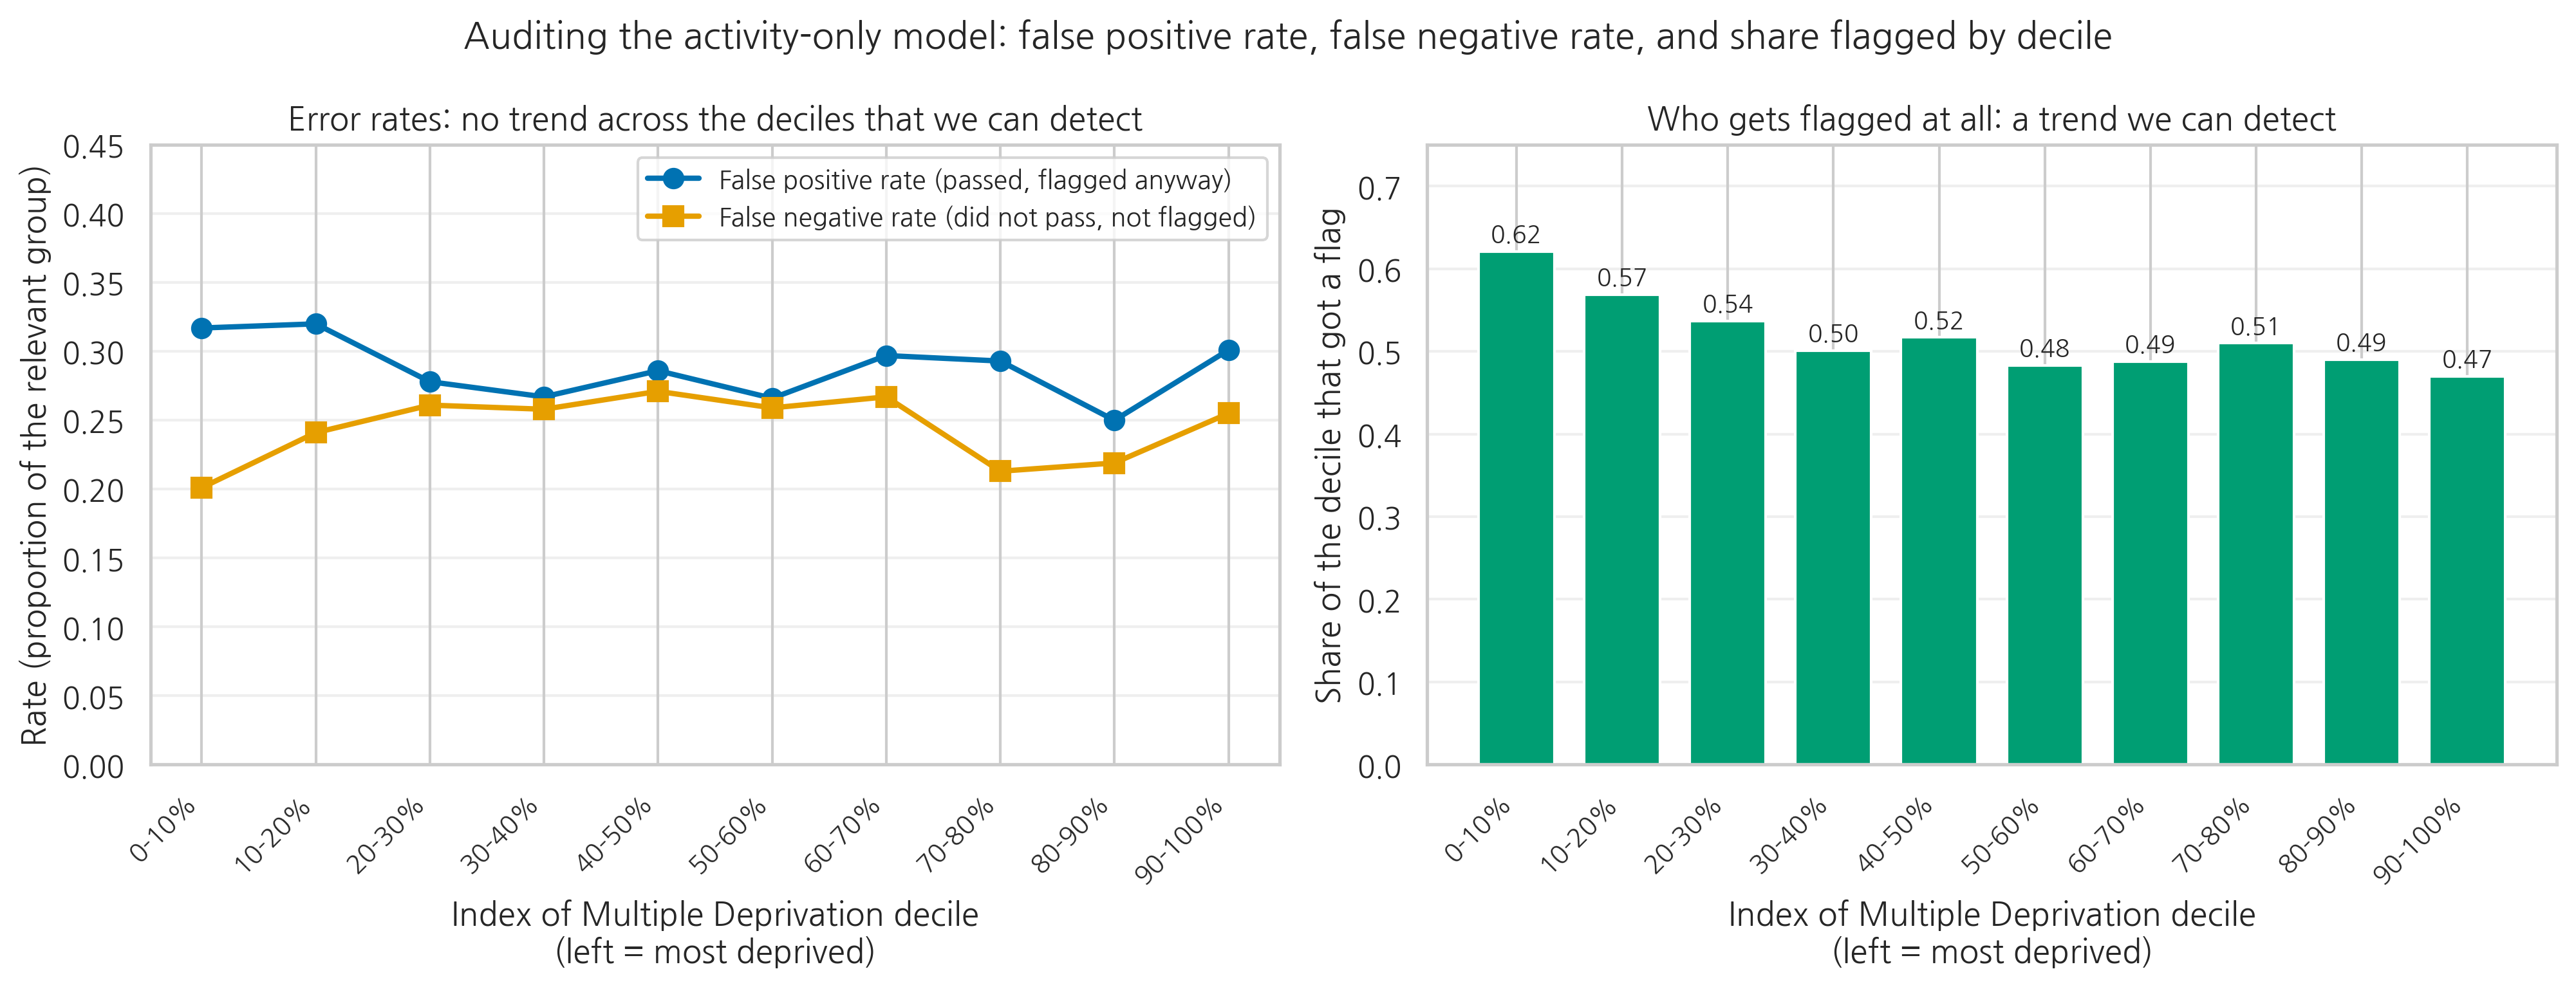

In [6]:
def audit_table(flags, groups):
    """False positive rate, false negative rate, and share flagged inside each group."""
    rows = []
    for name, mask in groups.items():
        passed_here = mask & (y_true == 0)       # in this group, the enrollment passed
        not_passed_here = mask & (y_true == 1)   # in this group, it did not
        rows.append({
            "group": name,
            "enrollments": int(mask.sum()),
            "passed (n)": int(passed_here.sum()),
            "false positive rate": round(float(flags[passed_here].mean()), 3) if passed_here.sum() else np.nan,
            "did not pass (n)": int(not_passed_here.sum()),
            "false negative rate": round(float(1 - flags[not_passed_here].mean()), 3) if not_passed_here.sum() else np.nan,
            "share flagged": round(float(flags[mask].mean()), 3),
        })
    return pd.DataFrame(rows).set_index("group")


IMD_GROUPS = {band: (data["imd_band_clean"] == band).to_numpy()
              for band in IMD_ORDER + ["Not recorded"]}
DISABILITY_GROUPS = {
    "Disability recorded":     (data["disability"] == "Y").to_numpy(),
    "No disability recorded":  (data["disability"] == "N").to_numpy(),
}

audit_imd_activity = audit_table(flags_activity, IMD_GROUPS)
audit_dis_activity = audit_table(flags_activity, DISABILITY_GROUPS)

print("ACTIVITY-ONLY MODEL, audited by deprivation decile")
print(audit_imd_activity.to_string())
print("\nACTIVITY-ONLY MODEL, audited by recorded disability")
print(audit_dis_activity.to_string())

# ---------------------------------------------------------------------------
# Ten deciles is ten comparisons, three rates deep. Guards against reading noise
# as a finding. Every resampling function below carries its own seed, so running
# a cell twice, or out of order, cannot change the interval it prints.
# ---------------------------------------------------------------------------
DECILE_X = np.arange(1, 11)
RATE_COLUMNS = ["false positive rate", "false negative rate", "share flagged"]


def decile_series(flags, column):
    """The ten decile rates for one column, plus the denominator each rests on.

    Rates come back at full precision. audit_table rounds to three decimals for
    reading, and a slope fitted through rounded points is not the slope of the data.
    """
    ys, ns = [], []
    for band in IMD_ORDER:
        mask = IMD_GROUPS[band]
        if column == "false positive rate":
            keep = mask & (y_true == 0)
            value = flags[keep].mean()
        elif column == "false negative rate":
            keep = mask & (y_true == 1)
            value = 1 - flags[keep].mean()
        else:
            keep = mask
            value = flags[keep].mean()
        ys.append(float(value))
        ns.append(int(keep.sum()))
    return np.array(ys), np.array(ns)


def gradient(flags, column):
    """Weighted least squares slope of the rate on decile number: one number, one test.

    numpy applies w to the unsquared residual, so w = sqrt(n) weights each decile by
    its denominator. That is the inverse-variance weight for a proportion up to the
    p(1 - p) factor, which barely moves across these deciles. Weighting by the full
    binomial variance instead changes every slope below by less than two percent.
    """
    ys, ns = decile_series(flags, column)
    return float(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(ns))[0])


def straight_line_check(flags, column):
    """Is ONE straight line an adequate summary of the ten points?

    Weighted squared residuals around the fitted line, read against the chi-square
    that binomial noise alone would produce. A small p-value would say the trend is
    real but not straight, and the slope would be the wrong summary of it.
    """
    from scipy.stats import chi2 as _chi2
    ys, ns = decile_series(flags, column)
    w = ns / (ys * (1 - ys))
    fitted = np.polyval(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(w)), DECILE_X)
    stat = float((w * (ys - fitted) ** 2).sum())
    return stat, float(_chi2.sf(stat, len(DECILE_X) - 2))


def gradient_interval(flags, column, n_boot=2000, seed=101):
    """Bootstrap the gradient by resampling enrollments inside each decile."""
    rng = np.random.default_rng(seed)
    idx = {b: np.where(IMD_GROUPS[b])[0] for b in IMD_ORDER}
    draws = []
    for _ in range(n_boot):
        ys, ns = [], []
        for b in IMD_ORDER:
            s = rng.choice(idx[b], idx[b].size)
            fl, yy = flags[s], y_true[s]
            if column == "false positive rate":
                keep = yy == 0
                v = fl[keep].mean()
            elif column == "false negative rate":
                keep = yy == 1
                v = 1 - fl[keep].mean()
            else:
                keep = np.ones(s.size, dtype=bool)
                v = fl.mean()
            ys.append(v)
            ns.append(keep.sum())
        draws.append(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(ns))[0])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return gradient(flags, column), float(lo), float(hi)


def gradient_interval_by_person(flags, column, n_boot=2000, seed=202):
    """The same interval, resampling PEOPLE rather than enrollments.

    47 people sat this module twice, so 47 pairs of rows are not independent draws.
    Resampling whole people keeps each pair together, which is the honest unit. Both
    rows of every repeat sit in the same deprivation decile, so the deciles stay
    intact. If the two intervals agree, the dependence was not doing anything here,
    and that is a thing we checked rather than a thing we hoped.
    """
    rng = np.random.default_rng(seed)
    people = data["id_student"].to_numpy()
    blocks = {}
    for b in IMD_ORDER:
        rows = np.where(IMD_GROUPS[b])[0]
        blocks[b] = [rows[people[rows] == p] for p in pd.unique(people[rows])]
    draws = []
    for _ in range(n_boot):
        ys, ns = [], []
        for b in IMD_ORDER:
            pick = rng.integers(0, len(blocks[b]), len(blocks[b]))
            s = np.concatenate([blocks[b][k] for k in pick])
            fl, yy = flags[s], y_true[s]
            if column == "false positive rate":
                keep = yy == 0
                v = fl[keep].mean()
            elif column == "false negative rate":
                keep = yy == 1
                v = 1 - fl[keep].mean()
            else:
                keep = np.ones(s.size, dtype=bool)
                v = fl.mean()
            ys.append(v)
            ns.append(keep.sum())
        draws.append(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(ns))[0])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return float(lo), float(hi)


def noise_range(flags, column, n_sim=4000, seed=303):
    """If all ten deciles shared ONE true rate, how big would max minus min be anyway?"""
    rng = np.random.default_rng(seed)
    ys, ns = decile_series(flags, column)
    p = float(np.average(ys, weights=ns))
    sims = np.array([[rng.binomial(n, p) / n for n in ns] for _ in range(n_sim)])
    spans = sims.max(axis=1) - sims.min(axis=1)
    return float(ys.max() - ys.min()), float(spans.mean()), np.percentile(spans, [2.5, 97.5])


print("\nTHIRTY NUMBERS, TEN DECILES: how much of the spread is just noise?")
print("(the 'if the deciles were identical' column is a simulation, not a guess)")
print(f"  {'':<22}{'denominators':>16}{'observed range':>16}{'if identical':>15}"
      f"{'  95% of the time within'}")
for column in RATE_COLUMNS:
    obs, mean_span, ci = noise_range(flags_activity, column)
    _, ns = decile_series(flags_activity, column)
    print(f"  {column:<22}{f'{ns.min()}-{ns.max()}':>16}{obs:>16.3f}{mean_span:>15.3f}"
          f"   [{ci[0]:.3f}, {ci[1]:.3f}]")

print("\nTHE GRADIENT: one question instead of ten, with a 95 percent bootstrap interval")
print("(change in the rate per one-decile step of AREA deprivation, most deprived to least.")
print(" 'straight line p' asks whether one line summarizes the ten points at all;")
print(" a small value would mean the trend is real but not straight.)")
activity_gradients = {}
for column in RATE_COLUMNS:
    point, lo, hi = gradient_interval(flags_activity, column)
    activity_gradients[column] = (point, lo, hi)
    _, p_line = straight_line_check(flags_activity, column)
    verdict = "no detectable trend" if lo < 0 < hi else "trend detected"
    print(f"  {column:<22} {point:+.4f}   95% [{lo:+.4f}, {hi:+.4f}]   {verdict:<19}"
          f"   straight line p = {p_line:.2f}")

# The 47 repeat enrollments from section 1, discharged rather than left hanging.
_person_lo, _person_hi = gradient_interval_by_person(flags_activity, "share flagged")
_enrol_lo, _enrol_hi = activity_gradients["share flagged"][1:]
print("\n  Non-independence check on the one gradient we are going to report.")
print(f"  Resampling enrollments : 95% [{_enrol_lo:+.4f}, {_enrol_hi:+.4f}]")
print(f"  Resampling people      : 95% [{_person_lo:+.4f}, {_person_hi:+.4f}]")
print("  47 people out of 4,482 contribute two rows each. Keeping each person's rows")
print("  together moves the endpoints in the fourth decimal, which is inside the wobble")
print("  of a 2,000-draw bootstrap.")

fpr_col = audit_imd_activity.loc[IMD_ORDER, "false positive rate"]
sel_col = audit_imd_activity.loc[IMD_ORDER, "share flagged"]
fnr_col = audit_imd_activity.loc[IMD_ORDER, "false negative rate"]

# ---------------------------------------------------------------- figure 2
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].plot(xpos, fpr_col.to_numpy(), marker="o", markersize=7, linewidth=2,
             color=BLUE, label="False positive rate (passed, flagged anyway)")
axes[0].plot(xpos, fnr_col.to_numpy(), marker="s", markersize=7, linewidth=2,
             color=ORANGE, label="False negative rate (did not pass, not flagged)")
axes[0].set_ylim(0, 0.45)
axes[0].set_ylabel("Rate (proportion of the relevant group)")
axes[0].set_title("Error rates: no trend across the deciles that we can detect")
axes[0].legend(loc="upper right", fontsize=9.5)

axes[1].bar(xpos, sel_col.to_numpy(), color=GREEN, width=0.72)
for i, v in enumerate(sel_col.to_numpy()):
    axes[1].text(i, v + 0.012, f"{v:.2f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel("Share of the decile that got a flag")
axes[1].set_title("Who gets flagged at all: a trend we can detect")

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile\n(left = most deprived)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Auditing the activity-only model: false positive rate, false negative rate, and share flagged by decile",
             fontsize=13.5)
fig.tight_layout()
plt.show()


**Please read the chart before you read this paragraph.** Look at the left panel, then the right panel, then decide for yourself whether this model has a fairness problem.



By **error rates**, this model looks close to even. The false positive rate ranges between 0.25 and 0.32 across the ten deciles, a spread of 0.07, and the printout shows that ten cells of this size would produce a spread of about 0.09 even if every decile shared one identical true rate. The observed spread is smaller than the noise, not larger. The gradient, which is one question instead of ten, comes out at about three thousandths of a point per decile step with a bootstrap interval straddling zero. Same for the false negative rate. If a fairness report said "we checked for equalized odds across deprivation deciles and found no detectable disparity," it would be accurate.

By **who gets flagged**, the same model is a long way from even, and this one survives every check we just made. The observed spread is 0.151 where noise alone would give about 0.075, and the gradient is about minus 0.014 per decile step with an interval nowhere near zero. Enrollments in the most deprived decile get flagged at more than 0.6, in the least deprived at under 0.5.

Both statements are true about the same 4,529 enrollments and the same set of predictions. They differ because the recorded pass rate differs so much across the deciles: when the outcome a model is looking for is more common in a group, the model can spread its errors evenly and still flag far more enrollments there.

It is a known mathematical fact about fairness metrics, and it is the concrete version of what **Holstein and Doroudi (2022)** describe. A fairness metric does not tell you whether a system is fair. It tells you which question you asked.

**Let's discuss.** The advising office has to write one sentence about this model in a memo to the provost. Write that sentence twice, once so the model sounds fine and once so it sounds alarming, using only true statements from the output above. Then compare the two and consider which one you would send, and which of them the output above actually supports. The defensible version of the alarming sentence is about who receives flags rather than about who receives errors.

### The same discipline, applied to a single comparison

The decile cell above put an interval on a *trend*. The disability column is a single two-group comparison, so it gets a single interval.

There are 412 enrollments with a recorded disability against 4,117 without, so any rate we compute for the first group rests on a much smaller denominator.

The next cell resamples the enrollments 2,000 times with replacement and reports the range that 95 percent of those resamples fall in. If that range comfortably contains zero, the difference we are looking at is inside what random variation would produce anyway, and reporting it without the interval would claim more confidence than the data supports.

One limit of this particular bootstrap: it resamples the people the model was *evaluated* on, holding the fitted model fixed. It therefore describes how much the measured rates would wobble on another sample of students, not how much they would wobble if the whole pipeline were refitted. The real uncertainty is a little wider than what prints below.

In [7]:
rng = np.random.default_rng(8100)

def gap_with_interval(flags, mask_a, mask_b, kind, n_boot=2000):
    """Difference in one error rate between two groups, plus a bootstrap interval.

    kind="fpr" restricts to enrollments that passed; kind="fnr" to those that did not.
    """
    if kind == "fpr":
        a, b = mask_a & (y_true == 0), mask_b & (y_true == 0)
        rate = lambda idx: flags[idx].mean()
    elif kind == "fnr":
        a, b = mask_a & (y_true == 1), mask_b & (y_true == 1)
        rate = lambda idx: 1 - flags[idx].mean()
    else:                                   # "sel": share of the whole group flagged
        a, b = mask_a, mask_b
        rate = lambda idx: flags[idx].mean()
    ia, ib = np.where(a)[0], np.where(b)[0]
    point = rate(ia) - rate(ib)
    draws = np.array([rate(rng.choice(ia, ia.size)) - rate(rng.choice(ib, ib.size))
                      for _ in range(n_boot)])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return point, lo, hi

has_dis = DISABILITY_GROUPS["Disability recorded"]
no_dis = DISABILITY_GROUPS["No disability recorded"]

print("DISABILITY GAP IN THE ACTIVITY-ONLY MODEL, with 95 percent bootstrap intervals")
print("(positive means the rate is worse for students with a recorded disability)\n")
dis_gaps = {}
for kind, label in [("fpr", "false positive rate"), ("fnr", "false negative rate")]:
    point, lo, hi = gap_with_interval(flags_activity, has_dis, no_dis, kind)
    dis_gaps[kind] = (point, lo, hi)
    verdict = "straddles zero" if lo < 0 < hi else "does not contain zero"
    print(f"  {label:<22} gap {point:+.3f}   95% interval [{lo:+.3f}, {hi:+.3f}]   {verdict}")

n_fp_dis = int(flags_activity[has_dis & (y_true == 0)].sum())
n_ok_dis = int((has_dis & (y_true == 0)).sum())
print(f"\n  Those rates rest on {n_fp_dis} false positives out of {n_ok_dis} enrollments that "
      f"passed\n  and carried a recorded disability.")

# for contrast: the outcome gap itself, which is not subtle
p_dis = data.loc[data["disability"] == "Y", "passed"].mean()
p_nodis = data.loc[data["disability"] == "N", "passed"].mean()
print(f"\nFor contrast, the gap the audit is NOT measuring:")
print(f"  pass rate {p_dis:.1%} with a recorded disability vs {p_nodis:.1%} without, "
      f"a gap of {(p_nodis - p_dis) * 100:.1f} percentage points.")
print("  That one is a gap in recorded outcomes, not in model errors.")

DISABILITY GAP IN THE ACTIVITY-ONLY MODEL, with 95 percent bootstrap intervals
(positive means the rate is worse for students with a recorded disability)

  false positive rate    gap +0.015   95% interval [-0.055, +0.091]   straddles zero
  false negative rate    gap +0.041   95% interval [-0.016, +0.101]   straddles zero

  Those rates rest on 50 false positives out of 166 enrollments that passed
  and carried a recorded disability.

For contrast, the gap the audit is NOT measuring:
  pass rate 40.3% with a recorded disability vs 50.0% without, a gap of 9.7 percentage points.
  That one is a gap in recorded outcomes, not in model errors.


**Let's look at the output.** The model's error rates for enrollments with a recorded disability are slightly worse than for
everyone else, and the intervals straddle zero. Resting on 166 enrollments that passed, that
difference cannot be told apart from noise. The defensible report is "no detectable disparity in error rates," and the point estimate on its own is not a finding.

The last line the cell printed is different. The **outcome** gap by disability is close to
ten percentage points, on thousands of enrollments, and it is not fragile at all.

That outcome gap is worth reading the way section 2 read the deprivation gradient. `disability` in this file records the presence of a record, not the presence of a disability, and the file does not say how the record came to exist. A ten point pass-rate gap attached to that column is a difference in recorded outcomes. The file does not record why it exists.

So the audit came back clean on a group whose recorded pass rate was 9.7 points lower. An error-rate audit asks "does the model treat these groups differently," not "is the situation these groups are in different." **Holstein and Doroudi (2022)** distinguish the two questions, and the audit asks only the first.

**Let's discuss.** If you were writing the equity section of a report on this system, would you
include the disability audit at all? What does including it risk, and what does leaving it out risk?


## Your turn 1: the number that is not in the model

`MY_THRESHOLD` decides who gets contacted. It is not a property of the algorithm and there is no
statistical procedure that sets it. Somebody picks it, and nothing in the data sets it.

The cell below already works, so you can run it as it is. Then change `MY_THRESHOLD` from `0.5` to something else (try
`0.3`, then `0.7`) and re-run **this cell only**. Nothing later in the notebook depends on it, and
the cell can be run as many times as you like.

Two things are worth watching as you move it: how many enrollments get flagged, and what happens to
the gap between the most and least deprived deciles. The cell prints a bootstrap interval next to
each gap, because a point estimate without an interval over-states precision.


In [8]:
MY_THRESHOLD = 0.5    # change this number, then re-run this cell (try 0.3, then 0.7)

flags_try = flag_at(scores_activity, MY_THRESHOLD)
table_try = audit_table(flags_try, IMD_GROUPS).loc[["0-10%", "90-100%"]]

overall_fnr = 1 - flags_try[y_true == 1].mean()
print(f"Threshold {MY_THRESHOLD:.2f}  ->  {int(flags_try.sum()):,} enrollments flagged "
      f"({flags_try.mean():.1%} of the cohort), overall accuracy {(flags_try == y_true).mean():.3f}")
print(f"Across the whole cohort this misses {overall_fnr:.1%} of the enrollments that did "
      f"not end in a pass.\n")
print(table_try[["passed (n)", "false positive rate",
                 "did not pass (n)", "false negative rate", "share flagged"]].to_string())

print("\nMost deprived decile minus least deprived, with 95 percent bootstrap intervals:")
for column, kind in [("false positive rate", "fpr"),
                     ("false negative rate", "fnr"),
                     ("share flagged", "sel")]:
    point, lo, hi = gap_with_interval(flags_try, IMD_GROUPS["0-10%"],
                                      IMD_GROUPS["90-100%"], kind)
    verdict = "straddles zero" if lo < 0 < hi else "does not contain zero"
    print(f"  {column:<22} {point:+.3f}   95% [{lo:+.3f}, {hi:+.3f}]   {verdict}")
print("\nAt 0.3, 0.5 and 0.7, only the share-flagged gap has an interval that excludes zero.")

Threshold 0.50  ->  2,381 enrollments flagged (52.6% of the cohort), overall accuracy 0.735
Across the whole cohort this misses 24.4% of the enrollments that did not end in a pass.

         passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                         
0-10%           218                0.317               373                0.201          0.621
90-100%         166                0.301               102                0.255          0.470

Most deprived decile minus least deprived, with 95 percent bootstrap intervals:
  false positive rate    +0.015   95% [-0.078, +0.111]   straddles zero
  false negative rate    -0.054   95% [-0.144, +0.043]   straddles zero


  share flagged          +0.151   95% [+0.082, +0.222]   does not contain zero

At 0.3, 0.5 and 0.7, only the share-flagged gap has an interval that excludes zero.


## 5. Changing what the model is allowed to look at

We are **not** going to change the algorithm. We are going to change **what we let it look at.**

That is a design decision. Design decisions have authors, they get written down, and somebody with the authority to revise them can revise them. 

Removed: `active_days` and `resources`. Both describe the **shape of somebody's week**: how many separate days have something in them, and how many different resources were opened. Somebody with a job might study in two long blocks instead of six short ones, with the same reading and the same effort recorded on fewer days. Notice what that argument is and is not. It is a claim about what the column measures, and this file cannot test it: nothing in OULAD records anybody's working hours. Section 5's evidence is therefore that the redesign costs no accuracy, not that the schedule-shape features were shown to be doing harm.

Added: three columns about **what a student produced and how it was judged** by day 60:

- `n_submitted`: how many of the assignments due by day 60 they handed in
- `mean_score`: their average mark on those, with the cohort median filled in for anyone who submitted nothing
- `no_submission`: 1 if that fill happened, so the model can tell an average student from an absent one

`clicks` stays, because volume of work is not the same thing as shape of schedule.

## Your turn 2: pick the feature set

The line in the next cell already contains a set that works, so run it as it is first. Then add or remove one column name and re-run to see what your choice does.

Columns you can choose from:

`clicks`, `active_days`, `resources`, `n_submitted`, `mean_score`, `no_submission`, `no_activity`, `num_of_prev_attempts`, `studied_credits`

Two questions worth holding while you choose:

1. Does this feature describe something the student **did**, or something their **circumstances** did to them?
2. If a student were told this column was being used to decide whether they get a phone call, would they feel supported or surveilled?

We are leaving `imd_band` and `disability` off that list. Whether a protected attribute should ever be a model input is a separate question.

Activity-only features : clicks, active_days, resources
  accuracy 0.735, flagged 2,381
Redesigned features    : clicks, n_submitted, mean_score, no_submission
  accuracy 0.795, flagged 1,706

REDESIGNED MODEL, audited by deprivation decile
              enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                           
0-10%                 591         218                0.073               373                0.290          0.475
10-20%                557         241                0.104               316                0.329          0.425
20-30%                566         248                0.081               318                0.296          0.431
30-40%                495         251                0.080               244                0.377          0.347
40-50%                474         227                0.057               247     


WHAT CHANGED OVERALL (whole cohort, no subgroups yet)
                              activity-only   redesigned
  false positive rate                 0.287        0.074
  false negative rate                 0.244        0.331
  share flagged                       0.526        0.377
  accuracy                            0.735        0.795
  false positives (count)               638          164
  false negatives (count)               562          763
  out of 2,224 enrollments that passed and 2,305 that did not.

  accuracy gain, redesigned minus activity-only: +0.0603   95% [+0.0477, +0.0735]

WHAT CHANGED ACROSS THE DECILES: the gradient, with 95 percent bootstrap intervals
(rate change per one-decile step. Ranges are not reported: with ten cells this size
 a range of about 0.09 on the error rates, and about 0.075 on the share flagged,
 appears even when every decile shares one identical rate.)


  false positive rate    activity-only -0.0031 [-0.0100, +0.0037]   redesigned -0.0032 [-0.0072, +0.0005]


  false negative rate    activity-only +0.0023 [-0.0042, +0.0083]   redesigned +0.0033 [-0.0036, +0.0100]


  share flagged          activity-only -0.0142 [-0.0190, -0.0089]   redesigned -0.0178 [-0.0228, -0.0127]

CHANGE IN THE SHARE-FLAGGED GRADIENT, redesigned minus activity-only


  change in the share-flagged gradient, redesigned minus activity-only: -0.0036   95% [-0.0080, +0.0007]
  A negative number means steeper, not flatter. Read the interval before the point.

WHAT CHANGED, BY RECORDED DISABILITY (with 95 percent bootstrap intervals)
  false positive rate    activity-only +0.015 [-0.055, +0.091]   redesigned +0.011 [-0.029, +0.058]
  false negative rate    activity-only +0.041 [-0.016, +0.101]   redesigned +0.007 [-0.057, +0.069]


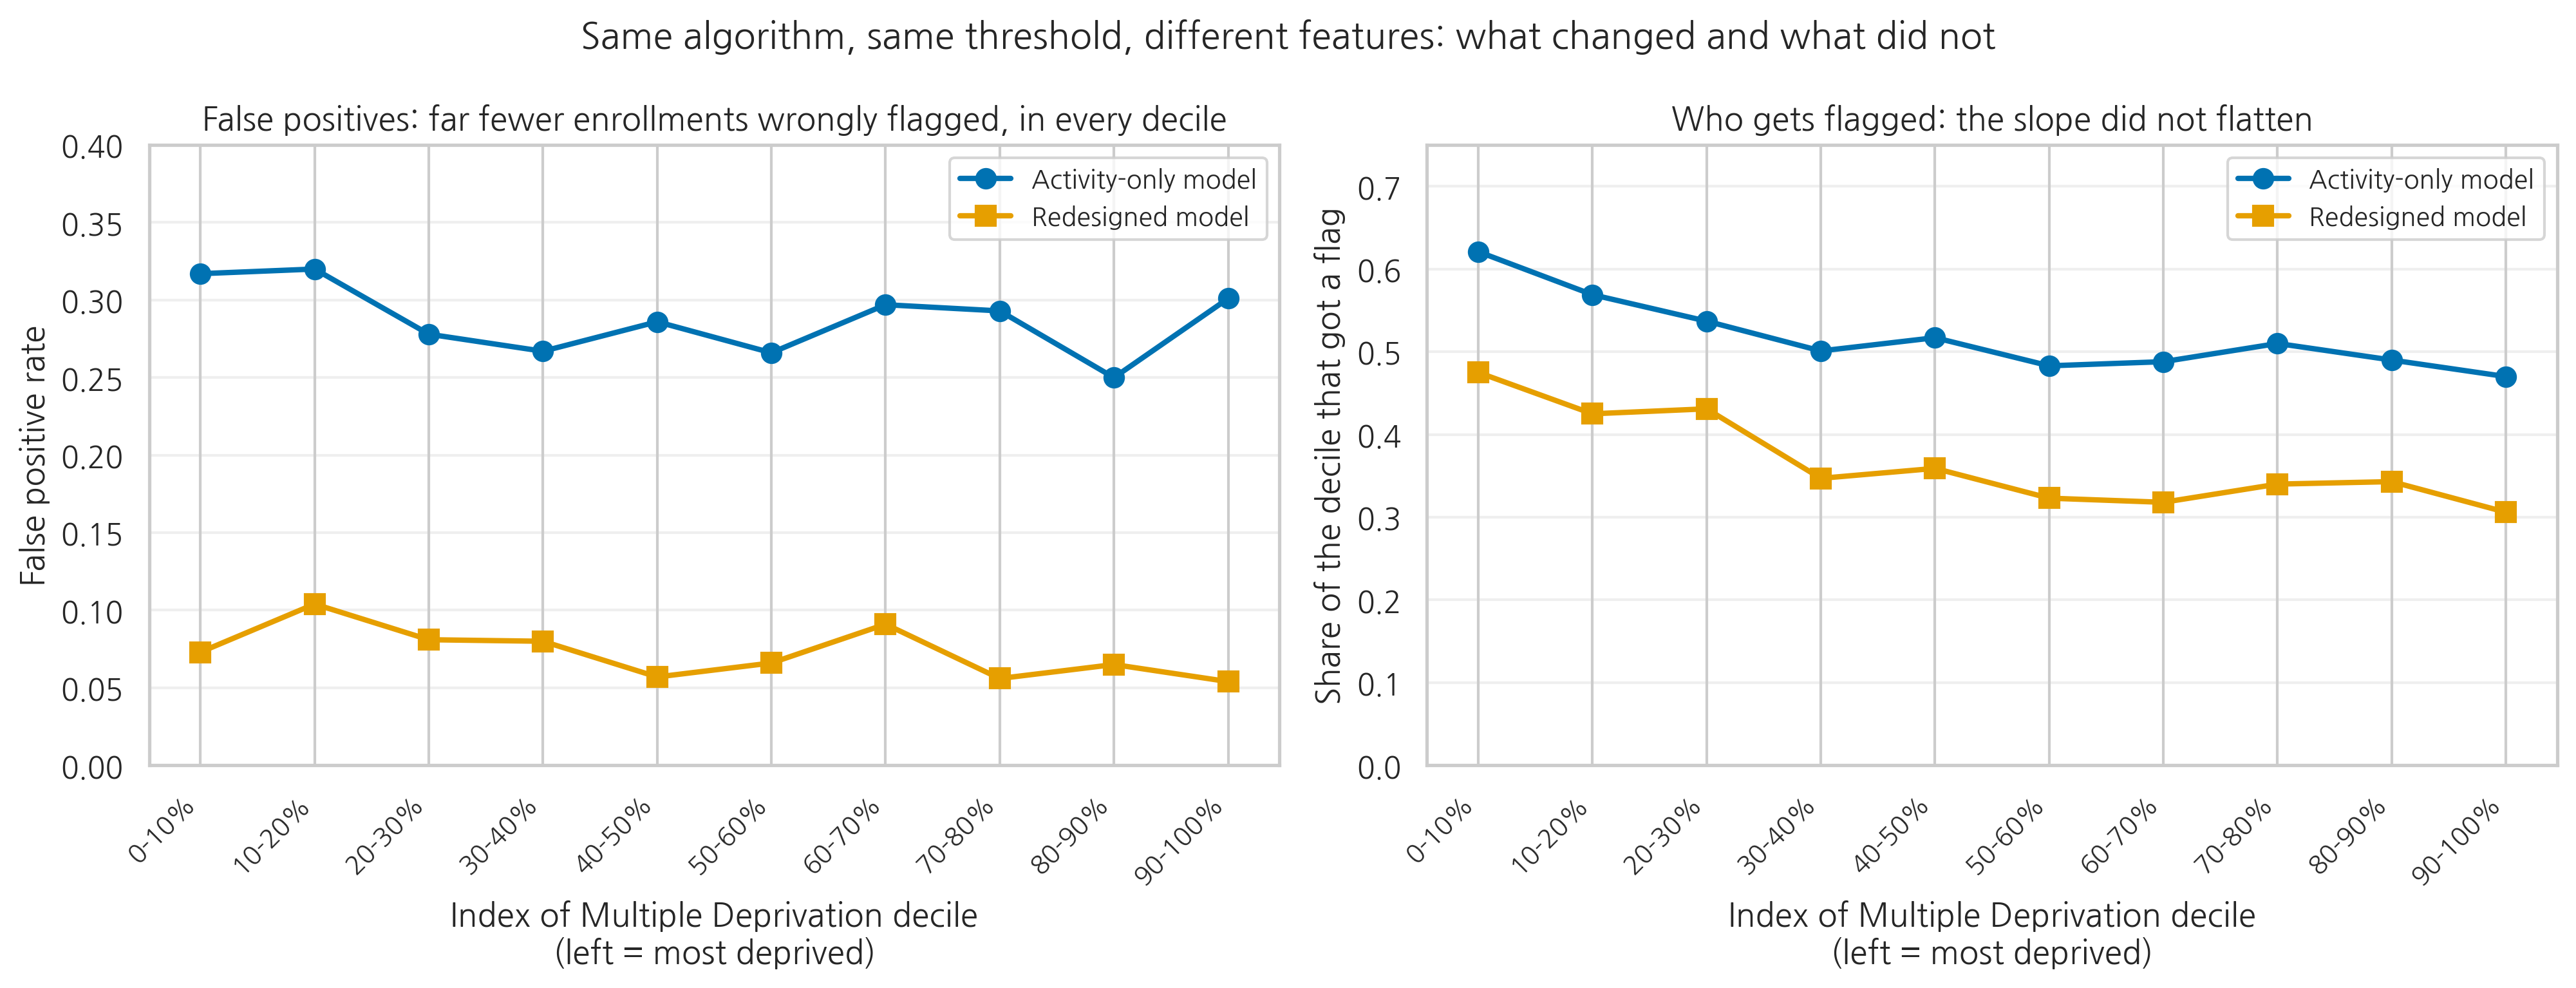

In [9]:
# TODO: choose the features for the redesigned model.
#          The default below already works. Change it once you have run it as is.
my_features = ["clicks", "n_submitted", "mean_score", "no_submission"]


# --- a friendly safety net: unknown or forbidden names fall back to the default ---
DEFAULT_REDESIGN = ["clicks", "n_submitted", "mean_score", "no_submission"]
ALLOWED = ["clicks", "active_days", "resources", "n_submitted", "mean_score",
           "no_submission", "no_activity", "num_of_prev_attempts", "studied_credits"]

usable = [c for c in my_features if c in ALLOWED]
if len(usable) != len(my_features) or not usable:
    rejected = [c for c in my_features if c not in ALLOWED]
    print(f"Heads up: {rejected} is not on the list, so we used the default set instead.")
    print(f"Choose from: {', '.join(ALLOWED)}\n")
    usable = DEFAULT_REDESIGN

REDESIGN_FEATURES = usable
scores_redesign = predicted_scores(REDESIGN_FEATURES)
flags_redesign = flag_at(scores_redesign, THRESHOLD)
accuracy_redesign = (flags_redesign == y_true).mean()

audit_imd_redesign = audit_table(flags_redesign, IMD_GROUPS)
audit_dis_redesign = audit_table(flags_redesign, DISABILITY_GROUPS)

print(f"Activity-only features : {', '.join(ACTIVITY_FEATURES)}")
print(f"  accuracy {accuracy_activity:.3f}, flagged {int(flags_activity.sum()):,}")
print(f"Redesigned features    : {', '.join(REDESIGN_FEATURES)}")
print(f"  accuracy {accuracy_redesign:.3f}, flagged {int(flags_redesign.sum()):,}\n")

print("REDESIGNED MODEL, audited by deprivation decile")
print(audit_imd_redesign.to_string())
print("\nREDESIGNED MODEL, audited by recorded disability")
print(audit_dis_redesign.to_string())

# Paired bootstrap: the SAME resampled enrollments are scored under both models,
# so this is an interval on the difference and not on two separate accuracies.
_acc_rng = np.random.default_rng(404)
_acc_draws = []
for _ in range(2000):
    _s = _acc_rng.integers(0, len(y_true), len(y_true))
    _acc_draws.append((flags_redesign[_s] == y_true[_s]).mean()
                      - (flags_activity[_s] == y_true[_s]).mean())
_acc_lo, _acc_hi = np.percentile(_acc_draws, [2.5, 97.5])

print("\nWHAT CHANGED OVERALL (whole cohort, no subgroups yet)")
print(f"  {'':<26}{'activity-only':>15}{'redesigned':>13}")
for label, fn in [("false positive rate", lambda f: f[y_true == 0].mean()),
                  ("false negative rate", lambda f: 1 - f[y_true == 1].mean()),
                  ("share flagged", lambda f: f.mean()),
                  ("accuracy", lambda f: (f == y_true).mean())]:
    print(f"  {label:<26}{fn(flags_activity):>15.3f}{fn(flags_redesign):>13.3f}")

# The same two errors as counts of people, because a rate is easy to over-read.
_n_pass, _n_fail = int((y_true == 0).sum()), int((y_true == 1).sum())
for label, fn in [("false positives (count)", lambda f: int(f[y_true == 0].sum())),
                  ("false negatives (count)", lambda f: _n_fail - int(f[y_true == 1].sum()))]:
    print(f"  {label:<26}{fn(flags_activity):>15,}{fn(flags_redesign):>13,}")
print(f"  out of {_n_pass:,} enrollments that passed and {_n_fail:,} that did not.")
print(f"\n  accuracy gain, redesigned minus activity-only: "
      f"{accuracy_redesign - accuracy_activity:+.4f}   95% [{_acc_lo:+.4f}, {_acc_hi:+.4f}]")

print("\nWHAT CHANGED ACROSS THE DECILES: the gradient, with 95 percent bootstrap intervals")
print("(rate change per one-decile step. Ranges are not reported: with ten cells this size")
print(" a range of about 0.09 on the error rates, and about 0.075 on the share flagged,")
print(" appears even when every decile shares one identical rate.)")
for column in ["false positive rate", "false negative rate", "share flagged"]:
    pa, la, ha = gradient_interval(flags_activity, column)
    pr, lr, hr = gradient_interval(flags_redesign, column)
    print(f"  {column:<22} activity-only {pa:+.4f} [{la:+.4f}, {ha:+.4f}]   "
          f"redesigned {pr:+.4f} [{lr:+.4f}, {hr:+.4f}]")

print("\nCHANGE IN THE SHARE-FLAGGED GRADIENT, redesigned minus activity-only")
_g_idx = {b: np.where(IMD_GROUPS[b])[0] for b in IMD_ORDER}


def _flag_slope(flags, sample):
    ys = [flags[sample[b]].mean() for b in IMD_ORDER]
    ws = np.sqrt([len(sample[b]) for b in IMD_ORDER])
    return np.polyfit(DECILE_X, ys, 1, w=ws)[0]


_point = _flag_slope(flags_redesign, _g_idx) - _flag_slope(flags_activity, _g_idx)
_slope_rng = np.random.default_rng(505)
_draws = []
for _ in range(2000):
    _s = {b: _slope_rng.choice(_g_idx[b], _g_idx[b].size) for b in IMD_ORDER}
    _draws.append(_flag_slope(flags_redesign, _s) - _flag_slope(flags_activity, _s))
_lo, _hi = np.percentile(_draws, [2.5, 97.5])
print(f"  change in the share-flagged gradient, redesigned minus activity-only: "
      f"{_point:+.4f}   95% [{_lo:+.4f}, {_hi:+.4f}]")
print("  A negative number means steeper, not flatter. Read the interval before the point.")

print("\nWHAT CHANGED, BY RECORDED DISABILITY (with 95 percent bootstrap intervals)")
for kind, label in [("fpr", "false positive rate"), ("fnr", "false negative rate")]:
    pa, la, ha = dis_gaps[kind]
    pr, lr, hr = gap_with_interval(flags_redesign, has_dis, no_dis, kind)
    print(f"  {label:<22} activity-only {pa:+.3f} [{la:+.3f}, {ha:+.3f}]   "
          f"redesigned {pr:+.3f} [{lr:+.3f}, {hr:+.3f}]")

# ---------------------------------------------------------------- figure 3
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].plot(xpos, audit_imd_activity.loc[IMD_ORDER, "false positive rate"], marker="o",
             markersize=7, linewidth=2, color=BLUE, label="Activity-only model")
axes[0].plot(xpos, audit_imd_redesign.loc[IMD_ORDER, "false positive rate"], marker="s",
             markersize=7, linewidth=2, color=ORANGE, label="Redesigned model")
axes[0].set_ylim(0, 0.40)
axes[0].set_ylabel("False positive rate")
axes[0].set_title("False positives: far fewer enrollments wrongly flagged, in every decile")

axes[1].plot(xpos, audit_imd_activity.loc[IMD_ORDER, "share flagged"], marker="o",
             markersize=7, linewidth=2, color=BLUE, label="Activity-only model")
axes[1].plot(xpos, audit_imd_redesign.loc[IMD_ORDER, "share flagged"], marker="s",
             markersize=7, linewidth=2, color=ORANGE, label="Redesigned model")
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel("Share of the decile that got a flag")
axes[1].set_title("Who gets flagged: the slope did not flatten")

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile\n(left = most deprived)")
    ax.legend(loc="upper right", fontsize=9.5)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Same algorithm, same threshold, different features: what changed and what did not",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### What changed, and what did not

**What changed.** Accuracy went up, from 0.735 to 0.795, and that improvement is large relative to its uncertainty: bootstrapped over enrollments, the gain is about +0.060 with a 95 percent interval of roughly [+0.048, +0.074]. The overall false positive rate fell from 0.287 to 0.074. As counts, because a rate this small is easy to over-read: 638 enrollments that went on to pass were flagged by the activity-only model and 164 by the redesigned one, 474 fewer. The disability gap in false positives, already indistinguishable from noise, stayed indistinguishable from noise.

**What we specifically cannot say.** We cannot say the redesign narrowed the *spread* of false positive rates across the deciles, and the notebook does not print that comparison. Ten cells of this size produce a max-minus-min of the same order as the ones we observed, purely by chance. The simulation in section 4 put it at about 0.09 for the activity-only model against an observed 0.07. Any sentence that compares two of those ranges is comparing two draws from noise.

**What did not change.** Look at the right panel again, and at the gradient print-out. The share-flagged gradient was about minus 0.014 per decile step before the redesign and about minus 0.018 after it, both with intervals nowhere near zero, and the change between them has an interval that includes zero. So the defensible sentence is: **the redesign did not flatten the flag gradient, and if anything it steepened it, though we cannot show the steepening exceeds noise.** Enrollments in the most deprived decile are still flagged far more often than those in the least deprived.

**And one thing got worse in a way we can measure.** The overall false negative rate rose from 0.244 to 0.331, which as counts is 562 enrollments missed becoming 763. The redesigned model made 474 fewer false positives and 201 more false negatives. The two counts go together: it flags fewer enrollments, so it misses more of the ones that did not pass. That is a whole-cohort number with a large denominator, which is why it can be stated while the decile-by-decile version of it cannot.

**Why the gradient held.** The share-flagged gradient is consistent with the pass-rate gradient in section 2: the recorded `did_not_pass` rate is 63.1 percent in the most deprived decile and 38.1 percent in the least deprived. A model that ranks enrollments by that outcome flags the first decile more often. The file does not record why the pass-rate gradient exists. Some of what was in the left panel was the feature set, and the redesign lowered the false positive rate in every decile. The right panel did not change.

**Let's discuss.** You now have two models. One scores 0.735 and flags 2,381 enrollments, most of a cohort. One scores 0.795, flags 1,706, and misses more of the enrollments that did not end in a pass. Both flag disproportionately many enrollments from the most deprived tenth. If the first had been running for three years with a vendor contract attached, what would it actually take, inside a real university, to switch? And is switching what anyone in this story should do?


### Cautions

**`mean_score` carries its own history.** An early mark may carry the effects of earlier schooling, which this file does not record. Swapping a feature that may partly encode working hours for one that may partly encode earlier schooling is a trade. It moves the problem to a column the audit did not check.

**`n_submitted` does not mean the same thing in the two presentations.** Three assignments fall on or before day 60 in 2013J and two in 2014J, so the same feature tops out at 3 in one cohort and at 2 in the other, and `mean_score`, after the median fill, averages 77.8 in 2013J and 66.1 in 2014J. We pooled them anyway. The feature therefore carries a fact about the calendar rather than about the student, which is the exact failure we just spent section 5 removing from `active_days`.

**We audited two attributes because we suspected them, and we still made thirty comparisons doing it.** `imd_band` and `disability`. A gap you never measured is not a gap you fixed, and a gap you found by scanning thirty cells for the largest one may not be a gap at all. This dataset also carries `age_band`, `gender`, `region`, and `highest_education`, and it carries nothing at all about caring responsibilities, illness, immigration status, or whether the broadband works.

**We audited a model, not an intervention.** A warm, well-staffed outreach conversation and an automatic "academic concern" note in a person's permanent file are the same flag attached to very different consequences. 

*Connecting to the readings.* Lee and Gargroetzi (2023) interviewed mentors who were handed information of this kind about the students they were supporting, and found them holding real ambivalence about it. The metaphor in their title comes from a participant rather than from the authors. 

## 6. Accuracy on the enrollments still registered at day 60

Back in section 1 we decided to keep the 836 enrollments with no clicks recorded in the first 60 days, rather than dropping them. (738 have no click anywhere in the file; narrowing to the window adds 98 more.) The cell below measures how much of the accuracy figure comes from them.

712 of those 836 enrollments had a recorded unregistration date on or before day 60, so the outcome was already recorded for them.

**Run the cell below.** It reruns the whole thing on only the enrollments **still registered** at day 60, which is the population an early warning system would be scoring. Nothing else changes.

In [10]:
still_here = data["date_unregistration"].isna() | (data["date_unregistration"] > CHECKPOINT_DAY)
gone_already = ~still_here
silent_and_gone = int((gone_already & (data["no_activity"] == 1)).sum())
print(f"Of the {int(data['no_activity'].sum()):,} enrollments with zero clicks in the window, "
      f"{silent_and_gone:,} had already formally unregistered by day {CHECKPOINT_DAY}.")
print(f"In total {int(gone_already.sum()):,} enrollments had unregistered by then.\n")

subset = data[still_here].reset_index(drop=True)
y_subset = subset["did_not_pass"].to_numpy()

X = subset[ACTIVITY_FEATURES].to_numpy(dtype=float)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
subset_scores = cross_val_predict(model, X, y_subset, cv=folds, method="predict_proba")[:, 1]
subset_flags = (subset_scores >= THRESHOLD).astype(int)

print(f"{'':<44}{'everyone':>12}{'still registered':>19}")
print(f"{'enrollments scored':<44}{len(data):>12,}{len(subset):>19,}")
print(f"{'share that ended in Fail or Withdrawn':<44}{y_true.mean():>12.3f}{y_subset.mean():>19.3f}")
print(f"{'accuracy of the activity-only model':<44}{accuracy_activity:>12.3f}"
      f"{(subset_flags == y_subset).mean():>19.3f}")
print(f"{chr(34) + 'never flag anybody' + chr(34):<44}{do_nothing:>12.3f}{(y_subset == 0).mean():>19.3f}")
print(f"\nDropped by this rule: {len(data) - len(subset):,} enrollments who had already unregistered by day "
      f"{CHECKPOINT_DAY}.")
gain_all = accuracy_activity - do_nothing
gain_sub = (subset_flags == y_subset).mean() - (y_subset == 0).mean()
print(f"\nHow far the model beats doing nothing:")
print(f"  with everyone included     {gain_all:+.3f}")
print(f"  still-registered students  {gain_sub:+.3f}")

Of the 836 enrollments with zero clicks in the window, 712 had already formally unregistered by day 60.
In total 1,006 enrollments had unregistered by then.

                                                everyone   still registered
enrollments scored                                 4,529              3,523
share that ended in Fail or Withdrawn              0.509              0.369
accuracy of the activity-only model                0.735              0.692
"never flag anybody"                               0.491              0.631

Dropped by this rule: 1,006 enrollments who had already unregistered by day 60.

How far the model beats doing nothing:
  with everyone included     +0.244
  still-registered students  +0.061


**Let's look at the output.** Against everyone, the model looks like a substantial improvement over doing nothing. Against the students it would actually be scoring, the improvement is much smaller, because 1,006 of the enrollments had a recorded unregistration date on or before day 60.

Neither column is complete on its own. The first describes the module: half of these enrollments ended in Fail or Withdrawn. The second describes the tool: an early warning system that runs on day 60 cannot help someone who unregistered on day 20.

Which of those two accuracy numbers goes in the abstract? The more flattering number is not the false one.

**Let's discuss.** What would have to appear alongside the accuracy figure for a reader to know which population it describes?

## Your turn 3 (optional): auditing another column

Everything in this section is optional and nothing later in the notebook depends on it. Please feel
free to skip it today and come back to it afterwards.

The gaps we found were ones we went looking for. This cell points the same audit at any column of
the roster.

`age_band` is the working default, so the cell runs as it is. You might try `gender`,
`highest_education`, or `region`, and note what happens to the size of the cells being compared.
Whichever column you pick, it may help to read any gap it produces the way section 2 and section 4
read the ones already here: as a difference in recorded outcomes whose cause the file does not record, rather than as a property of the group.

One point carries over from section 4, and the exercise depends on it: the more columns this is
pointed at, the more cells it generates, and the more likely it is that the largest number among
them is noise. Before reporting anything from this cell, it is worth writing down how many
comparisons were made to find it.


In [11]:
AUDIT_COLUMN = "age_band"   # try "gender", "highest_education", or "region"

if AUDIT_COLUMN not in data.columns:
    print(f"'{AUDIT_COLUMN}' is not a column in this table, so we used 'age_band' instead.\n")
    AUDIT_COLUMN = "age_band"

custom_groups = {
    f"{AUDIT_COLUMN} = {value}": (data[AUDIT_COLUMN] == value).to_numpy()
    for value in sorted(data[AUDIT_COLUMN].dropna().unique())
}

print(f"ACTIVITY-ONLY MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_activity, custom_groups).to_string())
print(f"\nREDESIGNED MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_redesign, custom_groups).to_string())
print("\nA small 'passed (n)' or 'did not pass (n)' means the rate above it is fragile.")


ACTIVITY-ONLY MODEL, audited by age_band
                  enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                               
age_band = 0-35          2987        1363                0.341              1624                0.224          0.578
age_band = 35-55         1535         858                0.200               677                0.291          0.425
age_band = 55<=             7           3                0.333                 4                0.500          0.429

REDESIGNED MODEL, audited by age_band
                  enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                               
age_band = 0-35          2987        1363                0.085              1624                0.325

---

# Part 2: the same audit, in a second setting

Enrollments in the most deprived decile get flagged far more often. Some of what the audit found came from the feature set, and we removed that part. The gradient came from somewhere, and this file cannot tell you where.

The next question is the one a reader of a fairness paper faces:

> **Does the disparity replicate in a second setting?**

A paper reports a disparity in one course, at one university, in one country. Six months later somebody runs the same audit somewhere else. Does the finding come back? If it does, it is probably about the method, or about something the two settings share. If it does not, then either the first result was noise, or it was about that place, and both of those matter enormously to what anyone should do next.

So we are going to run **one recipe on two real settings**, keeping every choice fixed except the data, and see what comes back.

Part 1 used the Open University module from week 2. Part 2 uses the 395 Portuguese secondary students in the UCI Student Performance file. The setup cell audits one feature of that file, 38 final grades of exactly 0, before anything is built on it.

## The second setting

| | |
|---|---|
| **Dataset** | UCI Student Performance, the mathematics file (`student-mat.csv`) |
| **Who collected it** | Paulo Cortez and Alice Silva, from school reports and a questionnaire administered at two Portuguese secondary schools |
| **When** | The 2005 to 2006 school year |
| **Who is in it** | 395 students, 349 at school GP and 46 at school MS |
| **License** | CC BY 4.0. Free to use and share, with attribution. |
| **Citation** | Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school student performance. In *Proceedings of 5th FUture BUsiness TEchnology Conference*, 5-12. |

**Why this one.** It differs from OULAD in country, decade, age group and collection method. The OULAD side of Part 2 is 3,136 enrollments belonging to 3,127 adults studying at a distance in the United Kingdom, measured by a server log. This is 395 teenagers at two schools in Portugal, measured by a school register and a paper questionnaire. If a finding appears in both, it is not specific to the Open University. If it appears in one, the two settings differ in something the recipe did not hold fixed.

**One feature of the file.** It holds 38 students with a final grade G3 of exactly 0. The cell below prints what else those rows contain: all 38 have zero recorded absences, all 38 have a nonzero first-period grade, 25 have a nonzero second-period grade, and no other student scored below 4. The dataset documentation does not say what a 0 means. Whether these are grades or unentered records is not established.

That leaves a decision, the way section 1 made four of them.

| The problem | What we do | What it affects |
|---|---|---|
| 38 final grades of 0 whose meaning the documentation does not state | **Keep them**, counted as below the pass mark, and rerun the whole audit without them as a sensitivity check | If they are unentered records, keeping them means the outcome column partly measures data entry. If they are grades, dropping them deletes 38 students. The cell at the end of Part 2 runs it both ways and prints what changes. |

## Setup for Part 2

**Run the cell below.** It downloads one more file, 57 kilobytes, from the same repository as the OULAD data, and rebuilds the OULAD table so that the two settings can be compared fairly. Everything it does is listed in the printout, including the decision about the 38 zero grades.

If your connection has dropped since the first cell, this one will tell you so in plain language.

In [12]:
# ---------------------------------------------------------------------------
# Setting two: 395 students at two Portuguese secondary schools.
# Semicolon separated, which is why sep=";" is there. Read it wrong and pandas
# hands you one column of 33 things glued together and no error message at all.
# ---------------------------------------------------------------------------
UCI_URL = f"{BASE}/uci-student-performance/student-mat.csv"

try:
    uci = pd.read_csv(UCI_URL, sep=";")
except Exception as problem:
    print(
        "\n"
        "We could not download the second dataset.\n"
        "\n"
        "It lives in the same public GitHub repository as the OULAD files,\n"
        "github.com/HakeoungLee/edis8100-datasets, in the folder\n"
        "uci-student-performance, as the file student-mat.csv\n"
        "\n"
        "Almost always this is one of three things:\n"
        "  1. This machine is offline, or the campus network is blocking raw.githubusercontent.com.\n"
        "  2. GitHub is temporarily unavailable. Wait a minute and run this cell again.\n"
        "  3. You are on a restricted network. Open the notebook in Google Colab instead.\n"
        "\n"
        f"The underlying complaint was: {type(problem).__name__}: {problem}\n"
    )
    raise RuntimeError("Could not download student-mat.csv. See the message above.") from None

# Two more colorblind-safe hues from the same palette as part 1.
PURPLE, VERMILLION = "#CC79A7", "#D55E00"

EARLY_DAY = 28          # four weeks: the OULAD window, matched to a school half-term
REPEATS = 25            # how many fresh 5-fold splits get averaged into every score
THRESHOLD_2 = 0.50      # same operating decision as part 1

# --- setting two: the outcome, the bands, the yes/no columns as 0/1 ----------
uci["did_not_pass"] = (uci["G3"] < 10).astype(int)      # 10 is the Portuguese pass mark
uci["parent_education"] = uci[["Medu", "Fedu"]].max(axis=1)
UCI_LOWER, UCI_HIGHER = "parents up to 9th grade", "parents secondary or higher"
uci["edu_band"] = np.where(uci["parent_education"] <= 2, UCI_LOWER, UCI_HIGHER)
for column in ["schoolsup", "famsup", "paid", "activities", "internet", "higher", "nursery"]:
    uci[column + "_yes"] = (uci[column] == "yes").astype(int)

# --- setting one, rebuilt to match: OULAD, first four weeks, no withdrawals --
early = student_vle[student_vle["date"].between(0, EARLY_DAY)]
early_activity = (
    early.groupby(["code_presentation", "id_student"])
    .agg(clicks=("sum_click", "sum"),
         active_days=("date", "nunique"),
         resources=("id_site", "nunique"))
    .reset_index()
)
oul = student_info.merge(early_activity, on=["code_presentation", "id_student"], how="left")
oul[["clicks", "active_days", "resources"]] = oul[["clicks", "active_days", "resources"]].fillna(0)
n_withdrawn = int((oul["final_result"] == "Withdrawn").sum())
oul = oul[oul["final_result"] != "Withdrawn"].reset_index(drop=True)
oul["did_not_pass"] = (oul["final_result"] == "Fail").astype(int)
OUL_LOWER, OUL_HIGHER = "below A level", "A level or above"
oul["edu_band"] = np.where(oul["highest_education"].isin(["Lower Than A Level", "No Formal quals"]),
                           OUL_LOWER, OUL_HIGHER)

UCI_FEATURES = ["absences", "studytime", "traveltime", "freetime", "goout", "famrel",
                "health", "failures", "schoolsup_yes", "famsup_yes", "paid_yes",
                "activities_yes", "internet_yes", "higher_yes", "nursery_yes"]
OUL_FEATURES = ["clicks", "active_days", "resources", "num_of_prev_attempts", "studied_credits"]

print("SETTING TWO: 395 students, two Portuguese secondary schools, 2005 to 2006")
print("  did_not_pass = 1 when the final grade G3 is below the pass mark of 10.")
print(f"  {int(uci['did_not_pass'].sum())} of {len(uci)} students, "
      f"a base rate of {uci['did_not_pass'].mean():.3f}")
print("  education bands : " + ",  ".join(f"{band} n = {n}"
      for band, n in uci["edu_band"].value_counts().items()))
print("  recorded fail rate: " + ",  ".join(f"{band} {rate:.3f}"
      for band, rate in uci.groupby("edu_band")["did_not_pass"].mean().items()))
print("  the 38 zero grades in the Portuguese file: " + ",  ".join(f"{band} {int(n)}"
      for band, n in uci.assign(z=uci["G3"] == 0).groupby("edu_band")["z"].sum().items()))
_z = uci[uci["G3"] == 0]
print(f"    what else those {len(_z)} rows hold: recorded absences {sorted(_z['absences'].unique())}, "
      f"{int((_z['G1'] > 0).sum())} with G1 > 0, {int((_z['G2'] > 0).sum())} with G2 > 0; "
      f"the smallest nonzero G3 in the file is {int(uci.loc[uci['G3'] > 0, 'G3'].min())}.")
print("    The documentation does not say what a 0 means.")
print("  schools         : " + ",  ".join(f"{s} n = {n}" for s, n in uci["school"].value_counts().items()))

print("\nSETTING ONE: OULAD module BBB, rebuilt so the two are comparable")
print("  did_not_pass = 1 when final_result is Fail, among enrollments that did not withdraw.")
print(f"  {n_withdrawn:,} withdrawn enrollments set aside; {len(oul):,} remain.")
_wd = student_info.assign(
    band=np.where(student_info["highest_education"].isin(["Lower Than A Level", "No Formal quals"]),
                  OUL_LOWER, OUL_HIGHER),
    w=(student_info["final_result"] == "Withdrawn")).groupby("band")["w"]
print("  and they did NOT come evenly from the two bands we are about to audit:")
print("    " + ",  ".join(f"{b} {r:.3f} withdrew ({int(n)} rows)"
                          for (b, r), n in zip(_wd.mean().items(), _wd.sum())))
print("    Section 7 says what that selection means for the comparison.")
print(f"  {int(oul['did_not_pass'].sum()):,} of {len(oul):,} enrollments, "
      f"a base rate of {oul['did_not_pass'].mean():.3f}")
print("  education bands : " + ",  ".join(f"{band} n = {n:,}"
      for band, n in oul["edu_band"].value_counts().items()))
print("  recorded fail rate: " + ",  ".join(f"{band} {rate:.3f}"
      for band, rate in oul.groupby("edu_band")["did_not_pass"].mean().items()))
n_repeat_people = len(oul) - oul["id_student"].nunique()
print(f"  {len(oul):,} rows are {oul['id_student'].nunique():,} people. {n_repeat_people} contribute two rows")
_rep = oul[oul.duplicated("id_student", keep=False)]
for _pres in ("2013J", "2014J"):
    _vc = _rep[_rep["code_presentation"] == _pres]["final_result"].value_counts()
    print(f"  each. In {_pres}: " + ",  ".join(f"{k} {v}" for k, v in _vc.items()))


print("\nNeither model sees G1, G2, or any mark from the course being predicted. Each sees one")
print("prior-outcome count: failures in Portugal, num_of_prev_attempts in OULAD.")
print(f"Portugal: {len(UCI_FEATURES)} columns.  OULAD: {len(OUL_FEATURES)} columns, "
      f"counted over days 0 to {EARLY_DAY}.")

SETTING TWO: 395 students, two Portuguese secondary schools, 2005 to 2006
  did_not_pass = 1 when the final grade G3 is below the pass mark of 10.
  130 of 395 students, a base rate of 0.329
  education bands : parents secondary or higher n = 260,  parents up to 9th grade n = 135
  recorded fail rate: parents secondary or higher 0.292,  parents up to 9th grade 0.400


  the 38 zero grades in the Portuguese file: parents secondary or higher 17,  parents up to 9th grade 21
    what else those 38 rows hold: recorded absences [0], 38 with G1 > 0, 25 with G2 > 0; the smallest nonzero G3 in the file is 4.
    The documentation does not say what a 0 means.
  schools         : GP n = 349,  MS n = 46

SETTING ONE: OULAD module BBB, rebuilt so the two are comparable
  did_not_pass = 1 when final_result is Fail, among enrollments that did not withdraw.
  1,393 withdrawn enrollments set aside; 3,136 remain.
  and they did NOT come evenly from the two bands we are about to audit:
    A level or above 0.259 withdrew (622 rows),  below A level 0.363 withdrew (771 rows)
    Section 7 says what that selection means for the comparison.
  912 of 3,136 enrollments, a base rate of 0.291
  education bands : A level or above n = 1,781,  below A level n = 1,355
  recorded fail rate: A level or above 0.220,  below A level 0.385
  3,136 rows are 3,127 people. 9 contribute tw

## 7. One recipe, two settings

Everything below is held fixed across the two files. Only the data changes.

1. **The outcome.** `did_not_pass = 1` for a recorded final result below the pass line. In Portugal that is `G3 < 10`, the Portuguese pass mark. In OULAD it is `final_result == "Fail"`.
2. **Who is in the population.** In OULAD we now **drop the 1,393 withdrawn enrollments** and keep the 3,136 that ran to a graded end. That is a change from Part 1, and it is the change that makes the two settings comparable: the Portuguese file has no withdrawal category. Comparing "fail or withdraw" against "fail" would have compared two different events.

   **What that means.** "Enrollments that did not withdraw" is a fact the registry records at the end of the module. Nobody knows it on day 28. So the OULAD half of Part 2 is scored on a population that can only be identified in hindsight, and no early warning system could be pointed at it on a Monday. That is exactly the move section 6 caught in Part 1, arriving here for a different reason: in Part 1 the narrowing was a fairer test of the tool, here it is the condition for making two files answer one question. It is the right call for a comparison and the wrong call for a deployment, and those are different jobs. The Portuguese file has the same problem in reverse and shows it less clearly: students who left the school before the data were collected are not in the file, so setting two is restricted to students who were present, and the file cannot say how many were not.

   **And there is a second cost, sharper than the first, because it lands on the comparison rather than on the deployment.** The 1,393 enrollments we drop are not drawn evenly from the two bands we are about to audit. 771 of the 2,126 below-A-level enrollments withdrew, against 622 of the 2,403 at A level or above: a withdrawal rate of 0.363 against 0.259. So the OULAD half of Part 2 conditions on an event that is itself strongly related to the grouping attribute, and the two bands that survive into section 9 are differently selected versions of themselves. Nothing about the arithmetic below is wrong, and the number it produces is a number about the enrollments that ran to a graded end, not about the band. Keep that attached to the OULAD result in section 10, because the finding there is a **null**, and a null on a differentially selected population is the one result this design is least able to defend. The setup cell above printed the two withdrawal rates so the size of the selection is on the page.
3. **What the model may look at.** Activity, circumstances, and one prior-outcome count. **No mark from the course being predicted.** `G1` and `G2` would predict `G3` extremely well, and they would predict it by being a grade, which teaches nothing and mirrors nothing in Part 1. So Portugal gets 15 columns about time use, family, and support, and OULAD gets 5 about early clicking and course load. Activity is counted over days 0 to 28 rather than the 60 of Part 1. That is a choice made for this comparison, not a property of either file. The Portuguese features are not time-stamped, and `absences` is the count for the whole school year, so the Portuguese model describes an association within the year rather than an early prediction. The comparison is between two activity-and-circumstance models, not two early warning systems.
4. **The algorithm and the threshold.** Standardized logistic regression, flag at 0.50, exactly as in Part 1.
5. **How every score is produced.** Repeated stratified out-of-fold prediction, which section 8 explains.

**The grouping column, and a problem with it.** We audit both settings by the education recorded in the file, in two bands.

| | Portugal | OULAD |
|---|---|---|
| Column | `Medu` and `Fedu`, the mother's and father's education | `highest_education`, the student's own prior qualification |
| Lower band | the higher of the two parents is at 9th grade or below, n = 135 | below A level, including no formal qualification, n = 1,355 |
| Higher band | secondary education or higher, n = 260 | A level or above, n = 1,781 |

**These are not the same construct.** One is a fact about the household a sixteen year old lives in. The other is a fact about the adult sitting the module. The asymmetry is worth naming precisely, because it is not simply "two different things": the Portuguese column records something the student did not produce and could not have changed, while the OULAD column records **the student's own prior attainment**, which is an earlier output of the same kind of institution that produced the outcome we are predicting. A gap by parental education is a gap by background. A gap by prior qualification may be partly a lagged version of the outcome. They will not behave the same way, and if a finding travels across them, that is more surprising than it looks; if it does not, that is less surprising than it looks. The reason they can be put in the same table is that both are the file's own record of educational background. The reason to state the difference is that if a finding travels, "educational background" is doing the work, and that phrase is covering two rather different things.

Neither column is a description of a person. Both are records of how much formal schooling somebody in the file completed, in a country and a decade, under conditions the file does not describe.

THE SAME RECIPE, THE SAME THRESHOLD, TWO SETTINGS
                                   Portugal        OULAD
  rows scored                           395        3,136
  features the model saw                 15            5
  base rate of did_not_pass           0.329        0.291
  AUC                                 0.688        0.688
  accuracy at 0.50                    0.714        0.724
  'never flag anybody'                0.671        0.709
  accuracy minus do-nothing          +0.043       +0.015
  share flagged                       0.185        0.058


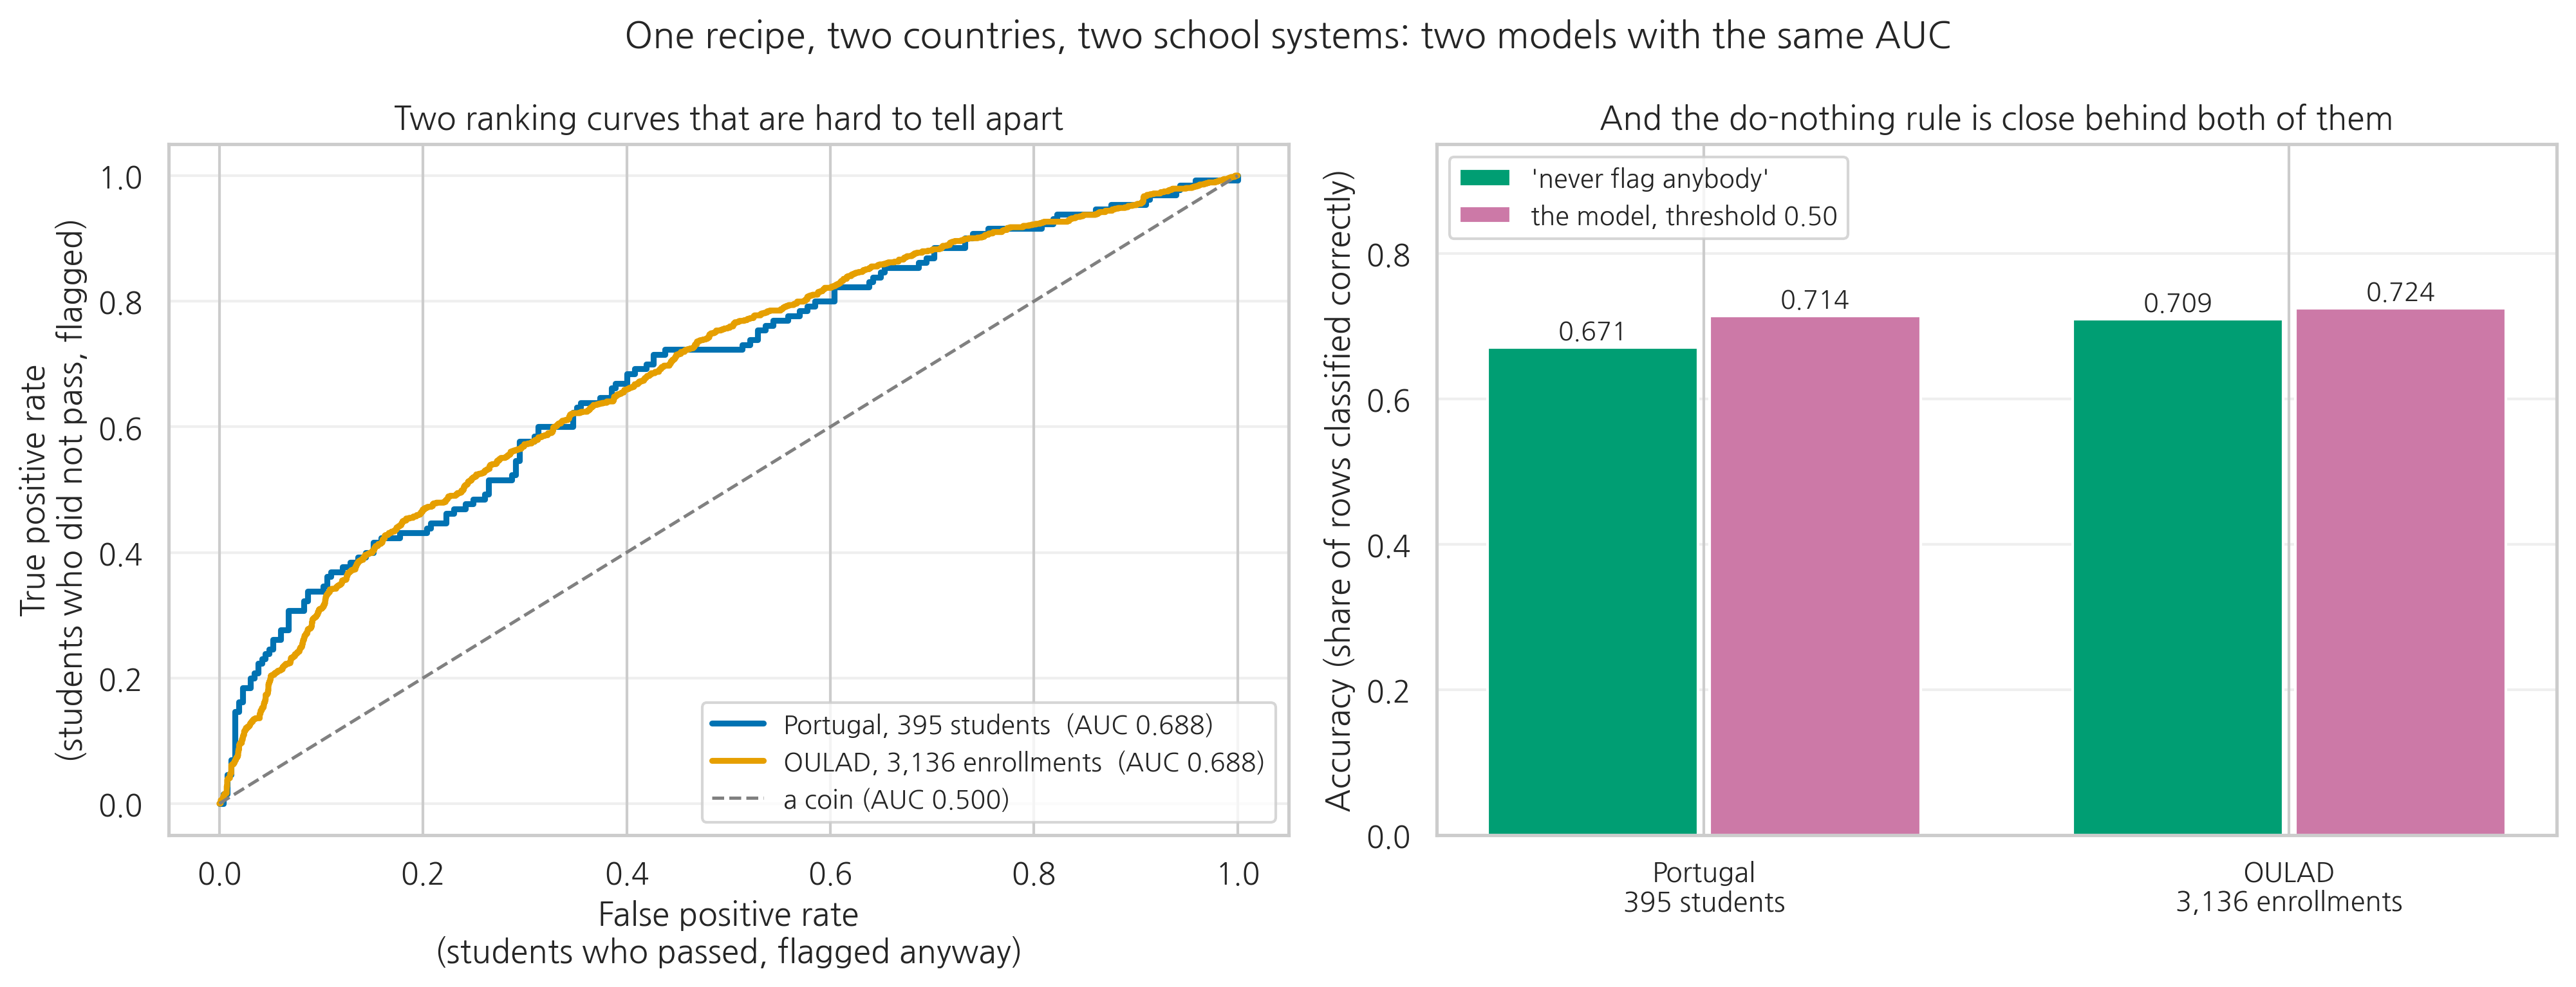

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve


def out_of_fold_scores(X, y, n_repeats=REPEATS, make_model=None, first_seed=0):
    """One predicted probability per row, averaged over n_repeats fresh 5-fold splits.

    Every score comes from a model that never saw that row's outcome. Repeating the
    whole split n_repeats times and averaging is what stops the random seed from
    choosing the answer. Section 8 measures how much that matters.
    """
    if make_model is None:
        make_model = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    total = np.zeros(len(y), dtype=float)
    for repeat in range(n_repeats):
        folds = StratifiedKFold(5, shuffle=True, random_state=first_seed + repeat)
        one_pass = np.zeros(len(y), dtype=float)
        for train_rows, test_rows in folds.split(X, y):
            model = make_model()
            model.fit(X[train_rows], y[train_rows])
            one_pass[test_rows] = model.predict_proba(X[test_rows])[:, 1]
        total += one_pass
    return total / n_repeats


y_uci, y_oul = uci["did_not_pass"].to_numpy(), oul["did_not_pass"].to_numpy()
X_uci = uci[UCI_FEATURES].to_numpy(dtype=float)
X_oul = oul[OUL_FEATURES].to_numpy(dtype=float)

scores_uci = out_of_fold_scores(X_uci, y_uci)
scores_oul = out_of_fold_scores(X_oul, y_oul)
flags_uci = (scores_uci >= THRESHOLD_2).astype(int)
flags_oul = (scores_oul >= THRESHOLD_2).astype(int)

SETTINGS = {
    "Portugal, 395 students": dict(y=y_uci, scores=scores_uci, flags=flags_uci, frame=uci,
                                   lower=UCI_LOWER, higher=UCI_HIGHER,
                                   n_features=len(UCI_FEATURES), color=BLUE),
    "OULAD, 3,136 enrollments": dict(y=y_oul, scores=scores_oul, flags=flags_oul, frame=oul,
                                     lower=OUL_LOWER, higher=OUL_HIGHER,
                                     n_features=len(OUL_FEATURES), color=ORANGE),
}

print("THE SAME RECIPE, THE SAME THRESHOLD, TWO SETTINGS")
print(f"  {'':<28}{'Portugal':>13}{'OULAD':>13}")
model_card = [
    ("rows scored",              lambda s: f"{len(s['y']):,}"),
    ("features the model saw",   lambda s: f"{s['n_features']}"),
    ("base rate of did_not_pass", lambda s: f"{s['y'].mean():.3f}"),
    ("AUC",                      lambda s: f"{roc_auc_score(s['y'], s['scores']):.3f}"),
    ("accuracy at 0.50",         lambda s: f"{(s['flags'] == s['y']).mean():.3f}"),
    ("'never flag anybody'",     lambda s: f"{(s['y'] == 0).mean():.3f}"),
    ("accuracy minus do-nothing", lambda s: f"{(s['flags'] == s['y']).mean() - (s['y'] == 0).mean():+.3f}"),
    ("share flagged",            lambda s: f"{s['flags'].mean():.3f}"),
]
for label, fn in model_card:
    print(f"  {label:<28}" + "".join(f"{fn(s):>13}" for s in SETTINGS.values()))

# ---------------------------------------------------------------- figure 4
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

for name, s in SETTINGS.items():
    fpr_curve, tpr_curve, _ = roc_curve(s["y"], s["scores"])
    axes[0].plot(fpr_curve, tpr_curve, linewidth=2.2, color=s["color"],
                 label=f"{name}  (AUC {roc_auc_score(s['y'], s['scores']):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1.2,
             label="a coin (AUC 0.500)")
axes[0].set_xlabel("False positive rate\n(students who passed, flagged anyway)")
axes[0].set_ylabel("True positive rate\n(students who did not pass, flagged)")
axes[0].set_title("Two ranking curves that are hard to tell apart")
axes[0].legend(loc="lower right", fontsize=9.5)

xpos = np.arange(len(SETTINGS))
never = [(s["y"] == 0).mean() for s in SETTINGS.values()]
model_acc = [(s["flags"] == s["y"]).mean() for s in SETTINGS.values()]
axes[1].bar(xpos - 0.19, never, width=0.36, color=GREEN, label="'never flag anybody'")
axes[1].bar(xpos + 0.19, model_acc, width=0.36, color=PURPLE, label="the model, threshold 0.50")
for i, (a, b) in enumerate(zip(never, model_acc)):
    axes[1].text(i - 0.19, a + 0.012, f"{a:.3f}", ha="center", fontsize=9.5)
    axes[1].text(i + 0.19, b + 0.012, f"{b:.3f}", ha="center", fontsize=9.5)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(["Portugal\n395 students", "OULAD\n3,136 enrollments"], fontsize=10)
axes[1].set_ylim(0, 0.95)
axes[1].set_ylabel("Accuracy (share of rows classified correctly)")
axes[1].set_title("And the do-nothing rule is close behind both of them")
axes[1].legend(loc="upper left", fontsize=9.5)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
fig.suptitle("One recipe, two countries, two school systems: two models with the same AUC",
             fontsize=13.5)
fig.tight_layout()
plt.show()

**Let's look at the output.** Two models that are hard to tell apart.

Different country, different decade, different measurement instrument, different number of features, and the two ranking curves lie almost on top of each other. AUC 0.688 in Portugal and 0.688 in OULAD. Accuracy 0.714 and 0.724 at a threshold of 0.50.

**And the second panel, which is the more useful one.** Against the do-nothing rule, which flags nobody and is right about everyone who passed, the Portuguese model reaches 0.714 against 0.671, and the OULAD model 0.724 against 0.709, differences of about four points and one and a half points. In both settings: **a model that ranks somewhat better than chance, and classifies barely better than refusing to classify.**



**Let's discuss.** The accuracy figures are 0.714 and 0.724, and the do-nothing figures are 0.671 and 0.709. Which of those four numbers would appear in a vendor's brochure, and which one would you need in order to know what the first one meant?

## 8. The protocol

This section is about how the numbers being audited get made.

The standard move in a tutorial is to split the data once, train on part of it, test on the rest, and report what you find. One seed is chosen and the notebook prints a number.

The next cell does that 200 times, changing nothing but the seed, and asks each run one fairness question: **among students who passed, were rural students flagged more often than urban students?** Rural students who passed number 55 in the whole file, so a 30 percent test set holds about 16 of them, and a rate computed on 16 people moves by 6 points every time one person changes category.

Then it runs the protocol this notebook actually uses. **Repeated stratified out-of-fold prediction**: split into five folds, predict each fold from the other four so every student is scored by a model that never saw them, then throw the split away and do the whole thing again 25 times with 25 fresh splits, and average the 25 scores. That is done 200 times too, with 5,000 different fold seeds in total.

**The two panels are not two estimates of one thing, and the cell measures the difference.** They differ in two ways at once, not one. The left protocol refits the model on a different 70 percent each time, *and* it measures the gap on the remaining 30 percent, which is about 16 rural students who passed. The right protocol scores all 395 every time. So part of the left panel's spread is the model moving and part of it is simply having thrown away most of the students you were going to measure. The cell separates them by holding the scores completely fixed and varying only which 30 percent gets measured. Read that number before concluding that repeating the split accounts for the stability.



**Run the cell below.** It takes about twenty seconds.

RURAL MINUS URBAN FALSE POSITIVE GAP, MEASURED 200 TIMES, TWO PROTOCOLS
(positive means rural students who passed were flagged more often)

                                          mean      sd   lowest  highest   say rural worse
  one 70/30 split, seeds 0 to 199       +0.048   0.098   -0.169   +0.457            65.5%
  25 splits averaged, 200 blocks        +0.026   0.014   +0.004   +0.064           100.0%

  Seed 42 on one 70/30 split : +0.327
  Larger than 99% of the other 199 seeds.
  The 25-times-averaged answer on the whole file       : +0.027

  Rural students who passed: 55 in the whole file, so about 16 in any 30 percent test set.
  One student changing category moves that rate by about six points.


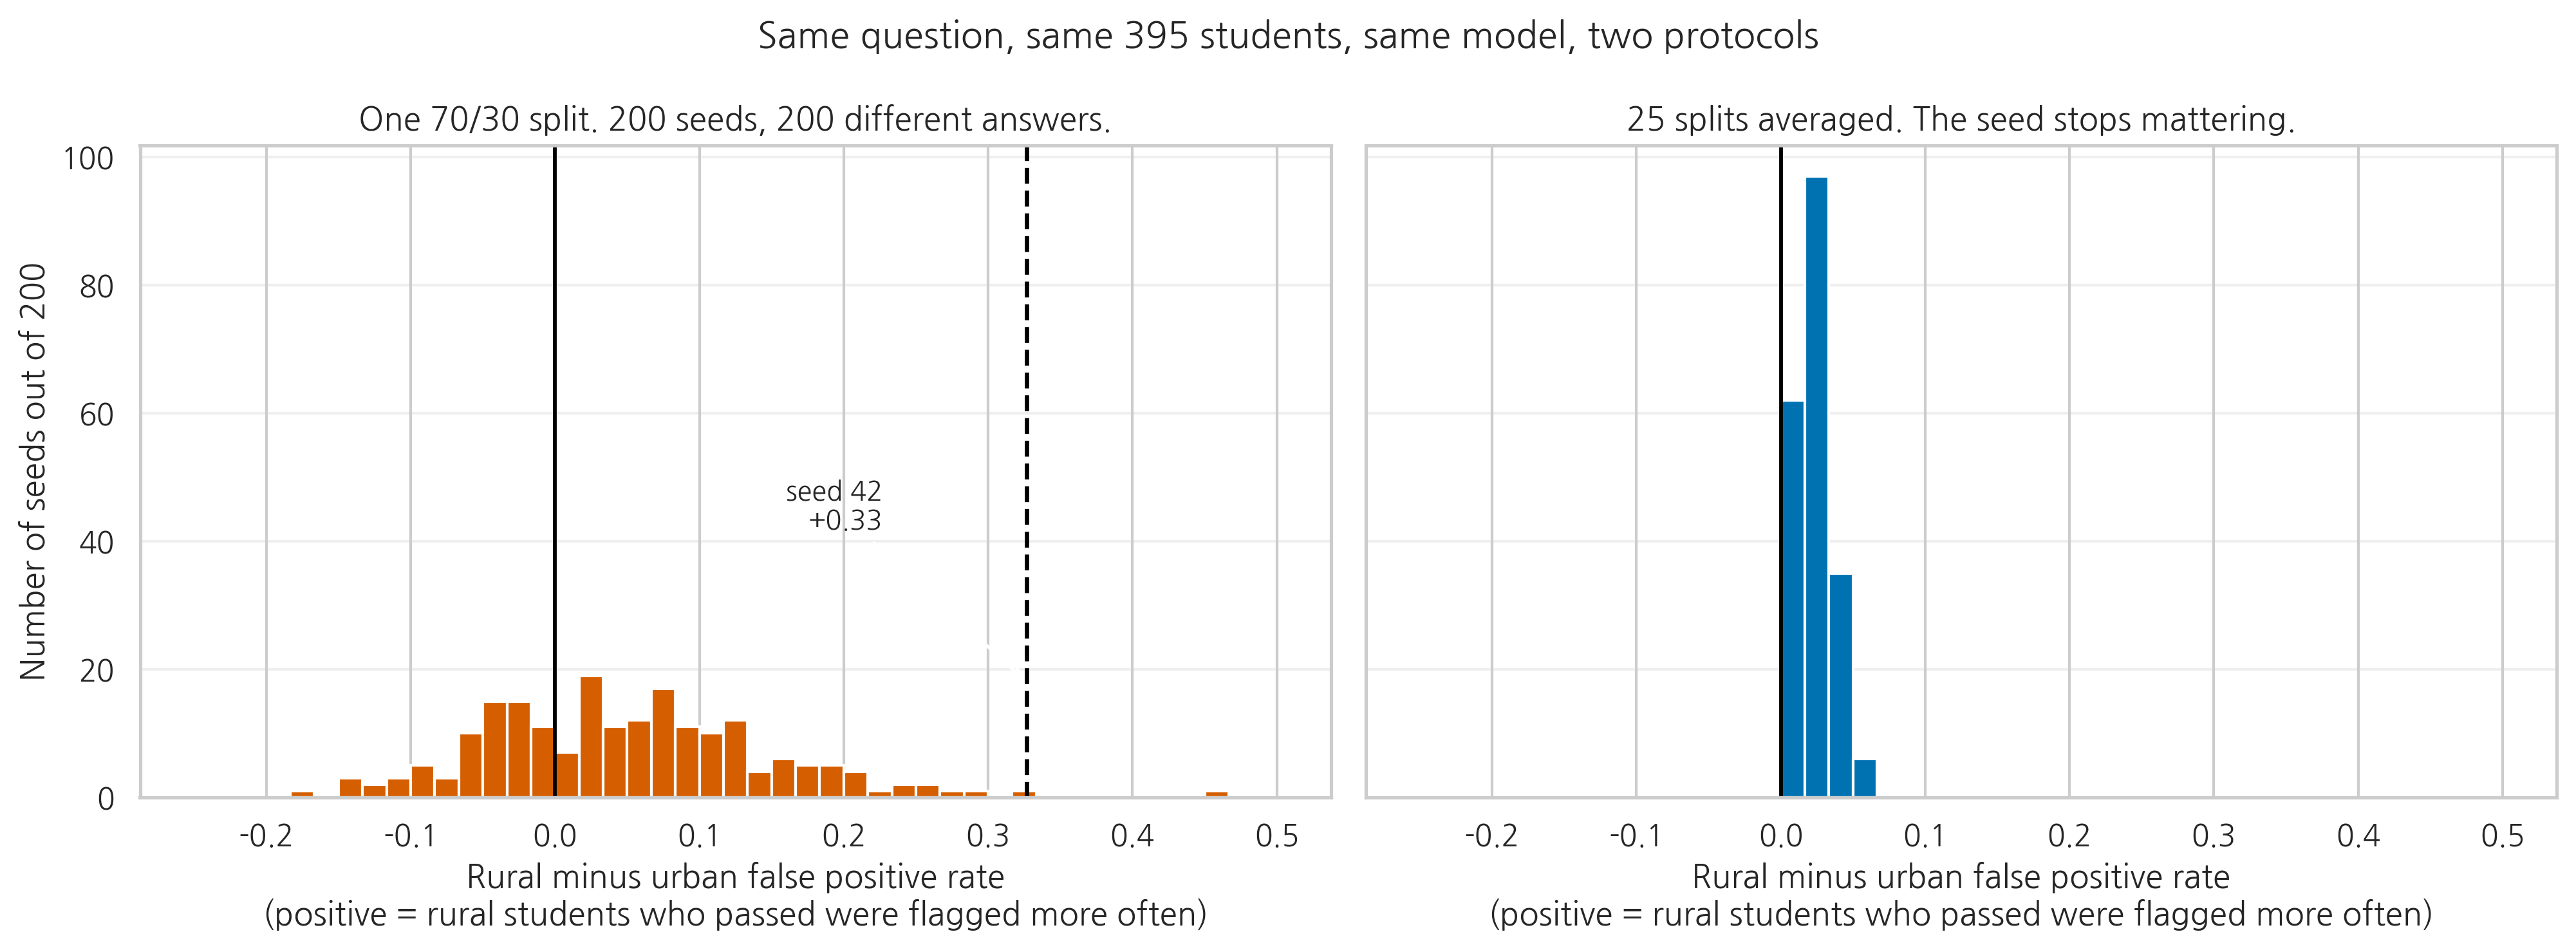


WHAT IS THE LEFT PANEL ACTUALLY MADE OF?
  one 70/30 split, model refitted each time      : sd 0.098
  the same 30% subsets, scores held FIXED        : sd 0.075
  So roughly 58% of the single-split variance is not the model moving at all.
  It is the cost of measuring a 55-person group on a 16-person sample of it.
  Averaging splits fixes the seed. Scoring every student fixes the denominator.
  The right panel did both at once, which is why it is so much tighter, and why
  it is not 25 times better evidence about the students.
Averaged over 25 splits, the rural minus urban gap is +0.027, 95 percent bootstrap interval [-0.065, +0.125].
That interval contains zero. The right panel is not a confidence interval: all 200 of
its runs measure the same 395 students, so they agree with each other by construction.
Repeating the split removes the seed. Only the bootstrap describes sampling variation over students.


In [14]:
from sklearn.model_selection import train_test_split

rural = (uci["address"] == "R").to_numpy()
urban = ~rural
N_SEEDS = 200


def false_positive_gap(flags, y, group_a, group_b):
    """Difference in false positive rate between two groups, among rows that passed."""
    a, b = group_a & (y == 0), group_b & (y == 0)
    if a.sum() == 0 or b.sum() == 0:
        return np.nan
    return flags[a].mean() - flags[b].mean()


# --- protocol A: one 70/30 split, 200 different seeds ------------------------
one_split = []
for seed in range(N_SEEDS):
    train_rows, test_rows = train_test_split(np.arange(len(y_uci)), test_size=0.30,
                                             stratify=y_uci, random_state=seed)
    single = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    single.fit(X_uci[train_rows], y_uci[train_rows])
    held_out = (single.predict_proba(X_uci[test_rows])[:, 1] >= THRESHOLD_2).astype(int)
    one_split.append(false_positive_gap(held_out, y_uci[test_rows],
                                        rural[test_rows], urban[test_rows]))
one_split = np.array(one_split)

# --- protocol B: 25 splits averaged, done 200 times, 5,000 seeds in total ----
repeated = []
for block in range(N_SEEDS):
    block_scores = out_of_fold_scores(X_uci, y_uci, n_repeats=REPEATS,
                                      first_seed=1000 + block * REPEATS)
    repeated.append(false_positive_gap((block_scores >= THRESHOLD_2).astype(int),
                                       y_uci, rural, urban))
repeated = np.array(repeated)

SEED_42 = 42
print("RURAL MINUS URBAN FALSE POSITIVE GAP, MEASURED 200 TIMES, TWO PROTOCOLS")
print("(positive means rural students who passed were flagged more often)\n")
print(f"  {'':<36}{'mean':>8}{'sd':>8}{'lowest':>9}{'highest':>9}{'say rural worse':>18}")
for label, values in [("one 70/30 split, seeds 0 to 199", one_split),
                      (f"{REPEATS} splits averaged, 200 blocks", repeated)]:
    print(f"  {label:<36}{values.mean():>+8.3f}{values.std(ddof=1):>8.3f}"
          f"{values.min():>+9.3f}{values.max():>+9.3f}{(values > 0).mean():>17.1%}")

print(f"\n  Seed 42 on one 70/30 split : {one_split[SEED_42]:+.3f}")
print(f"  Larger than {(one_split < one_split[SEED_42]).mean():.0%} of the other 199 seeds.")
print(f"  The {REPEATS}-times-averaged answer on the whole file       : "
      f"{false_positive_gap(flags_uci, y_uci, rural, urban):+.3f}")
print(f"\n  Rural students who passed: {int((rural & (y_uci == 0)).sum())} in the whole file, so about "
      f"{int(round((rural & (y_uci == 0)).sum() * 0.30))} in any 30 percent test set.")
print("  One student changing category moves that rate by about six points.")

# ---------------------------------------------------------------- figure 5
edges = np.linspace(-0.25, 0.50, 46)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True, sharey=True)

axes[0].hist(one_split, bins=edges, color=VERMILLION, edgecolor="white")
axes[0].set_title("One 70/30 split. 200 seeds, 200 different answers.")
axes[0].set_ylabel("Number of seeds out of 200")
axes[0].axvline(one_split[SEED_42], color="black", linestyle="--", linewidth=1.6)
axes[0].annotate(f"seed 42\n{one_split[SEED_42]:+.2f}", xy=(one_split[SEED_42], 18),
                 xytext=(one_split[SEED_42] - 0.10, 42), ha="right", fontsize=10,
                 arrowprops=dict(arrowstyle="->", linewidth=1.2))

axes[1].hist(repeated, bins=edges, color=BLUE, edgecolor="white")
axes[1].set_title(f"{REPEATS} splits averaged. The seed stops mattering.")

for ax in axes:
    ax.axvline(0, color="black", linewidth=1.4)
    ax.set_xlabel("Rural minus urban false positive rate\n"
                  "(positive = rural students who passed were flagged more often)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Same question, same 395 students, same model, two protocols",
             fontsize=13.5)
fig.tight_layout()
plt.show()

# How much of the left panel is "the model moved" and how much is "we measured
# 16 people instead of 55"? Hold the scores fixed, vary only the evaluation subset.
_fixed = []
for seed in range(N_SEEDS):
    _, held = train_test_split(np.arange(len(y_uci)), test_size=0.30,
                               stratify=y_uci, random_state=seed)
    _fixed.append(false_positive_gap(flags_uci[held], y_uci[held],
                                     rural[held], urban[held]))
_fixed = np.array([v for v in _fixed if not np.isnan(v)])
print("\nWHAT IS THE LEFT PANEL ACTUALLY MADE OF?")
print(f"  one 70/30 split, model refitted each time      : sd {one_split.std(ddof=1):.3f}")
print(f"  the same 30% subsets, scores held FIXED        : sd {_fixed.std(ddof=1):.3f}")
print(f"  So roughly {(_fixed.std(ddof=1) / one_split.std(ddof=1)) ** 2:.0%} of the single-split "
      f"variance is not the model moving at all.")
print("  It is the cost of measuring a 55-person group on a 16-person sample of it.")
print("  Averaging splits fixes the seed. Scoring every student fixes the denominator.")
print("  The right panel did both at once, which is why it is so much tighter, and why")
print("  it is not 25 times better evidence about the students.")

# The bootstrap is a different question from the seed, and it is the one that matters.
_rng = np.random.default_rng(8100)
_a = np.where(rural & (y_uci == 0))[0]
_b = np.where(urban & (y_uci == 0))[0]
_draws = np.array([flags_uci[_rng.choice(_a, _a.size)].mean()
                   - flags_uci[_rng.choice(_b, _b.size)].mean() for _ in range(2000)])
_lo, _hi = np.percentile(_draws, [2.5, 97.5])
print(f"Averaged over {REPEATS} splits, the rural minus urban gap is "
      f"{false_positive_gap(flags_uci, y_uci, rural, urban):+.3f}, "
      f"95 percent bootstrap interval [{_lo:+.3f}, {_hi:+.3f}].")
print("That interval contains zero. The right panel is not a confidence interval: all 200 of")
print("its runs measure the same 395 students, so they agree with each other by construction.")
print("Repeating the split removes the seed. Only the bootstrap describes sampling variation over students.")

**Please read the left panel first.** The same question, the same 395 students, the same model, the same code. The answer ranges from **-0.169 to +0.457** depending on nothing but which integer somebody typed. Two thirds of the seeds, 65.5 percent, say rural students who passed were flagged more often. A third say the opposite. The standard deviation across seeds is 0.098.

**And seed 42 gives +0.327,** larger than 99 percent of the other 199 seeds. A student who typed the default, ran the cell once, and wrote it up would report that rural students who passed were flagged 33 points more often than urban students, and would be reporting a property of the seed.

**Now the right panel.** Averaging 25 splits, the answer is +0.026 on average with a standard deviation of 0.014, and every one of the 200 runs lands between +0.004 and +0.064. The seed has stopped mattering. That is what repeating the split does, and it is the reason every number in Part 2 comes out of that loop rather than out of one split.

**Only about half of that improvement is the repetition.** The printout underneath the histograms holds the fitted scores completely still and varies nothing but which 30 percent of students gets measured, and the standard deviation falls only from 0.098 to 0.075. Somewhere near sixty percent of the left panel's variance is there because a single split measures a 55-person group on about 16 of them, not because the model changed. Both repairs are worth making and they are different repairs: averaging splits removes the seed, scoring out-of-fold on everybody removes the denominator problem. 

**What it does not do.** The tight right-hand histogram is not a confidence interval. All 200 of those runs measure the same 395 students, so they agree with each other by construction. The uncertainty that remains is about the students, not the seed, and only a bootstrap can show you that one. On the whole file the averaged rural minus urban gap is **+0.027, with a 95 percent bootstrap interval of [-0.065, +0.125]**, which comfortably contains zero.

So the defensible report on this comparison is **"no detectable difference in false alarms between rural and urban students, on 55 rural students who passed."** One seed said +0.33. Twenty-five averaged splits said +0.027. The bootstrap said we cannot tell it from zero. All three of those were computed from the same 395 people, and only the last one is a finding.

**One framing note on the quantity itself.** `address` records whether a student's home was rural or urban, so a gap across it is, in the first instance, evidence about those places and their schools rather than about the students living in them. The subject of this section is the protocol rather than the comparison.

**For your own project.** A result that changes when the seed changes is telling you about the seed. It may be useful to report the protocol that made it stop changing, and an interval beside it. Both, rather than one.

## 9. The audit, run identically in both settings

Now the same audit as Part 1: false positive rate, false negative rate, share flagged, inside each band, with the denominator printed beside every rate. There are two additions.

**Accuracy inside each band, with that band's own do-nothing rule beside it.** Accuracy is the number a report leads with, and it is the number most affected by the base rate. A group where 40 percent of students did not pass has a lower do-nothing accuracy than a group where 22 percent did not, before any model exists. Printing "never flag anybody" next to it is the only way to see which of the two you are looking at.

**AUC inside each band.** AUC asks a different question: if you drew one student who did not pass and one who did, how often does the model score the first one higher? It does not depend on the threshold and it does not depend on the base rate. That makes it the right statistic for the claim people usually mean when they say a model works less well for a group.

Every gap below is the **lower band minus the higher band**, and every one carries a 95 percent bootstrap interval built from 2,000 resamples. It may help to read the interval before the point estimate. Some of these bars cross zero, and the notebook says so rather than leaving it to the eye.

**Run the cell below.**

**One caution to carry through the whole section.** In Portugal these rates rest on 135 students against 260, and once you split by outcome, on 81 students who passed against 184, and on 54 who did not against 76. Those are small. The intervals will show you exactly how small.

AUDIT BY RECORDED EDUCATION BAND: Portugal, 395 students
                               n  base rate  never flag  accuracy    AUC  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
band                                                                                                                                                           
parents up to 9th grade      135      0.400       0.600     0.637  0.624          81                0.185                54                0.630          0.259
parents secondary or higher  260      0.292       0.708     0.754  0.728         184                0.071                76                0.671          0.146

AUDIT BY RECORDED EDUCATION BAND: OULAD, 3,136 enrollments
                     n  base rate  never flag  accuracy    AUC  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
band                                                                                         

    AUC                     -0.104   95% [-0.226, +0.020]   straddles zero
    false positive rate     +0.115   95% [+0.025, +0.209]   excludes zero
    false negative rate     -0.041   95% [-0.210, +0.126]   straddles zero
    share flagged           +0.113   95% [+0.030, +0.199]   excludes zero
    lift over never flag    -0.009   95% [-0.109, +0.086]   straddles zero

  OULAD, 3,136 enrollments


    accuracy                -0.150   95% [-0.182, -0.120]   excludes zero


    AUC                     -0.002   95% [-0.042, +0.042]   straddles zero
    false positive rate     +0.009   95% [-0.006, +0.024]   straddles zero
    false negative rate     +0.017   95% [-0.029, +0.062]   straddles zero


    share flagged           +0.017   95% [+0.001, +0.035]   excludes zero
    lift over never flag    +0.015   95% [-0.003, +0.032]   straddles zero


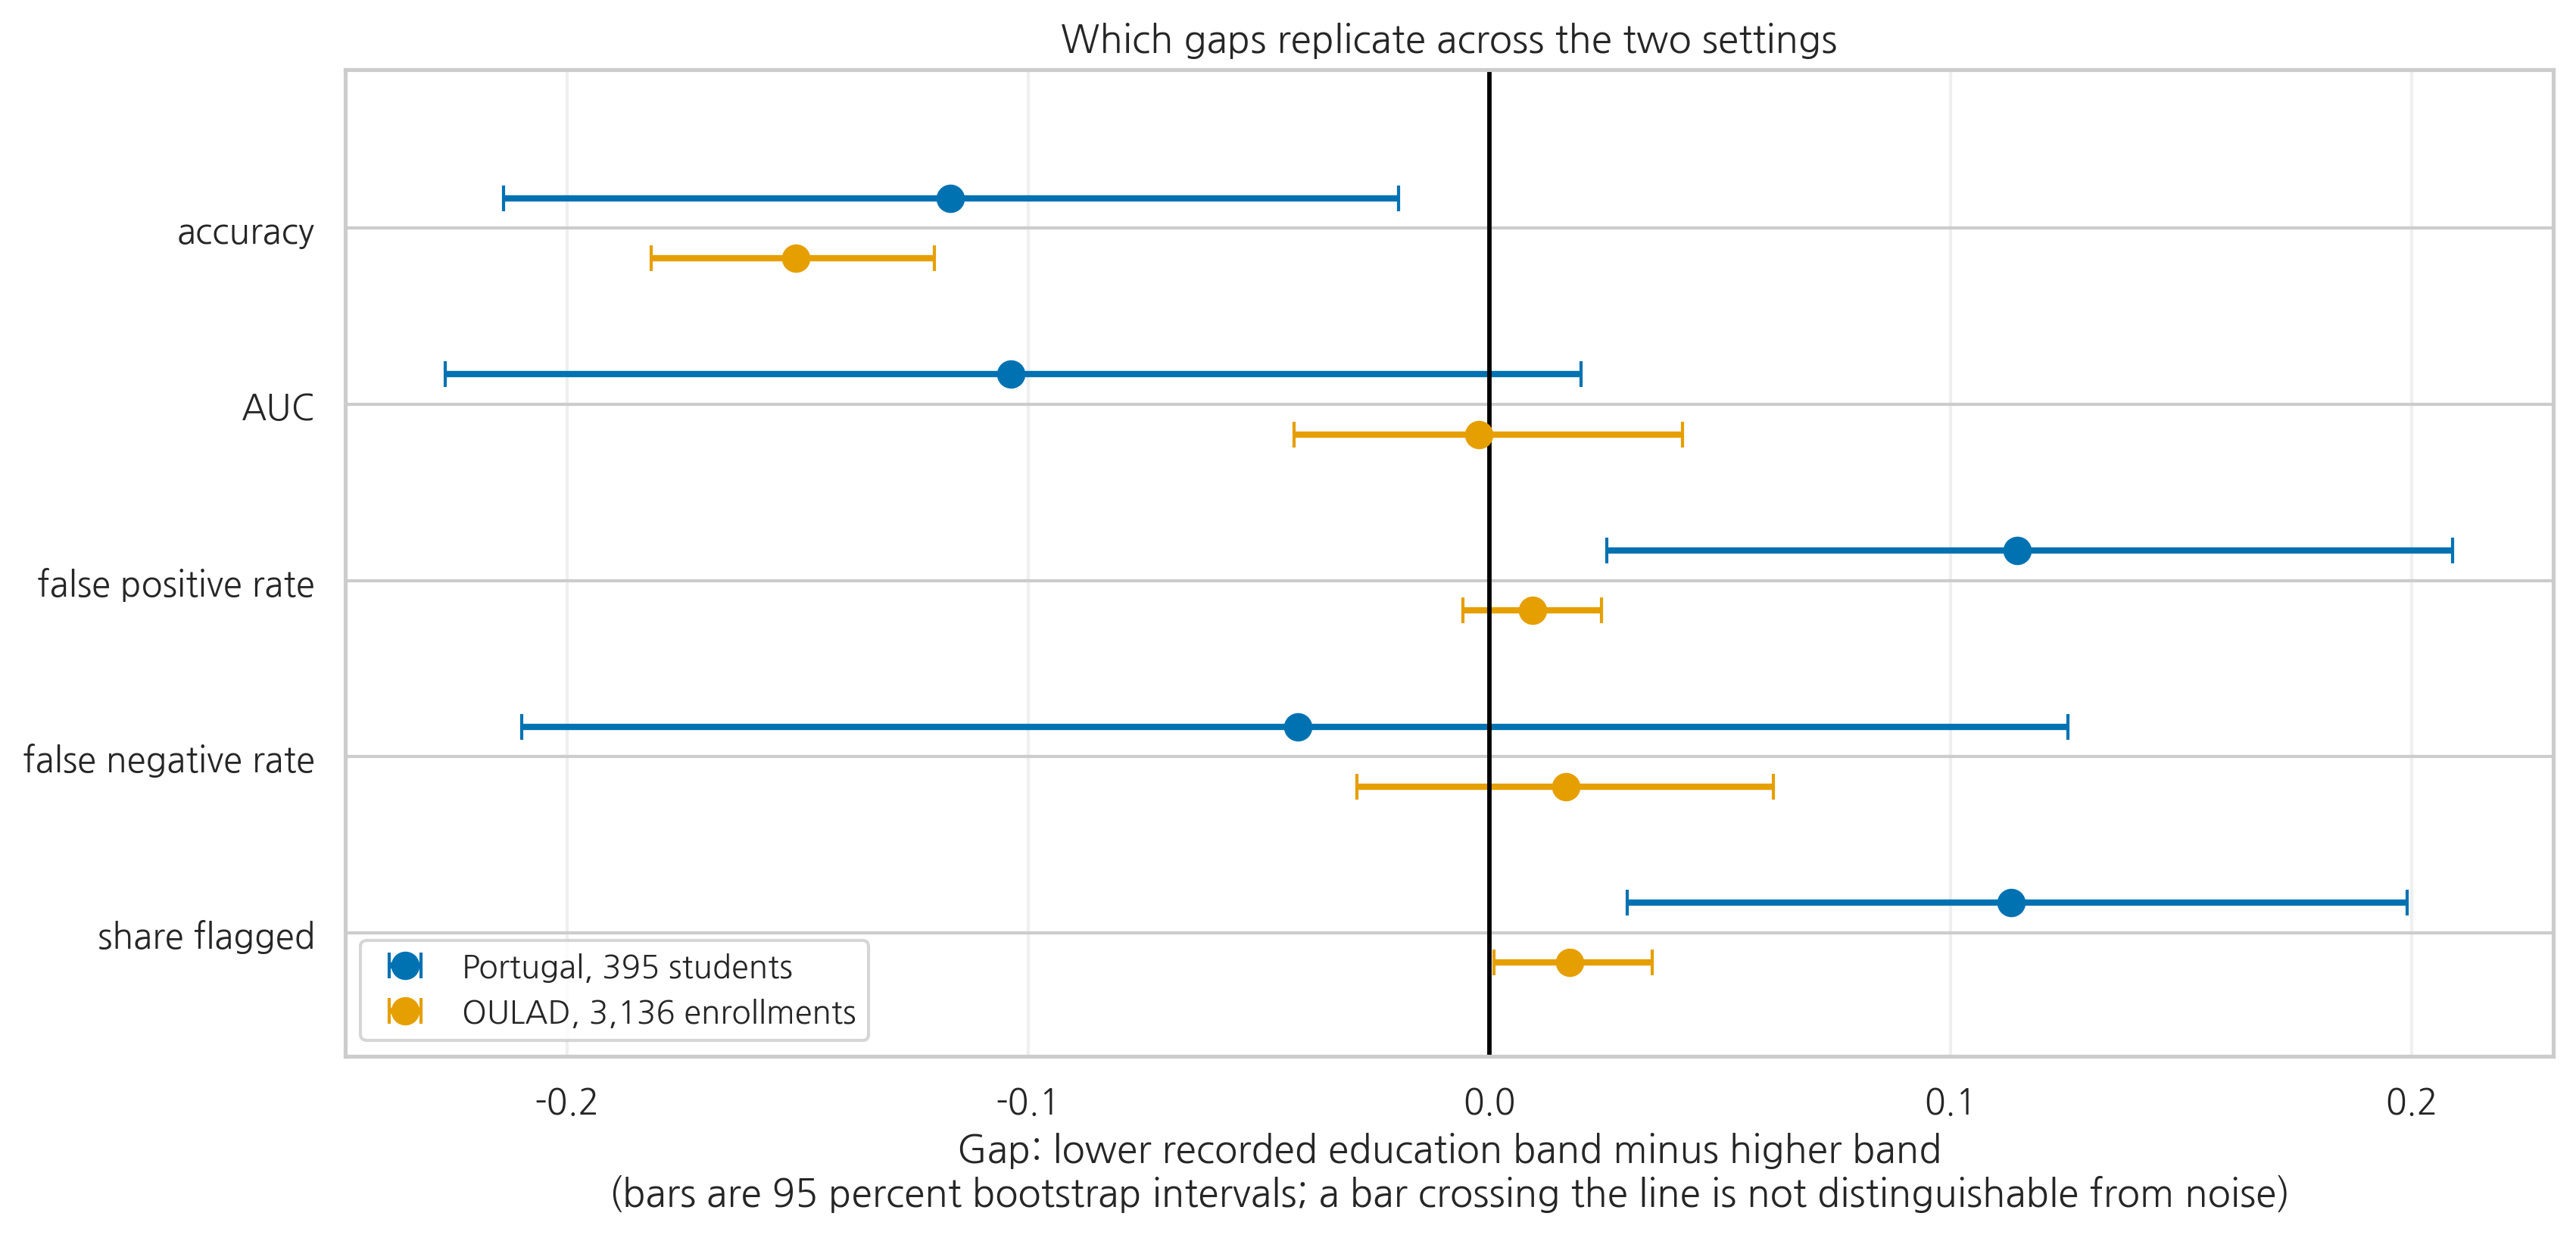

In [15]:
def band_masks(setting):
    frame = setting["frame"]
    return {setting["lower"]:  (frame["edu_band"] == setting["lower"]).to_numpy(),
            setting["higher"]: (frame["edu_band"] == setting["higher"]).to_numpy()}


def audit_bands(setting):
    """Every rate with the denominator it rests on, plus the band's own do-nothing rule."""
    y, flags, scores = setting["y"], setting["flags"], setting["scores"]
    rows = []
    for band, mask in band_masks(setting).items():
        passed, not_passed = mask & (y == 0), mask & (y == 1)
        rows.append({
            "band": band,
            "n": int(mask.sum()),
            "base rate": round(float(y[mask].mean()), 3),
            "never flag": round(float((y[mask] == 0).mean()), 3),
            "accuracy": round(float((flags[mask] == y[mask]).mean()), 3),
            "AUC": round(float(roc_auc_score(y[mask], scores[mask])), 3),
            "passed (n)": int(passed.sum()),
            "false positive rate": round(float(flags[passed].mean()), 3),
            "did not pass (n)": int(not_passed.sum()),
            "false negative rate": round(float(1 - flags[not_passed].mean()), 3),
            "share flagged": round(float(flags[mask].mean()), 3),
        })
    return pd.DataFrame(rows).set_index("band")


METRICS = ["accuracy", "AUC", "false positive rate", "false negative rate", "share flagged"]


def metric_on(y, flags, scores, rows, metric):
    yy, ff, ss = y[rows], flags[rows], scores[rows]
    if metric == "accuracy":
        return float((ff == yy).mean())
    if metric == "lift over never flag":
        return float((ff == yy).mean() - (yy == 0).mean())
    if metric == "AUC":
        return np.nan if yy.min() == yy.max() else float(roc_auc_score(yy, ss))
    if metric == "false positive rate":
        return float(ff[yy == 0].mean()) if (yy == 0).any() else np.nan
    if metric == "false negative rate":
        return float(1 - ff[yy == 1].mean()) if (yy == 1).any() else np.nan
    if metric == "share flagged":
        return float(ff.mean())
    raise ValueError(metric)


def band_gap(setting, metric, n_boot=2000, seed=8100):
    """Lower band minus higher band, with a 95 percent bootstrap interval.

    Its own generator, seeded, so running this cell twice or out of order cannot
    change the interval it prints. It resamples the rows the model was scored on,
    holding the fitted model fixed, so it describes how much these rates would
    wobble on another sample of students, not how much they would wobble if the
    whole pipeline were refitted. The real uncertainty is a little wider.
    """
    y, flags, scores = setting["y"], setting["flags"], setting["scores"]
    masks = band_masks(setting)
    a = np.where(masks[setting["lower"]])[0]
    b = np.where(masks[setting["higher"]])[0]
    point = metric_on(y, flags, scores, a, metric) - metric_on(y, flags, scores, b, metric)
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(n_boot):
        value = (metric_on(y, flags, scores, rng.choice(a, a.size), metric)
                 - metric_on(y, flags, scores, rng.choice(b, b.size), metric))
        if not np.isnan(value):
            draws.append(value)
    low, high = np.percentile(draws, [2.5, 97.5])
    return point, float(low), float(high)


for name, setting in SETTINGS.items():
    print(f"AUDIT BY RECORDED EDUCATION BAND: {name}")
    print(audit_bands(setting).to_string())
    print()

gaps = {}
print("THE SAME FIVE GAPS IN BOTH SETTINGS, lower band minus higher band")
print("(95 percent bootstrap intervals from 2,000 resamples of the rows that were scored)")
for name, setting in SETTINGS.items():
    print(f"\n  {name}")
    for metric in METRICS + ["lift over never flag"]:
        point, low, high = band_gap(setting, metric)
        gaps[(name, metric)] = (point, low, high)
        verdict = "straddles zero" if low < 0 < high else "excludes zero"
        print(f"    {metric:<22}{point:>+8.3f}   95% [{low:+.3f}, {high:+.3f}]   {verdict}")

# ---------------------------------------------------------------- figure 6
fig, ax = plt.subplots(figsize=(11.5, 5.6))
ypos = np.arange(len(METRICS))[::-1]
for k, (name, setting) in enumerate(SETTINGS.items()):
    points = np.array([gaps[(name, m)][0] for m in METRICS])
    lows = np.array([gaps[(name, m)][1] for m in METRICS])
    highs = np.array([gaps[(name, m)][2] for m in METRICS])
    ax.errorbar(points, ypos + (0.17 if k == 0 else -0.17),
                xerr=np.array([points - lows, highs - points]),
                fmt="o", markersize=8, capsize=4, linewidth=2,
                color=setting["color"], label=name)
ax.axvline(0, color="black", linewidth=1.4)
ax.set_yticks(ypos)
ax.set_yticklabels(METRICS)
ax.set_ylim(-0.7, len(METRICS) - 0.1)
ax.set_xlabel("Gap: lower recorded education band minus higher band\n"
              "(bars are 95 percent bootstrap intervals; a bar crossing the line "
              "is not distinguishable from noise)")
ax.set_title("Which gaps replicate across the two settings")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout()
plt.show()

## 10. Which gaps replicated

**Let's look at the output,** one row of the figure at a time. There are five rows and two settings, and the answer comes out different in three ways.

**The accuracy gap replicates.** The model is markedly less accurate in the lower education band in both settings: -0.117 in Portugal, 95 percent interval [-0.214, -0.020], and -0.150 in OULAD, [-0.182, -0.120].  Both intervals clear zero.

**The false alarm gap does not replicate.** In Portugal, students in the lower education band who went on to pass were flagged at 0.185 against 0.071, a gap of **+0.115 with an interval of [+0.025, +0.209]** that stays clear of zero. In OULAD the same quantity is **+0.009 with an interval of [-0.006, +0.024]**, which contains zero and is an order of magnitude smaller. The same recipe, the same threshold, the same audit. One setting has a detectable false alarm disparity by education band and the other does not.

**One objection.** "Portugal has 395 students, so of course the two settings disagree." It is worth checking which way that runs, and doing the arithmetic properly, because there are two standard errors here and they are not the same number. The Portuguese false alarm rates rest on 81 students who passed against 184. The standard error **on the observed gap** is about 0.047, which is what the bootstrap is reporting: half the width of [+0.025, +0.209] is 0.092, and 0.092 divided by 1.96 is 0.047. The standard error **under the null**, pooling the two groups, is about 0.041. Put those together and the design has two thresholds worth knowing. A gap clears zero at roughly 1.96 times 0.047, which is about **0.09**. A gap of that size would be detected only about half the time; the smallest gap this design would catch four times in five is about **0.12**. The gap it found was 0.115, which sits between the two: large enough to clear zero here, and about the smallest thing a study this size could have been counted on to find. The OULAD rates rest on 834 against 1,390, where the same two standard errors are about 0.008, so that audit would reliably catch a gap of about 0.02, roughly **six times smaller** than the one Portugal reported, and it found nothing. So the failure to replicate is not the underpowered study contradicting the well-powered one. It is the well-powered one returning a tight null around zero while the underpowered one returns about the smallest thing it could have been relied on to see. That pattern is worth recognizing: **a finding that arrives at about the smallest size its sample was ever going to catch is a finding to treat with suspicion**, and section 11 shows why this one in particular. The reason is worth saying rather than treating as a rule of thumb. A study that can only detect large effects will publish only large effects, so when such a study reports one that is barely large enough, the more likely explanations are that the effect is smaller than reported, or that it is not there, rather than that it happens to sit at the boundary.

**And one thing to hold against the OULAD null before you lean on it.** That null is computed on the 3,136 enrollments that ran to a graded end, and section 7 showed that the 1,393 we dropped did not come evenly from the two bands: 0.363 of the below-A-level enrollments withdrew against 0.259 of those at A level or above. A null measured after an unbalanced selection is weaker evidence than a null measured before one. It is still the better-powered of the two audits by a wide margin, and it is not the clean comparison the tidy version of this story would want. 

**The share flagged clears zero in both, and by different amounts.** Of everyone in the band, the share receiving a flag at all is +0.113 [+0.030, +0.199] higher in the lower band in Portugal and +0.017 [+0.001, +0.035] higher in OULAD. This is the row the person on the receiving end experiences, and it behaves the way section 4's flag gradient did: which is consistent with the higher recorded `did_not_pass` rate in the lower band, 0.400 against 0.292 in Portugal and 0.385 against 0.220 in OULAD.

**Being missed is close to even in both.** The false negative gaps are -0.041 [-0.210, +0.126] in Portugal and +0.017 [-0.029, +0.062] in OULAD. Both contain zero. The false negative gap and the AUC gap contain zero in both settings.

**And notice what the false negative rates actually are.** 0.630 and 0.671 in Portugal, 0.881 and 0.864 in OULAD. The OULAD model misses roughly seven out of eight enrollments that ended in a Fail. It is even-handed about missing them, and equalized odds is satisfied to within noise, and it is still missing nearly everybody. **A fairness metric can be satisfied by a model that does not work.**

**So put them together.** Counting only the intervals that clear zero: in Portugal three of the five gaps do, in accuracy, false alarms, and share flagged, and two do not, in AUC and false negatives. In OULAD two clear zero, in accuracy and share flagged, and three do not. Neither line is a summary of "is the model fair." They are summaries of which question somebody chose to ask.

> **Which metric you audit determines whether you see unfairness at all.** 

**These gaps are worth reading the way section 2 read the gradient.** In both settings, students in the lower recorded education band did not pass more often: 0.400 against 0.292 in Portugal, 0.385 against 0.220 in OULAD. Those are differences in recorded outcomes. Neither file records why they exist, and no sentence of the form "these students are less X" is supported by anything on this page. What the audit adds is that a model fitted to those records reproduces the pattern, and then distributes its own mistakes unevenly on top of it, differently in the two places.

**Let's discuss.** A colleague has read one of these two audits, not both, and is about to write "activity-based early warning models produce more false alarms for students from less educated households." Which audit did they read, and what is the one sentence you would add to their manuscript?

**Run the next two cells.** They take the accuracy gap apart. The first puts each band's own do-nothing rule beside its accuracy and adds the AUC inside each band. The second asks whether any of it is an artifact of logistic regression, and then reruns the whole of setting two without the 38 zero-grade records.

ACCURACY WITH EACH BAND'S DO-NOTHING RULE PRINTED BESIDE IT
                                                   never flag   model    lift        AUC (95% interval)


  Portugal: parents up to 9th grade (n = 135)           0.600   0.637  +0.037      0.624 [0.525, 0.718]


  Portugal: parents secondary or higher (n = 260)       0.708   0.754  +0.046      0.728 [0.659, 0.793]


  OULAD: below A level (n = 1,355)                      0.615   0.639  +0.024      0.687 [0.656, 0.716]


  OULAD: A level or above (n = 1,781)                   0.780   0.789  +0.009      0.689 [0.659, 0.719]

  'lift' is what the model adds to that band's own do-nothing rule. The gap between
  the two lifts is the accuracy gap with the base rate taken out of it, and the
  interval on it is printed in the cell above under 'lift over never flag'.


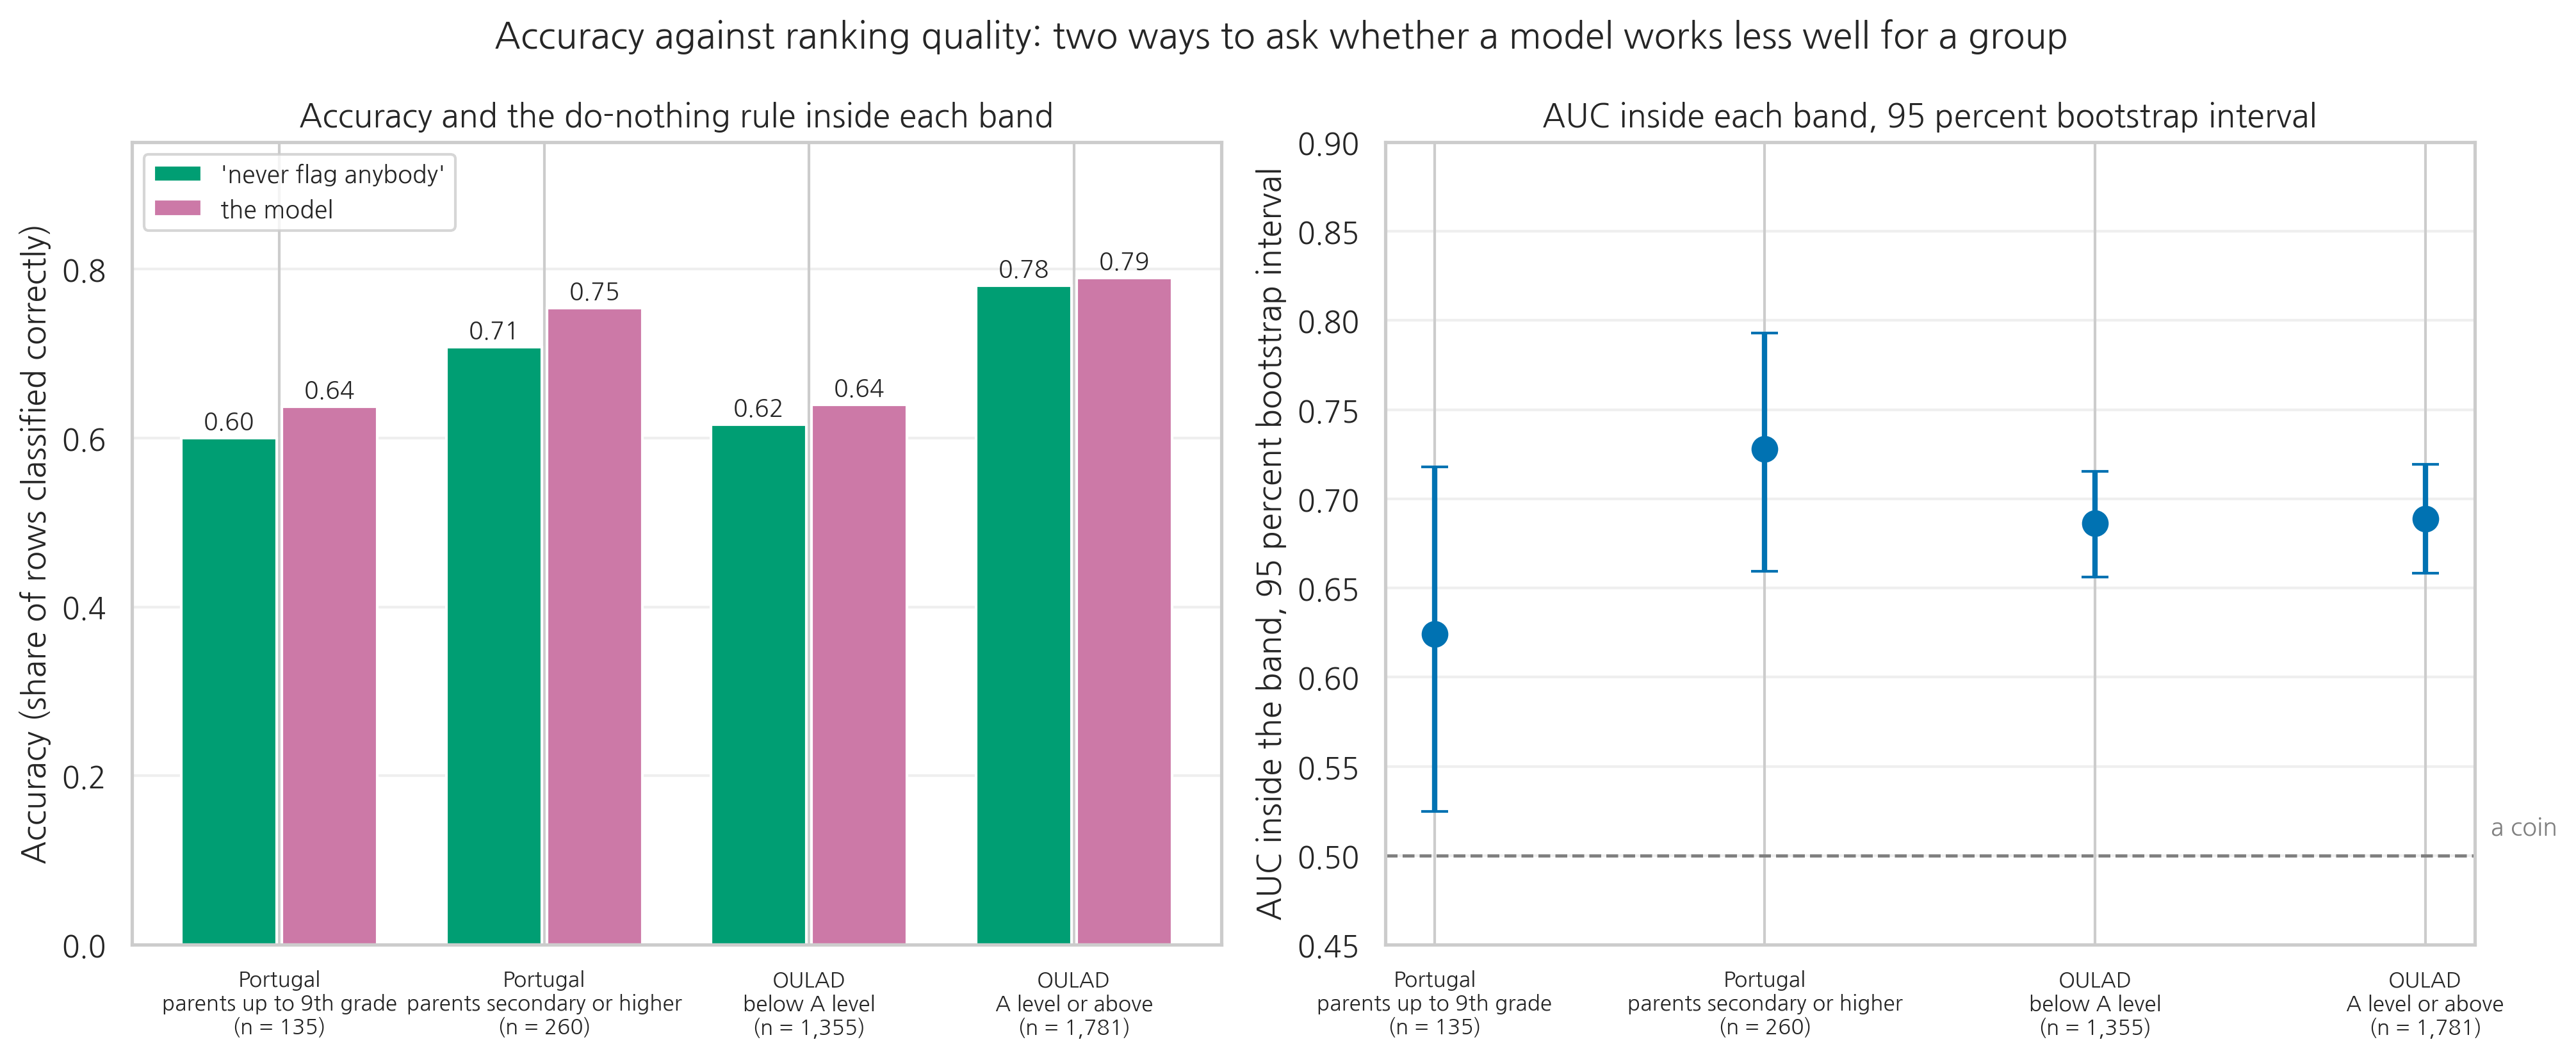

In [16]:
def auc_interval(y, scores, mask, n_boot=2000, seed=606):
    """AUC inside one band, with a 95 percent bootstrap interval."""
    rows = np.where(mask)[0]
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(n_boot):
        sample = rng.choice(rows, rows.size)
        if y[sample].min() == y[sample].max():
            continue
        draws.append(roc_auc_score(y[sample], scores[sample]))
    low, high = np.percentile(draws, [2.5, 97.5])
    return float(roc_auc_score(y[rows], scores[rows])), float(low), float(high)


print("ACCURACY WITH EACH BAND'S DO-NOTHING RULE PRINTED BESIDE IT")
print(f"  {'':<48}{'never flag':>11}{'model':>8}{'lift':>8}{'AUC (95% interval)':>26}")
band_auc = {}
band_labels, base_accs, model_accs = [], [], []
for name, setting in SETTINGS.items():
    for band, mask in band_masks(setting).items():
        never = float((setting["y"][mask] == 0).mean())
        accuracy = float((setting["flags"][mask] == setting["y"][mask]).mean())
        point, low, high = auc_interval(setting["y"], setting["scores"], mask)
        band_auc[(name, band)] = (point, low, high)
        label = f"{name.split(',')[0]}: {band} (n = {int(mask.sum()):,})"
        print(f"  {label:<48}{never:>11.3f}{accuracy:>8.3f}{accuracy - never:>+8.3f}"
              f"{f'{point:.3f} [{low:.3f}, {high:.3f}]':>26}")
        band_labels.append(f"{name.split(',')[0]}\n{band}\n(n = {int(mask.sum()):,})")
        base_accs.append(never)
        model_accs.append(accuracy)

print("\n  'lift' is what the model adds to that band's own do-nothing rule. The gap between")
print("  the two lifts is the accuracy gap with the base rate taken out of it, and the")
print("  interval on it is printed in the cell above under 'lift over never flag'.")

# ---------------------------------------------------------------- figure 7
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
xpos = np.arange(len(band_labels))

axes[0].bar(xpos - 0.19, base_accs, width=0.36, color=GREEN, label="'never flag anybody'")
axes[0].bar(xpos + 0.19, model_accs, width=0.36, color=PURPLE, label="the model")
for i, (a, b) in enumerate(zip(base_accs, model_accs)):
    axes[0].text(i - 0.19, a + 0.011, f"{a:.2f}", ha="center", fontsize=9)
    axes[0].text(i + 0.19, b + 0.011, f"{b:.2f}", ha="center", fontsize=9)
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(band_labels, fontsize=8)
axes[0].set_ylim(0, 0.95)
axes[0].set_ylabel("Accuracy (share of rows classified correctly)")
axes[0].set_title("Accuracy and the do-nothing rule inside each band")
axes[0].legend(loc="upper left", fontsize=9)

points = np.array([band_auc[k][0] for k in band_auc])
lows = np.array([band_auc[k][1] for k in band_auc])
highs = np.array([band_auc[k][2] for k in band_auc])
axes[1].errorbar(xpos, points, yerr=np.array([points - lows, highs - points]),
                 fmt="o", markersize=9, capsize=5, linewidth=2, color=BLUE)
axes[1].axhline(0.5, color="grey", linestyle="--", linewidth=1.2)
axes[1].text(len(band_labels) - 0.6, 0.512, "a coin", fontsize=9, color="grey", ha="right")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(band_labels, fontsize=8)
axes[1].set_ylim(0.45, 0.90)
axes[1].set_ylabel("AUC inside the band, 95 percent bootstrap interval")
axes[1].set_title("AUC inside each band, 95 percent bootstrap interval")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
fig.suptitle("Accuracy against ranking quality: two ways to ask whether a model works "
             "less well for a group", fontsize=13.5)
fig.tight_layout()
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

ALGORITHMS = {
    "logistic regression": lambda: make_pipeline(StandardScaler(),
                                                 LogisticRegression(max_iter=5000)),
    "random forest":       lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                          random_state=0, n_jobs=-1),
    "gradient boosting":   lambda: GradientBoostingClassifier(random_state=0),
}

print("IS THE ACCURACY GAP AN ARTIFACT OF LOGISTIC REGRESSION?")
print("(5 repeats each, same folds, same threshold, same features. Negative = the model")
print(" is less accurate in the lower education band.)\n")
print(f"  {'':<22}{'Portugal acc':>14}{'Portugal AUC':>14}{'OULAD acc':>12}{'OULAD AUC':>12}")
for label, maker in ALGORITHMS.items():
    line = f"  {label:<22}"
    for name, setting in SETTINGS.items():
        X = X_uci if setting["frame"] is uci else X_oul
        y = setting["y"]
        scores = out_of_fold_scores(X, y, n_repeats=5, make_model=maker)
        flags = (scores >= THRESHOLD_2).astype(int)
        masks = band_masks(setting)
        a, b = masks[setting["lower"]], masks[setting["higher"]]
        width = 14 if setting["frame"] is uci else 12
        line += f"{(flags[a] == y[a]).mean() - (flags[b] == y[b]).mean():>+{width}.3f}"
        line += f"{roc_auc_score(y[a], scores[a]) - roc_auc_score(y[b], scores[b]):>+{width}.3f}"
    print(line)
print("\n  The accuracy gap is there in all six cells. The Portuguese AUC gap halves when")
print("  the model class changes, which is one more reason not to report it as a finding.")

# --- week 1's 38 zero grades, held out ---------------------------------------
kept = (uci["G3"] > 0).to_numpy()
y_nz = y_uci[kept]
scores_nz = out_of_fold_scores(X_uci[kept], y_nz)
flags_nz = (scores_nz >= THRESHOLD_2).astype(int)
lower_nz = (uci.loc[kept, "edu_band"] == UCI_LOWER).to_numpy()
higher_nz = ~lower_nz

_rng = np.random.default_rng(8100)
_a = np.where(lower_nz & (y_nz == 0))[0]
_b = np.where(higher_nz & (y_nz == 0))[0]
_point = flags_nz[_a].mean() - flags_nz[_b].mean()
_draws = np.array([flags_nz[_rng.choice(_a, _a.size)].mean()
                   - flags_nz[_rng.choice(_b, _b.size)].mean() for _ in range(2000)])
_low, _high = np.percentile(_draws, [2.5, 97.5])

n_zero_lower = int(((uci["G3"] == 0) & (uci["edu_band"] == UCI_LOWER)).sum())
n_zero_higher = int(((uci["G3"] == 0) & (uci["edu_band"] == UCI_HIGHER)).sum())
n_lower = int((uci["edu_band"] == UCI_LOWER).sum())
n_higher = int((uci["edu_band"] == UCI_HIGHER).sum())

print("\nWHAT IF THE 38 ZERO GRADES ARE NOT GRADES? (week 1's finding, rerun as a check)")
print(f"  Where those 38 sit: {n_zero_lower} of the {n_lower} students in the lower band "
      f"({n_zero_lower / n_lower:.1%}),")
print(f"  against {n_zero_higher} of the {n_higher} in the higher band "
      f"({n_zero_higher / n_higher:.1%}).")
try:
    from scipy.stats import fisher_exact
    _table = [[n_zero_lower, n_lower - n_zero_lower], [n_zero_higher, n_higher - n_zero_higher]]
    print(f"  Fisher exact test on that 2 by 2 table: p = {fisher_exact(_table)[1]:.3f}")
    # The rival explanation a reader will reach for first: the two schools keep
    # records differently AND enrol different families, so this is really a school
    # effect wearing an education band as a disguise. Test it instead of asserting.
    # Every name here carries a school_ prefix: _a and _b are already taken by the
    # index arrays this cell built above, and quietly rebinding them would break
    # the printout underneath without saying so.
    for school_code in ["GP", "MS"]:
        school_rows = uci["school"] == school_code
        school_zeros = int(((uci["G3"] == 0) & school_rows).sum())
        print(f"  School {school_code}: {school_zeros} zeros in {int(school_rows.sum())} "
              f"students ({school_zeros / school_rows.sum():.1%})")
    gp = uci[uci["school"] == "GP"]
    gp_zero_lower = int(((gp["edu_band"] == UCI_LOWER) & (gp["G3"] == 0)).sum())
    gp_n_lower = int((gp["edu_band"] == UCI_LOWER).sum())
    gp_zero_higher = int(((gp["edu_band"] == UCI_HIGHER) & (gp["G3"] == 0)).sum())
    gp_n_higher = int((gp["edu_band"] == UCI_HIGHER).sum())
    gp_p = fisher_exact([[gp_zero_lower, gp_n_lower - gp_zero_lower],
                         [gp_zero_higher, gp_n_higher - gp_zero_higher]])[1]
    print("  The two schools carry zeros at very nearly the same rate, so the pattern")
    print("  is not a difference between the buildings. And it survives inside the")
    print("  larger of the two on its own:")
    print(f"    GP alone: {gp_zero_lower} of {gp_n_lower} "
          f"({gp_zero_lower / gp_n_lower:.1%}) against {gp_zero_higher} of {gp_n_higher} "
          f"({gp_zero_higher / gp_n_higher:.1%}), Fisher p = {gp_p:.3f}")
except Exception:
    pass
print(f"\n  Rerun without them: {len(y_nz)} students, base rate {y_nz.mean():.3f}, "
      f"AUC {roc_auc_score(y_nz, scores_nz):.3f},")
print(f"  accuracy {(flags_nz == y_nz).mean():.3f} against a do-nothing rule of "
      f"{(y_nz == 0).mean():.3f}, so the model now adds {(flags_nz == y_nz).mean() - (y_nz == 0).mean():+.3f}.")
print(f"  Bands are now n = {int(lower_nz.sum())} and {int(higher_nz.sum())}, resting on "
      f"{len(_a)} and {len(_b)} students who passed.")
_full = gaps[("Portugal, 395 students", "false positive rate")]
print(f"\n  False positive gap, all 395 students : {_full[0]:+.3f}  95% [{_full[1]:+.3f}, {_full[2]:+.3f}]"
      f"   {'excludes zero' if not (_full[1] < 0 < _full[2]) else 'straddles zero'}")
print(f"  False positive gap, the 38 removed   : {_point:+.3f}  95% [{_low:+.3f}, {_high:+.3f}]"
      f"   {'excludes zero' if not (_low < 0 < _high) else 'straddles zero'}")
print(f"\n  And notice which numbers did NOT move. The false positive rate is computed")
print(f"  among students who passed, and all 38 of these records sit at G3 = 0, so every")
print(f"  one of them is a did_not_pass row. The two denominators are {len(_a)} and {len(_b)}")
print(f"  with the 38 in the file and {len(_a)} and {len(_b)} with them removed: identical.")
print("  So the gap did not halve because we took people out of the comparison. It")
print("  halved because those 38 rows were in the TRAINING data, teaching the model a")
print("  pattern that a data entry habit put there. The audit was reading a filing")
print("  cabinet through the model's coefficients.")
print("\n  Same direction, roughly half the size, and no longer clear of zero. Our one")
print("  detectable disparity in setting two depends on how 38 records are treated.")

IS THE ACCURACY GAP AN ARTIFACT OF LOGISTIC REGRESSION?
(5 repeats each, same folds, same threshold, same features. Negative = the model
 is less accurate in the lower education band.)

                          Portugal acc  Portugal AUC   OULAD acc   OULAD AUC
  logistic regression           -0.113        -0.100      -0.147      -0.002


  random forest                 -0.084        -0.058      -0.116      -0.010


  gradient boosting             -0.132        -0.054      -0.129      -0.024

  The accuracy gap is there in all six cells. The Portuguese AUC gap halves when
  the model class changes, which is one more reason not to report it as a finding.

WHAT IF THE 38 ZERO GRADES ARE NOT GRADES? (week 1's finding, rerun as a check)
  Where those 38 sit: 21 of the 135 students in the lower band (15.6%),
  against 17 of the 260 in the higher band (6.5%).
  Fisher exact test on that 2 by 2 table: p = 0.006
  School GP: 34 zeros in 349 students (9.7%)
  School MS: 4 zeros in 46 students (8.7%)
  The two schools carry zeros at very nearly the same rate, so the pattern
  is not a difference between the buildings. And it survives inside the
  larger of the two on its own:
    GP alone: 18 of 117 (15.4%) against 16 of 232 (6.9%), Fisher p = 0.020

  Rerun without them: 357 students, base rate 0.258, AUC 0.724,
  accuracy 0.751 against a do-nothing rule of 0.742, so the model now adds +0.008.
  Bands are 

## 11. The accuracy gap, and the thing observational data cannot settle

The accuracy gap was the finding that replicated. So it is worth asking what it is made of, because there are two very different stories that produce the same number.

**Story one: it is arithmetic.** In the lower band a larger share of students did not pass, so the do-nothing rule is worse there before any model exists. A model that beats do-nothing by the same margin in both bands will still post a lower accuracy in the band with the higher base rate. Nothing about the model differs. The base rate differs.

**Story two: it is a measurement failure.** The features genuinely carry less information about students in that band. Clicks, absences, and questionnaire answers mean something slightly different when the conditions of studying are different, so the same instrument reads them less well, and the model that depends on them is genuinely worse at ranking those students.

Those two stories have exactly the same consequence for the accuracy column and completely different consequences for what anyone should do. The first is a reason to stop reporting group accuracy. The second is a reason to stop deploying the instrument.

**The two cells above separate them, and the answer differs by setting.**

**Let's look at the output.** In the left panel of figure 7, in Portugal the model beats each band's own do-nothing rule by +0.037 in the lower band and +0.046 in the higher one, and the gap between those two lifts is **-0.009 with an interval of [-0.109, +0.086]**. In OULAD it is +0.024 and +0.009, a lift gap of **+0.015, interval [-0.003, +0.032]**, and if anything it runs the other way. Once each band's do-nothing accuracy is subtracted, the remaining difference is not distinguishable from zero in either setting. That is consistent with story one. The Portuguese interval, [-0.109, +0.086], is too wide to rule out story two.

Now the right panel, which is the base-rate-free version of the same question. In OULAD the two bands rank almost identically: AUC **0.687 [0.656, 0.716]** and **0.689 [0.659, 0.719]**, a difference of -0.002 with an interval of [-0.042, +0.042]: no detectable difference in ranking quality. In Portugal the point estimates look very different, **0.624 [0.525, 0.718]** against **0.728 [0.659, 0.793]**, a gap of -0.104. That is a large difference and it is the shape story two predicts.

**And we cannot establish it.** The interval on that gap is **[-0.226, +0.020]**, and it contains zero. It contains zero because the lower band holds 135 students, 81 of whom passed and 54 of whom did not, and an AUC computed on that has a wide interval. The algorithm check just above also refits everything with a random forest and with gradient boosting: the accuracy gap survives all three algorithms in both settings, and the Portuguese AUC gap shrinks from -0.100 to -0.058 and -0.054 depending on which algorithm you pick. A finding that halves when you change the model class, on an interval that already crosses zero, is not a finding yet.

In Portugal, students in the lower parental education band did not pass more often, and the point estimates say the model's features are less informative about them. Is that a real measurement failure, evidence that these instruments read students in the lower parental education band worse? Or is it sampling variation in an AUC computed on 135 students?

**This file cannot settle it: the interval is too wide.** A larger sample from the same setting could narrow it. What you can do is what we just did: state the point estimate, state the interval, state the sample size that produced the interval, check it against two other algorithms, and refuse to report the point estimate on its own.



**And one thing the audit cannot see at all.** That Portuguese file holds 38 final grades of exactly 0, in a file where the smallest nonzero final grade is 4. Those 38 are not spread evenly: **21 of the 135 students in the lower education band, against 17 of the 260 in the higher band**, which is 15.6 percent against 6.5 percent, and a Fisher exact test puts that at p = 0.006. If those zeros are unentered records, the outcome column partly records data entry, and the 38 fall on the lower band at 15.6 percent against 6.5 percent.

The second of those two cells reruns everything without those 38. The false alarm gap, our one clean finding in Portugal, drops from **+0.115 [+0.025, +0.209] to +0.046 [-0.028, +0.124]**, and stops clearing zero. It did not reverse and it did not vanish, but it no longer survives its interval.

The cell prints one more thing. Those 38 records are **not in the false alarm comparison at all**: a false positive rate is computed among students who passed, and a recorded grade of zero is a did_not_pass row. The denominators are 81 and 184 either way. So the gap did not shrink because we removed people from it. It shrank because those rows were in the **training data**, and a model fitted on them learned from those rows and then applied what it learned to everybody else.

Three things are worth keeping separate here, in the way section 2 kept them separate:

| | |
|---|---|
| **What the data directly show** | In the Portuguese file, students in the lower parental education band who passed were flagged at 0.185 against 0.071, a gap of +0.115, 95 percent interval [+0.025, +0.209]. 21 of the 135 students in that band carry a final grade of exactly 0, against 17 of the 260 in the higher band, Fisher exact p = 0.006. Refitting without those 38 records moves the gap to +0.046 [-0.028, +0.124] |
| **A plausible interpretation** | Part of what the audit measured is a school's record keeping rather than the model's treatment of students |
| **What this file cannot establish** | Whether those 38 zeros are grades or unentered records, since the dataset documentation does not say; and whether the model's features genuinely carry less information about the lower band, since the interval on the AUC gap contains zero |

The defensible version: *on the file as published, this model produces significantly more false alarms for students from less formally educated households; that finding sits close to the smallest gap this sample could have detected, and it rests in part on 38 records whose status the documentation does not state, which fall disproportionately on the same group, and shrink the gap by half when they are kept out of the model's training set.* The audit measured a model, and part of what it measured was how 38 records were treated.

## Your turn 4: point the audit at something else, and count your comparisons

`AUDIT_BY` picks any column of the Portuguese file and runs the same audit on it: both rates, both denominators, both bootstrap intervals.

The cell runs as it is on `sex`. You might then try `address`, `internet`, `famsize`, `Pstatus`, `school`, `schoolsup`, and `higher`.

**One framing note before running it.** `sex` here records a category on a school form, and the file holds nothing about who taught which class, how grading was done, or what these students' years were like outside the building. Whatever this cell produces is an exercise in reading a recorded group difference cautiously, rather than a finding about either group.

Three things to watch.

1. **The denominators collapse.** `higher` splits 375 against 20, and the 20 contribute 7 students who passed. A rate computed on 7 people is unstable.
2. **Three of those columns are model inputs.** `internet`, `schoolsup` and `higher` are in the feature list, and the cell says so in its heading when you pick one. Auditing a model by a feature you handed it is a different exercise from auditing it by an attribute it never saw, and a gap you find there is partly the model doing exactly what you told it to do.
3. **A running total is worth keeping.** Part 1 made thirty comparisons across the deprivation deciles, plus two on the disability column. Part 2 has added twelve of its own, six in each setting, before the rural comparison in section 8 and the sensitivity check in section 11. Each column you try here adds three more. Before reporting the biggest number this produces, it is worth writing down how many numbers were looked at to find it, and putting that figure beside the result.

In [18]:
AUDIT_BY = "sex"     # try "address", "internet", "famsize", "Pstatus", "school",
                     #    then "schoolsup" and "higher", which the model was given as inputs

if AUDIT_BY not in uci.columns or uci[AUDIT_BY].nunique() != 2:
    print(f"'{AUDIT_BY}' is not a two-valued column of this file, so we used 'sex' instead.\n")
    AUDIT_BY = "sex"

_values = sorted(uci[AUDIT_BY].unique())
_group_a = (uci[AUDIT_BY] == _values[0]).to_numpy()
_group_b = (uci[AUDIT_BY] == _values[1]).to_numpy()


def two_group_gap(flags, y, group_a, group_b, kind, n_boot=2000, seed=8100):
    """One rate difference with a 95 percent bootstrap interval, own seed, order-independent."""
    if kind == "false positive rate":
        a, b = np.where(group_a & (y == 0))[0], np.where(group_b & (y == 0))[0]
        rate = lambda idx: flags[idx].mean()
    elif kind == "false negative rate":
        a, b = np.where(group_a & (y == 1))[0], np.where(group_b & (y == 1))[0]
        rate = lambda idx: 1 - flags[idx].mean()
    else:
        a, b = np.where(group_a)[0], np.where(group_b)[0]
        rate = lambda idx: flags[idx].mean()
    rng = np.random.default_rng(seed)
    point = rate(a) - rate(b)
    draws = np.array([rate(rng.choice(a, a.size)) - rate(rng.choice(b, b.size))
                      for _ in range(n_boot)])
    low, high = np.percentile(draws, [2.5, 97.5])
    return point, float(low), float(high)


print(f"THE PORTUGUESE MODEL, AUDITED BY '{AUDIT_BY}'"
      f"{'   (this column is one of the model inputs)' if AUDIT_BY + '_yes' in UCI_FEATURES or AUDIT_BY in UCI_FEATURES else ''}\n")
for value, mask in [(_values[0], _group_a), (_values[1], _group_b)]:
    passed, not_passed = mask & (y_uci == 0), mask & (y_uci == 1)
    print(f"  {AUDIT_BY} = {value:<5} n = {int(mask.sum()):>3}   "
          f"passed {int(passed.sum()):>3}, false positive rate {flags_uci[passed].mean():.3f}   "
          f"did not pass {int(not_passed.sum()):>3}, false negative rate "
          f"{1 - flags_uci[not_passed].mean():.3f}   share flagged {flags_uci[mask].mean():.3f}")

print(f"\n  {_values[0]} minus {_values[1]}, with 95 percent bootstrap intervals:")
for kind in ["false positive rate", "false negative rate", "share flagged"]:
    point, low, high = two_group_gap(flags_uci, y_uci, _group_a, _group_b, kind)
    verdict = "straddles zero" if low < 0 < high else "excludes zero"
    print(f"    {kind:<22}{point:>+8.3f}   95% [{low:+.3f}, {high:+.3f}]   {verdict}")
print("\n  The two denominators come before the three rates. Then add three to your")
print("  running count of comparisons and write the total in your notes.")

THE PORTUGUESE MODEL, AUDITED BY 'sex'

  sex = F     n = 208   passed 133, false positive rate 0.128   did not pass  75, false negative rate 0.747   share flagged 0.173
  sex = M     n = 187   passed 132, false positive rate 0.083   did not pass  55, false negative rate 0.527   share flagged 0.198

  F minus M, with 95 percent bootstrap intervals:
    false positive rate     +0.044   95% [-0.031, +0.120]   straddles zero
    false negative rate     +0.219   95% [+0.053, +0.378]   excludes zero


    share flagged           -0.025   95% [-0.100, +0.050]   straddles zero

  The two denominators come before the three rates. Then add three to your
  running count of comparisons and write the total in your notes.


## Why the course runs the audit twice

Put the two settings next to each other and read them as one result.

**One recipe, run on two files that differ in country, decade, age group and instrument.** One holds 3,136 enrollments, belonging to 3,127 adults studying at a distance in the United Kingdom in 2013 and 2014, measured by a server log. The other holds 395 teenagers in two Portuguese school buildings in 2005, measured by a register and a questionnaire. The two models cannot be told apart from their ROC curves.

**The answers came back different in three ways.**

- The accuracy gap **replicated** in both settings, survived three different algorithms, and then, once each band's base rate was subtracted, was no longer distinguishable from zero in either. A finding that replicates is not automatically a finding about what you think it is about. Replication tells you the pattern is stable. It does not tell you what produced it.
- The false alarm gap **did not replicate**. It is present and clear of zero in Portugal, and indistinguishable from zero in OULAD. If you had run only the OULAD audit you would have reported no false alarm disparity by education. If you had run only the Portuguese one you would have reported a substantial one. Both reports would have been correct about the data in front of them, and one sentence in each abstract would have generalized beyond its setting.
- The false negative gap was **near zero in both**, on models that miss most of the students they are looking for. Passing a fairness test is not the same as working.

**What this does to how you read the literature.** A single-setting fairness result is a hypothesis. The next thing anyone should do with it is take the recipe somewhere else and see whether it survives. 

**And what it does to how you write.** Every finding in Part 2 came with three things attached: the denominator it rests on, an interval, and the protocol that stopped the seed from choosing the answer.  Seed 42 alone would have handed you a 33 point rural penalty that the bootstrap cannot distinguish from zero.

**Tsai and Martinez-Maldonado (2022)** argue that the humans around a system are part of the system. That includes the ones who choose the setting to validate in, the ones who choose which metric goes in the abstract, and the ones who choose whether the sensitivity analysis appears in the paper or in a folder on somebody's laptop. 

One sentence holds the two parts together: **a fairness audit measures a model's errors by group; a group gap in outcomes measures recorded outcomes; the two are different kinds of fact and are often reported in one table.**

And one more, about the name we started with. Everything above would read differently, and worse, if the column had been called `at_risk`. "The model flagged 26 percent of the students whose parents left school at or before 9th grade" is a sentence about a model. "26 percent of students from less educated families are at risk" is a sentence about people, and it is not supported by anything in this notebook.



## Reflection

These are for talking rather than for uploading, and nothing here is collected. The discussion
hour runs before the notebook, so these prompts belong to the closing minutes of the session and
to week 4, where a model of this kind arrives on a dashboard.

**1. Where the bias entered, and who can revise it.** Tsai and Martinez-Maldonado (2022), in "Human-centered approaches to data-informed feedback," argue that the humans around a system are part of the system. In this notebook harm entered at a choice about which columns to use. Who, in a real university, makes that choice? Who currently has the standing to challenge it, and who should?

**2. What the audit cannot see.** Holstein and Doroudi (2022), "Equity and artificial intelligence in education," push past narrow definitions of algorithmic fairness. Across two settings we checked five metrics and found gaps that excluded zero by three of them in one setting and two in the other, before section 11 set the accuracy gap aside in both, on models that miss most of the students they are looking for. Name a form of inequity that this notebook's audit is structurally incapable of detecting, no matter how many groups or settings we add. Then answer the harder version: adding more groups makes the table longer and the largest number in it less trustworthy. What is the responsible way to look for a gap you did not predict?

**3. The flag lands on a person.** Lee and Gargroetzi (2023), "'It's like a double-edged sword': Mentor perspectives on ethics and responsibility in a learning analytics-supported virtual mentoring program," found mentors holding real ambivalence about being handed information about the students they were supporting. Imagine you are the advisor who receives the list this model produced. What are you told about how it was made? What would you want to be told? What would you do differently on Monday if the answer were "nothing"?

**4. Optional, connecting to the fourth reading.** Borchers, Liu, Lee, and Zhang (2024), "Ethical AIED and AIED ethics," ask what it would take for ethical frameworks and technical research to actually meet. Where in this workflow would a framework have had to intervene to prevent harm, and which of those points already had somebody standing at it?

**5. On the two datasets.** Kuzilek, Hlosta, and Zdrahal (2017) released the Open University records, and Cortez and Silva (2008) released the Portuguese ones, so that people outside their institutions could study exactly what we studied today. Those decisions made this session possible. They also mean several thousand adults from 2013 and 2014, and 395 teenagers from 2005, are in our classroom without knowing it. Under what conditions would you release a dataset like either of these from your own institution, and what would you require of the people who downloaded it?

**6. On replication.** You have now seen one finding replicate across two settings and one finding fail to. Suppose only the Portuguese audit had been run, and published. What would the abstract have said, and what would have had to happen in the field for anyone to find out it did not generalize?

**7. For your own project.** Write one sentence naming a feature you are considering using in your course research project, and one sentence saying who it might mean something different for.

## Before you leave

**There is nothing from this notebook to submit.** We run the audit together in class from 4:50 to 5:50, after the student-led discussion hour and the break, and nothing here goes to Canvas. Mini Project 1, the first of the four mini projects, follows in week 4.

- [ ] Ran every cell from the top with no errors (`Runtime > Restart session and run all` if in doubt)
- [ ] Can name the Part 1 dataset, its license, and who collected it, without scrolling up
- [ ] Changed `MY_THRESHOLD` at least once and watched the flag counts and the gaps move
- [ ] Can say which population the section 6 accuracy figure describes and why the do-nothing rule moved from 0.491 to 0.631
- [ ] Can explain to somebody who was not here why the target column is called `did_not_pass`
- [ ] Saved a copy if you edited anything you want to keep (`File > Save a copy in Drive`)

If you did the IF TIME sections:

- [ ] Can say in one sentence what the redesign changed on OULAD and what it did not
- [ ] Can name the gap that replicated across both settings and the one that did not

**A note on AI use.** There is nothing from this notebook to upload. Even so, if you used an AI assistant anywhere in it, to explain a line of code, to check your reading of a chart, or to draft a reflection, it is worth saving that exchange now. Starting with Mini Project 1 in week 4, the course AI policy requires you to upload your AI interaction log plus a short reflection alongside the notebook, in the Canvas "AI Reflection" submission. Undisclosed AI use is an Honor Code violation. 

## Going further (optional): notes on the Your turn cells

This section is optional. Please feel free to read it after trying the cells yourself, and to notice what the numbers do.

### Your turn 1: the threshold

```python
MY_THRESHOLD = 0.3     # then 0.5, then 0.7
```

Lowering the threshold flags more students, so false positives climb in every decile and false negatives fall in every decile. Raising it does the reverse. What you are watching is one kind of harm being traded for the other, with no setting that removes both.

The thing worth noticing is what does **not** move. At 0.3, 0.5 and 0.7, the most deprived decile is flagged more often than the least deprived, and the share-flagged gap is the only one of the three whose bootstrap interval excludes zero. The share-flagged gap is +0.148 at a threshold of 0.3, +0.151 at 0.5, and +0.142 at 0.7. The false positive and false negative gaps straddle zero at every setting. Changing the threshold is not a remedy.

The two ends are both bad in their own way. At `0.3` the model contacts 71.6 percent of the cohort, which is not triage. At `0.7` it contacts 32.8 percent and misses 43.7 percent of the enrollments that did not end in a pass. Somebody chooses that number, and nothing in this notebook sets it.

### Your turn 2: the feature set

```python
my_features = ["clicks", "n_submitted", "mean_score", "no_submission"]   # the default
```

Things worth trying and what to expect:

```python
my_features = ["mean_score", "no_submission"]
# Accuracy 0.741, close to the activity-only model's 0.735. Graded work alone is not
# enough here: the click count is doing real work inside the default set.

my_features = ["clicks", "active_days", "resources", "n_submitted", "mean_score", "no_submission"]
# Accuracy 0.793, two thousandths below the default. The share-flagged gradient
# steepens from about -0.018 to about -0.021 per decile step, and the gap between
# the end deciles goes from 0.169 to 0.192. Putting the schedule-shape features
# back in added no accuracy and steepened the share-flagged gradient. Adding a
# defensible feature beside a suspect one is not a remedy for the suspect one.
# (Do not compare the error-RATE spreads across these variants. At ten cells this
# size the spread you would get by chance alone is the same order as any spread you
# will observe, so those comparisons are noise. The gradient is the comparable thing.)

my_features = ["num_of_prev_attempts", "studied_credits"]
# Accuracy 0.575, barely above the 0.491 you get by never flagging anybody. Weak,
# and worth pausing on anyway: studied_credits is how much somebody is carrying at
# once, which for many people is a fact about money and time rather than about
# learning. It predicts a little, and it predicts for reasons you may not want to
# act on.
```

The move to notice across all of these: the algorithm never changed. Every difference you produced came from a decision a person made about what the model was allowed to look at. And on OULAD, none of them closed the gradient in who gets flagged. One of them made it steeper.

### Your turn 3: auditing another column

```python
AUDIT_COLUMN = "age_band"     # then "gender", then "highest_education", then "region"
```

Two things usually show up.

First, `age_band` produces a sizable difference that we never went looking for: the 0 to 35 band is flagged much more often than the 35 to 55 band (0.578 against 0.425 under the activity-only model), and its false positive rate is considerably higher (0.341 against 0.200, on 1,363 and 858 enrollments respectively, so this one is not fragile). Whether that is a fairness problem, a fact about who registers for a distance-learning module at different stages of a life, or both, is a question the table cannot settle. Notice that you would never have seen it if you had only audited the two columns we suspected, and notice also that this is now the third attribute we have looked at, so keep a running count of the comparisons you have made.

Second, some columns split the cohort very unevenly. The `55<=` group in `age_band` holds seven enrollments in total, of which three ended in a pass, so a single flag moves its false positive rate by 33 points. `region` splits the 4,529 enrollments thirteen ways, which produces thirteen small denominators and thirty-nine more chances for the largest number on the screen to be nothing at all.

Reporting a rate like that without its denominator would over-state it. It is the same discipline the bootstrap intervals enforced on the disability column, and the same discipline the noise-range simulation enforced on the deciles.

### Your turn 4: auditing another column of the Portuguese file

```python
AUDIT_BY = "sex"     # then "address", "internet", "famsize", "Pstatus", "school",
                     # then "schoolsup" and "higher"
```

What each one does, and what to make of it. Every gap below is the first listed value minus the second, with a 95 percent bootstrap interval, computed on the same repeated out-of-fold scores as the rest of Part 2.

```python
AUDIT_BY = "sex"          # F (n = 208) against M (n = 187)
# False negative rate +0.219, 95% [+0.053, +0.378], clear of zero. Of the students who
# did not pass, the model misses far more of the women: 133 women passed and 75 did not,
# 132 men passed and 55 did not. The false positive gap is +0.044 [-0.031, +0.120] and
# the share flagged gap is -0.025 [-0.100, +0.050], both indistinguishable from noise.
# Nobody went looking for this one, and it is the largest single-metric gap in the file
# outside the three columns the model was handed. It is worth being careful about what it
# is: a recorded difference in how a model built from these fifteen columns ranks one
# group's recorded outcomes, on a category written on a school form, rather than
# a finding about women or about men.

AUDIT_BY = "address"      # R (n = 88) against U (n = 307)
# The section 8 comparison. False positive gap +0.027 [-0.065, +0.125], straddles zero.
# 55 rural students passed. Seed 42 on one split said +0.33. This is why the notebook
# averages 25 splits and then puts a bootstrap interval on the average.

AUDIT_BY = "internet"     # no (n = 66) against yes (n = 329). A MODEL INPUT.
# False positive gap +0.111, 95% [-0.005, +0.239]. The point estimate is almost exactly
# the size of the parental education gap and the interval clips zero, resting on 40
# students who passed without internet at home. A result to describe with its interval, not
# to report as a finding. Note also that internet_yes is in the feature list, so part of this is the
# model using what it was handed.

AUDIT_BY = "famsize"      # GT3 (n = 281) against LE3 (n = 114): fpr -0.010 [-0.094, +0.071]
AUDIT_BY = "Pstatus"      # A, apart (n = 41) against T, together (n = 354): -0.006 [-0.106, +0.118]
AUDIT_BY = "school"       # GP (n = 349) against MS (n = 46): +0.002 [-0.119, +0.105]
# All three: every one of the nine gaps straddles zero, and the three false positive gaps
# are centered within a hundredth of it. Columns that produce nothing are worth running
# precisely because you will be tempted not to report them, and not reporting them is how
# a table of comparisons turns into a list of findings.

AUDIT_BY = "schoolsup"    # no (n = 344) against yes (n = 51). A MODEL INPUT.
# False positive gap -0.241, 95% [-0.411, -0.067]. Students receiving extra support at
# school who went on to pass were flagged at 0.321 against 0.080, and that rests on 28
# students who passed. Large, clear of zero, and close to meaningless as a fairness
# finding, because schoolsup is in the feature list. The model was told to use it and it
# did. Auditing a model by one of its own inputs measures the model doing its job.

AUDIT_BY = "higher"       # no (n = 20) against yes (n = 375). ALSO A MODEL INPUT.
# Share flagged gap +0.543 [+0.325, +0.740]. The largest number in the whole notebook,
# resting on 20 students, 7 of whom passed. Print the denominator and the number stops
# being impressive.
```

The count, which you were asked to keep: Part 1 made thirty comparisons across ten deprivation deciles, plus two on the disability column, plus whatever `age_band`, `gender`, `region` or `highest_education` added in Your turn 3. Part 2 added twelve more, six in each setting, plus the rural comparison in section 8 and the sensitivity check in section 11. Every column you try here adds three. After several dozen comparisons the largest number is a sample maximum, not evidence. The defensible move is to say how many were made, report the interval on every one that is mentioned, and be more interested in the ones that replicated across the two settings than in the ones that were biggest in either.